# Enzyme kinetics, step by step, with QM/MM simulations

**Enzyme of study: human glucokinase** (hexokinase IV, EC 2.7.1.2)

$$\text{glucose} + \text{ATP} \;\xrightarrow{\;\text{glucokinase}\;}\; \text{glucose‑6‑phosphate} + \text{ADP}$$

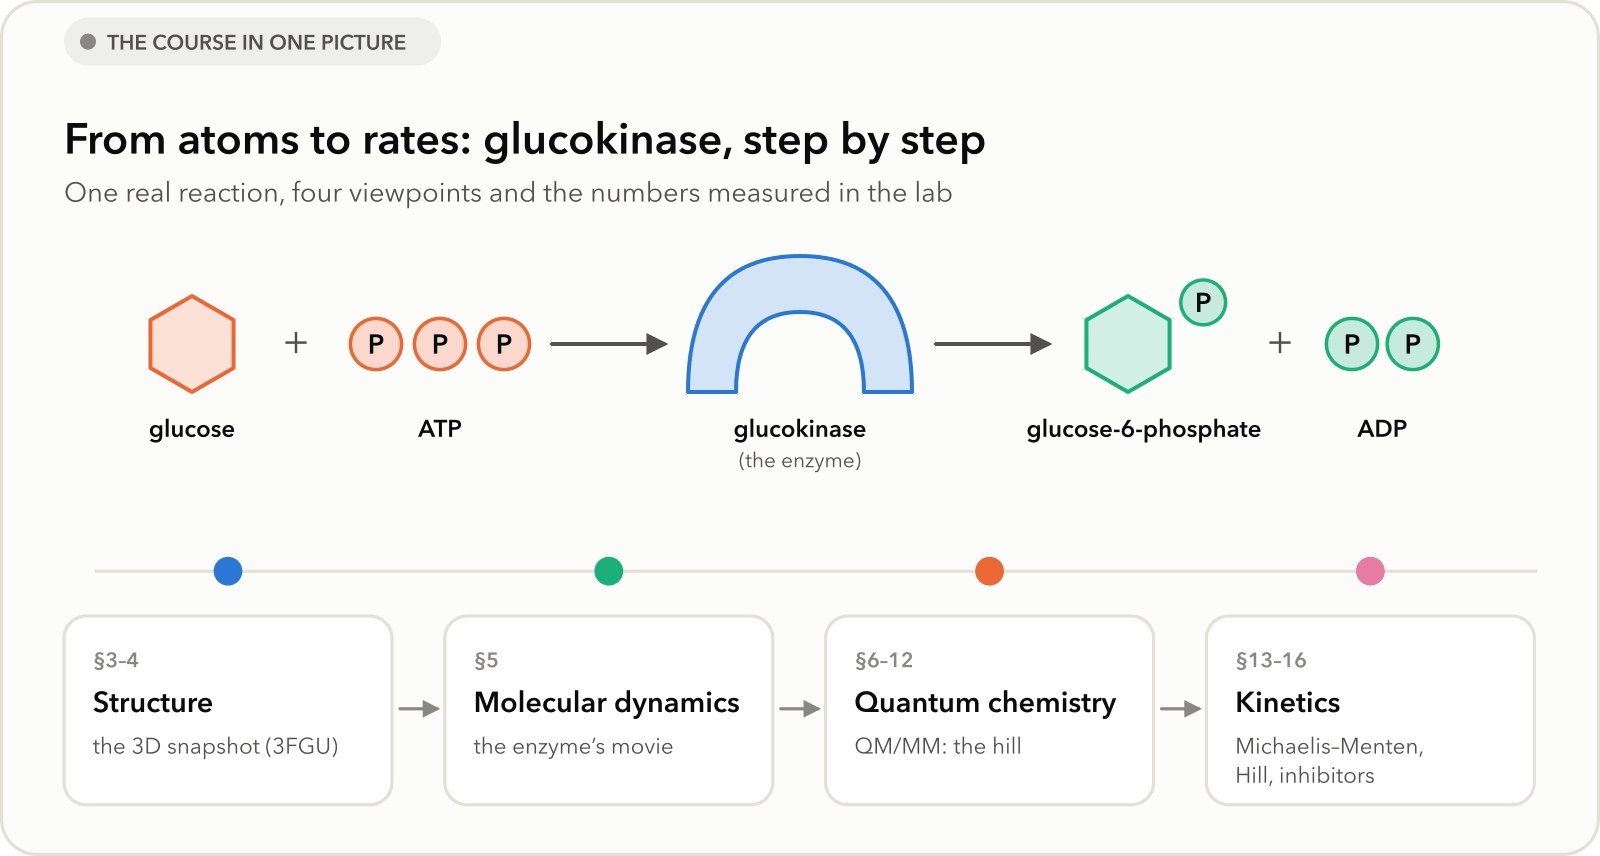

This notebook explains enzyme kinetics **from scratch**, for undergraduate students. You don't
need to know how to program: just run the cells in order (▶ or `Shift + Enter`) and read.
We use a real enzyme and everything that can be used with it: a crystal structure, molecular
dynamics and quantum-mechanics (QM/MM) simulations, and the numbers measured in the
laboratory for this enzyme, with their sources.

---

### 🧭 How each section is organized

Every section follows the same order, always marked with the same symbols:

| Symbol | Block | What you will find |
|:---:|---|---|
| 🎯 | **In this section** | the question we are going to answer |
| 💡 | **The analogy** | an everyday picture, with a drawing |
| 🧮 | **The equation in words** | why we need an equation and what it says, without symbols |
| 📐 | **The full equation** | the formal version, term by term, with the same colors as the drawing |
| 🎛️ | **What if…** | plots with sliders: move a term and see what changes |
| 🔬 | **The real data** | simulations and values measured in the laboratory |
| ✅ | **Takeaway** | the key idea in two lines |

In addition, the **⚠️ Watch out** boxes warn about a common trap and the **✍️ Think about it** boxes leave you a question.

---

### 🗺️ Contents

| # | Section | What you learn | Tool |
|---|---|---|---|
| | **🧱 Block 1 · The basics** | | |
| 1 | What is an enzyme, and why glucokinase? | basic vocabulary, experimental data | reading |
| 2 | What is the rate of a reaction? | v₀, units, how it is measured | simulation |
| | **🔭 Block 2 · Seeing the enzyme** | | |
| 3 | The 3D structure of the catalytic complex | active site | PDB 3FGU, 3D viewer |
| 4 | Preparing the enzyme for simulation | from the snapshot to the model | PDBFixer, Amber |
| 5 | The enzyme moves: molecular dynamics | reactive conformations | OpenMM |
| | **⚛️ Block 3 · The chemistry, with quantum mechanics** | | |
| 6 | Energy hills and reaction rate | Eyring equation | 🎛️ interactive |
| 7 | Looking at the reaction with quantum mechanics: QM/MM | QM and MM regions | MOPAC PM7 + Amber |
| 8 | Reactant, product and energy profile | reaction coordinate | scan |
| 9 | The transition state | NEB, dimer, imaginary frequency | ASE |
| 10 | From ΔE‡ to ΔG‡: improving the calculation | thermochemistry, averages, method | ASE, MOPAC |
| 11 | The reaction outside the enzyme | SADDLE (QST2), TS, FORCETS | native MOPAC |
| 12 | From the barrier to *k*<sub>cat</sub> | comparison with experiment | Eyring |
| | **📈 Block 4 · Laboratory kinetics** | | |
| 13 | Michaelis–Menten from the mechanism | K<sub>M</sub>, V<sub>max</sub>, k<sub>cat</sub>, k<sub>cat</sub>/K<sub>M</sub> | ODE, fits, 🎛️ |
| 14 | Cooperativity: glucokinase is a sensor | Hill equation, mutants | 🎛️ |
| 15 | Inhibitors and activators | types, K<sub>i</sub>, Dixon, IC₅₀ | 🎛️ |
| 16 | Temperature and pH | Arrhenius, Eyring, pKa | 🎛️ |
| | **🏁 Wrap-up** | | |
| 17 | Summary, glossary and exercises | map of the course | |

> 💡 **Tip.** In Colab, open the **Table of contents** panel (☰ icon on the left) to jump between
> sections.

---

### ⚙️ Before you start

**Two run modes.** In `rapido` mode ("fast", the default) the notebook reads results that were
already computed and draws everything in a few minutes. In `completo` mode ("full") it reruns
the simulations (hours on the Colab CPU). Change `MODO` in the next cell if you want to recompute.

> 🎛️ **How to use the interactive plots.** Cells marked with 🎛️ show sliders.
> Move them and watch how the curve changes; underneath, a sentence translates the numbers.
> If the sliders don't appear (for example when viewing the notebook on GitHub), run the cell.

In [ ]:
# @title ⚙️ Set up the environment (run this cell first)
# --- Environment setup (run this cell first) --------------------------------------------
import os, sys, subprocess, pathlib

MODO = "rapido"  # @param ["rapido", "completo"]
# "rapido" (fast): uses precomputed results (minutes) | "completo" (full): recomputes everything (hours)

REPO = "https://github.com/juvenalyosa/cinetica-enzimatica.git"
if "google.colab" in sys.modules:
    # In Colab: download the course or, if it is already there from a previous session, update it to the latest version
    destino = pathlib.Path("/content/cinetica-enzimatica")
    if destino.exists():
        subprocess.run(["git", "-C", str(destino), "fetch", "-q", "origin"], check=True)
        subprocess.run(["git", "-C", str(destino), "reset", "-q", "--hard", "origin/main"], check=True)
    else:
        subprocess.run(["git", "clone", "-q", REPO, str(destino)], check=True)
    os.chdir(destino)
elif not pathlib.Path("enzimas").exists() and pathlib.Path("../enzimas").exists():
    os.chdir("..")                                     # run from notebooks/ in Jupyter
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
# if the cell is run again, forget the version of the package loaded before
for nombre in [m for m in sys.modules if m == "enzimas" or m.startswith("enzimas.")]:
    del sys.modules[nombre]

from enzimas import colab_setup
entorno = colab_setup.instalar(MODO, idioma="en")

In [ ]:
# @title 📦 Load the course tools
# --- Imports and plot style -------------------------------------------------------------
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from enzimas import kinetics as cin, viz, datos, interactivo, visor3d, textos
textos.usar("en")                           # language of plots, cards and viewers
viz.apply_style()

def leer(nombre):
    """Reads a text file from data/precalculado (decompresses .gz if needed)."""
    return pathlib.Path(datos.ruta(nombre)).read_text()

ref = cin.glucokinase_reference()          # experimental values from the literature, with their sources
def valor(clave, defecto=None):
    v = ref.get(clave, {})
    return v.get("value", defecto) if isinstance(v, dict) else (v if v is not None else defecto)

print("Ready. Mode:", MODO)

## 1. What is an enzyme, and why glucokinase?

> 🎯 **In this section** you will learn what an enzyme does (and what it does **not** do), the
> vocabulary we will use throughout the course, which reaction glucokinase catalyzes and why it
> matters so much to your body.

---

### 💡 The analogy: a guide who knows the lowest pass

Imagine you want to cross a mountain range. Without a guide, you would search for a pass blindly
and it would take you weeks. A good guide knows the **lowest pass** and takes you through it in
hours. The mountain is still there, but the route is different. An **enzyme** is that guide: it
does not change the starting point or the destination of a chemical reaction, but it takes it along
a much easier route, and that is why it happens thousands or millions of times faster.

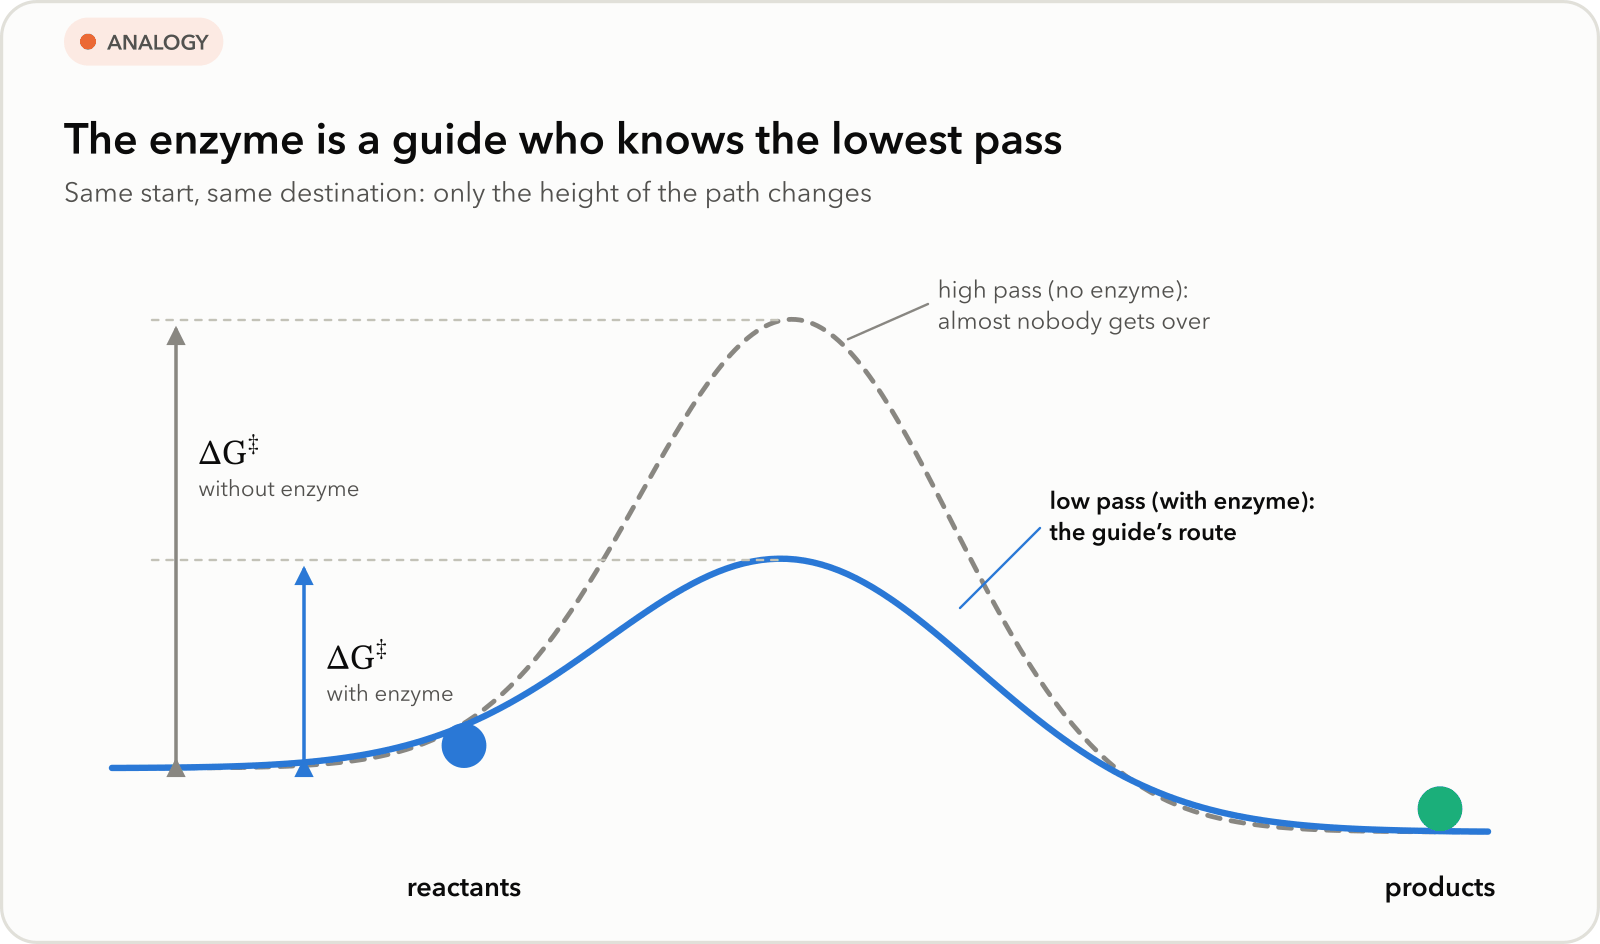

Notice what the drawing does **not** change: the two valleys are at the same height with and
without the enzyme. An enzyme speeds up the reaction, but it does not decide which way it goes or
how much product there will be at the end.

---

### 📖 Vocabulary we will use all the time

| Term | What it is | In the analogy | In glucokinase |
|---|---|---|---|
| **Substrate (S)** | the molecule the enzyme transforms | the traveler in the starting valley | glucose and ATP |
| **Product (P)** | what comes out | the traveler already in the destination valley | glucose‑6‑phosphate and ADP |
| **Active site** | the pocket of the enzyme where the substrates fit and the chemistry happens | the meeting point with the guide | the pocket with Asp205, Lys169 and Mg²⁺ |
| **ES complex** | the enzyme with the substrate already inside | traveler and guide, together | glucokinase·glucose·ATP |
| **Transition state (TS)** | the hardest moment of the reaction | the top of the pass | the phosphate halfway across |

Almost all of this notebook revolves around the **transition state**.

---

### 🔬 Our enzyme: glucokinase

**Glucokinase** takes a glucose and attaches to it a phosphate group that comes from ATP. The
product, glucose‑6‑phosphate, can no longer leave the cell: it is the first step to "trap" and
use glucose.

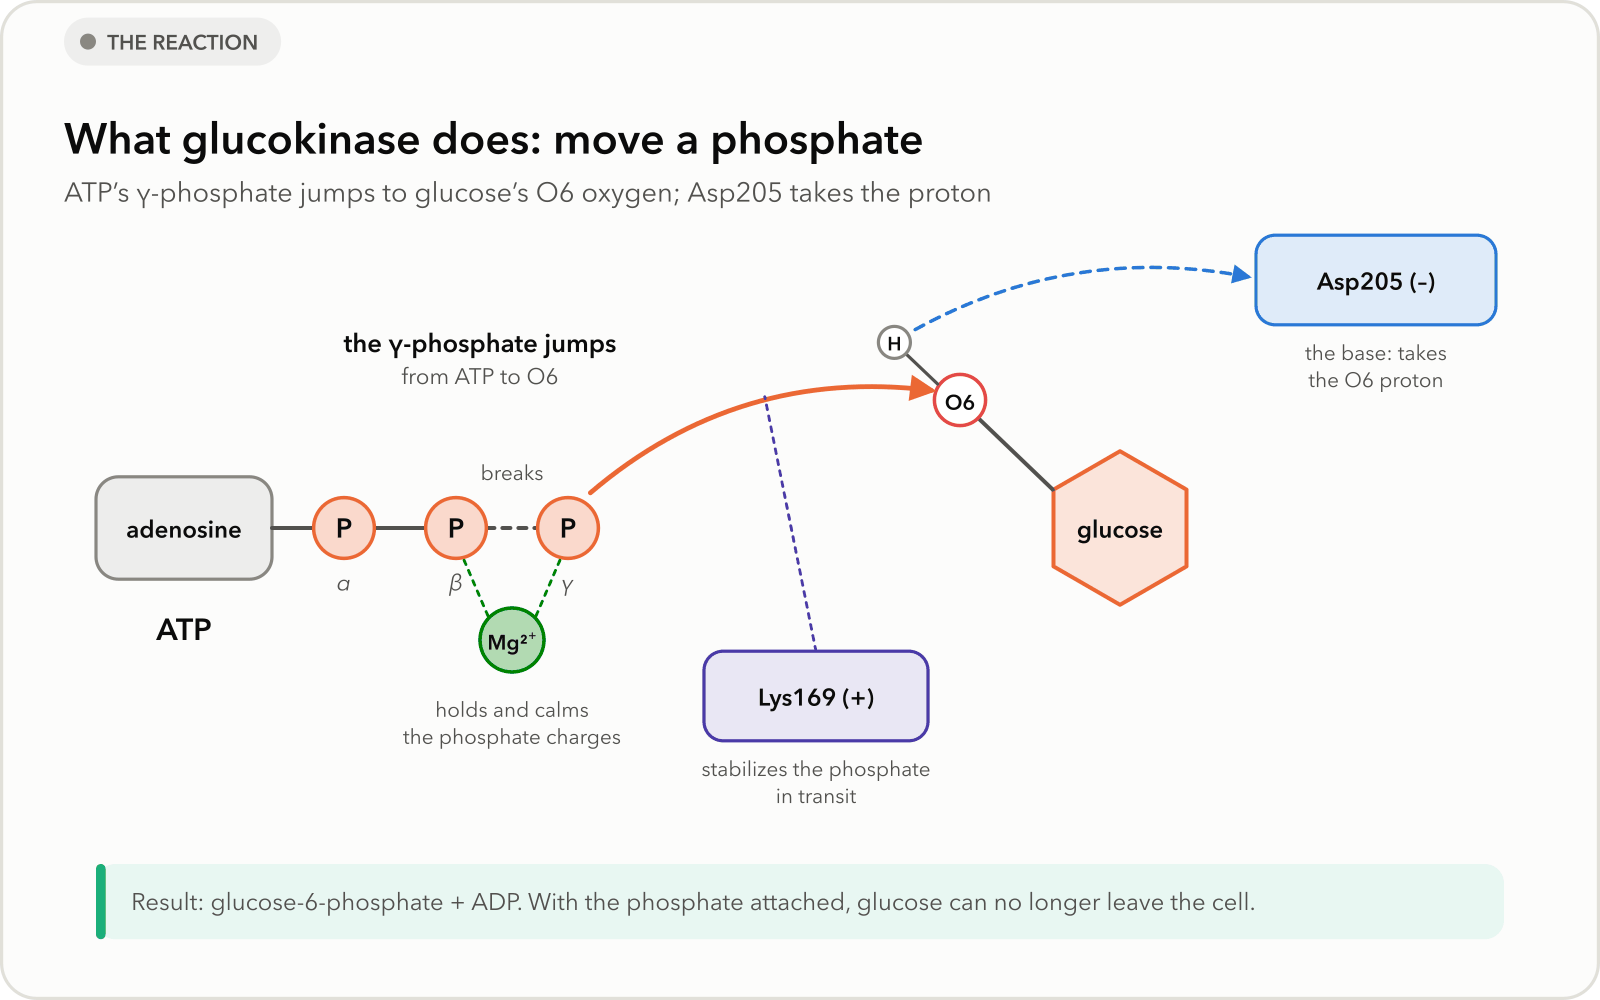

Glucokinase lives in the liver and in the β cells of the pancreas, where it works as a **glucose
sensor**: its activity decides how much insulin is released.

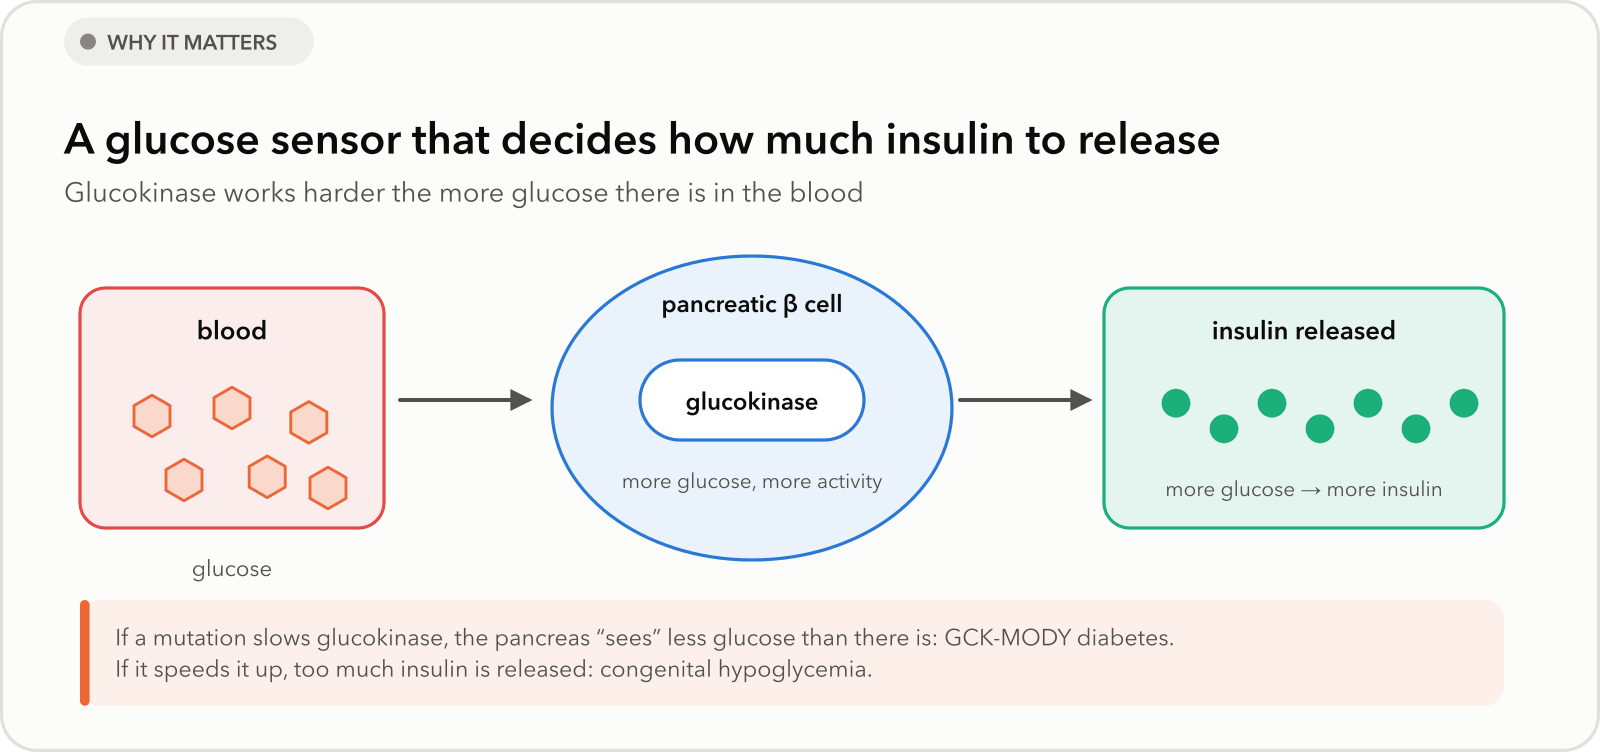

Mutations in its gene cause a hereditary form of diabetes (GCK‑MODY, formerly MODY2) and, if they
make it hyperactive, congenital hypoglycemia.

**Three things make it ideal for learning kinetics:**

1. Its reaction is a classic **phosphoryl transfer**, with Mg²⁺ and a catalytic base (Asp205).
2. Its rate curve is **not** the Michaelis–Menten hyperbola but a **sigmoid** (section 14).
3. It has well-studied inhibitors, a regulatory protein and pharmacological activators (section 15).

---

### 🔬 The real data: numbers measured in the laboratory

Everything that follows is compared with these values, taken from original papers (*source*
column). Keep them in mind: they are the "experimental result" that the theory must explain.

> ⚠️ **Watch out.** Different laboratories obtain k<sub>cat</sub> between 38 and 66 s⁻¹ for the same
> enzyme: in biochemistry, a number always comes with its conditions (temperature, pH, buffer).

In [ ]:
# @title 📋 Glucokinase numbers measured in the laboratory
filas = []
for k, v in ref.items():
    if isinstance(v, dict) and "value" in v:
        valor_txt = v["value"]
        if isinstance(valor_txt, (int, float)) and abs(valor_txt) >= 1e5:  # 1.1e12 → 1.1 × 10¹²
            m, e = f"{valor_txt:.1e}".split("e")
            valor_txt = f"{m} × 10" + str(int(e)).translate(str.maketrans("0123456789-", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻"))
        filas.append((v.get("label", k), valor_txt, v.get("unit", ""), v.get("conditions", ""), v.get("source", "")))
tabla = pd.DataFrame(filas, columns=["parameter", "value", "unit", "conditions", "source"])
viz.mostrar(
    viz.tabla(tabla, titulo="Human glucokinase in the laboratory",
              nota="Every number comes with its conditions and its source: different laboratories measure somewhat different values."),
    viz.mensaje(ref.get("notes", ""), tipo="dato", titulo="Note on the data") if ref.get("notes") else None,
)

> ✅ **Takeaway.** An enzyme is a guide: it lowers the hill between reactants and products without
> changing either the starting point or the destination. Glucokinase moves a phosphate from ATP to
> glucose, and as a glucose sensor it decides how much insulin the pancreas releases.

## 2. What is the rate of a reaction?

> 🎯 **In this section** you will learn what "rate" means for a chemical reaction, why
> biochemists measure the **initial rate v₀** and how it is measured in the laboratory for
> glucokinase.

---

### 💡 The analogy: counting coins falling into a jar

The rate of a reaction is **how much product appears per second** (or how much substrate
disappears). It is like counting the coins that fall into a jar: if there are 5 after 5 s and
10 after 10 s, they fall at one per second. If, in a tube with enzyme, glucose‑6‑phosphate goes
from 0 to 10 µM in 10 s, the rate is 1 µM/s.

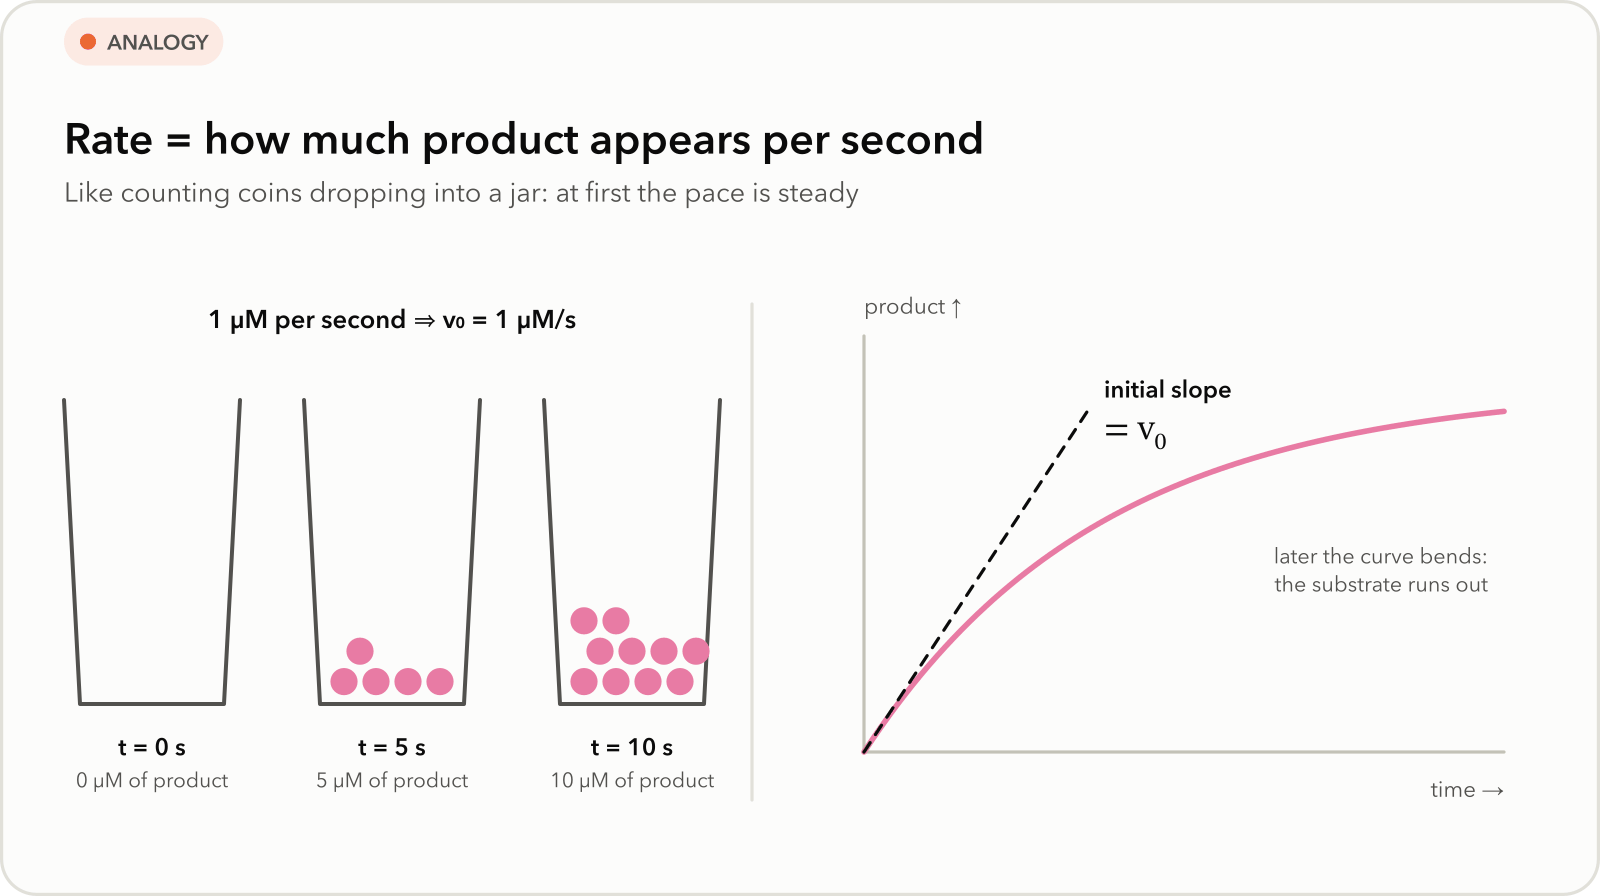

---

### 🧮 The equation in words

**Why do we want an equation?** So that "fast" and "slow" become a number with units, which we
can compare between experiments and with theory.

$$\text{rate} \;=\; \frac{\text{how much new product appeared}}{\text{how much time went by}}$$

### 📐 The full equation, term by term

$$v_0 \;=\; \left(\frac{{\color{#e87ba4}{\Delta[\mathrm{P}]}}}{{\color{#52514e}{\Delta t}}}\right)_{t\,\to\,0}$$

| Term | What it is | In the analogy | Units |
|---|---|---|---|
| $v_0$ | **initial** rate | the pace of coins at the start | µM/s |
| $\Delta[\mathrm{P}]$ | increase in product concentration | new coins in the jar | µM |
| $\Delta t$ | elapsed time | seconds on the stopwatch | s |
| $t \to 0$ | "measured at the start" | count before the coins run out | — |

**Why "initial rate"?** At the start of the experiment the substrate has barely been used up and
the product has barely accumulated, so the rate is constant and reflects only the enzyme and the
substrate concentration we added. Later the curve bends (the substrate runs out). That is why
biochemists measure the **initial rate, v₀**: the slope of the product curve at the beginning.

> ⚠️ **Watch out.** If you measure the slope too late, when the curve has already bent, you will
> get a rate lower than the real one, and every parameter you compute afterwards will be wrong.

---

### 🔬 How it is measured for glucokinase: the coupled assay

Glucose‑6‑phosphate is not seen directly: a second enzyme is coupled (glucose‑6‑phosphate
dehydrogenase, G6PDH) that converts it and, in doing so, produces NADPH, which absorbs light at
340 nm. The spectrophotometer records the absorbance over time, and the initial slope is v₀ (the
"G6PDH-coupled" assay of almost every paper in the previous table).

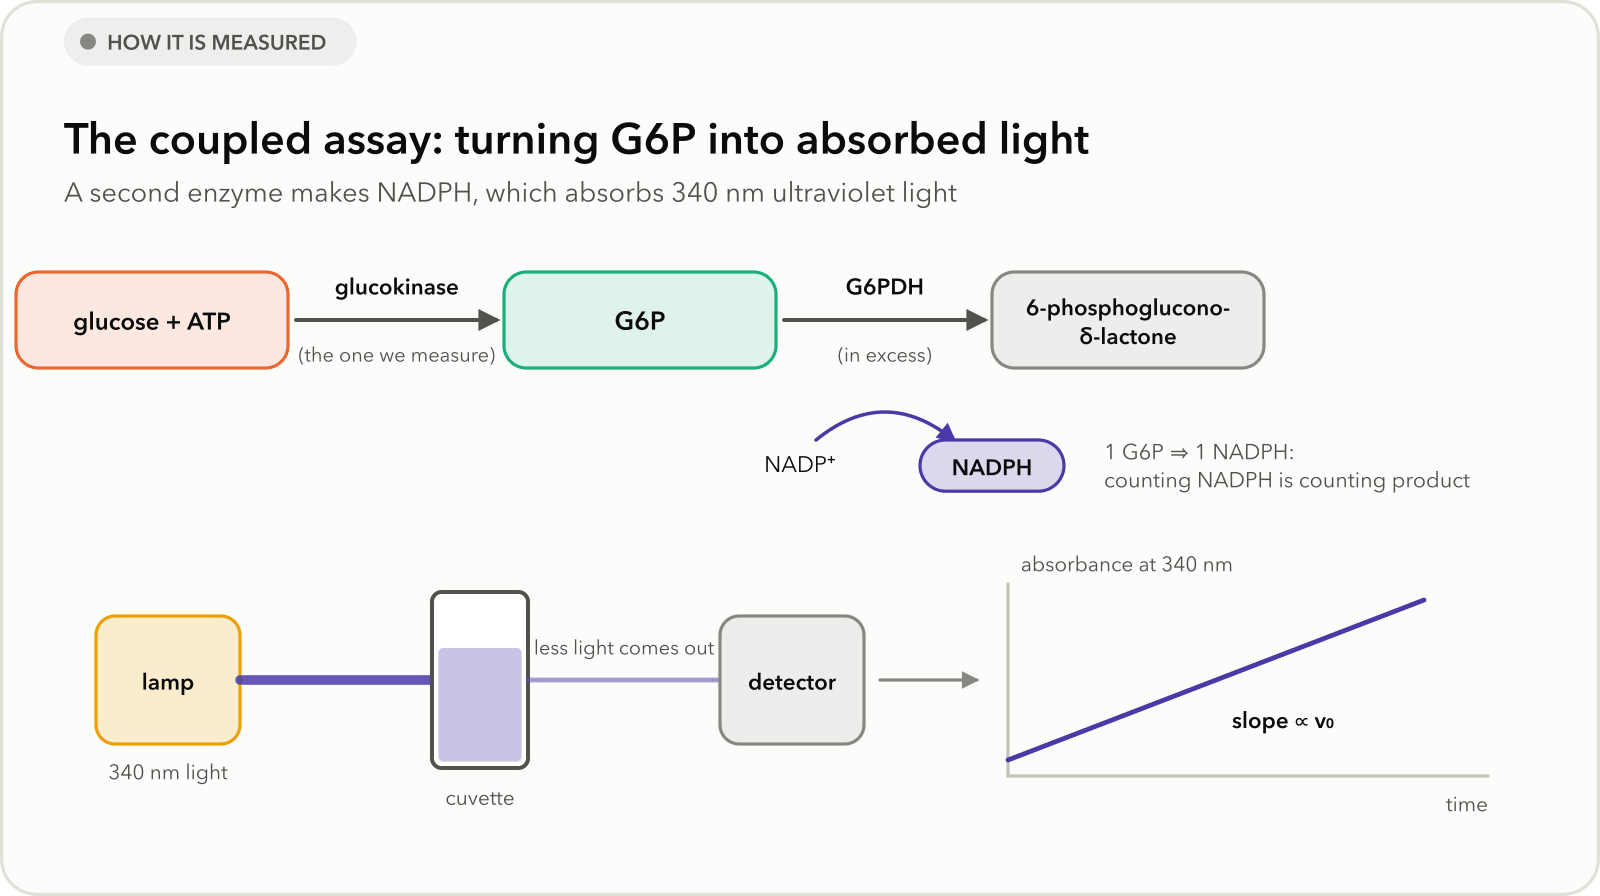

---

### 🎛️ What if… I change the amount of substrate

Let's simulate that curve for three initial substrate concentrations, [S]₀, and measure the
initial slope of each one:

In [ ]:
# @title 📈 Progress curves and initial rate
# Simulated progress curve: product versus time for three substrate concentrations
E0, k1, k_1, k2 = 0.05, 1.0, 50.0, 60.0          # µM, µM⁻¹s⁻¹, s⁻¹, s⁻¹
curvas = []
for S0 in (50, 200, 1000):
    sim = cin.simulate_mechanism(e0=E0, s0=S0, k1=k1, k_minus1=k_1, k2=k2, t_end=150.0, n_points=4000)
    ventana = (sim["t"] > 0.02) & (sim["t"] < 1.0)
    pend = cin.linear_fit(sim["t"][ventana], sim["P"][ventana])["slope"]
    curvas.append((sim["t"], sim["P"], pend, f"[S]₀ = {S0} µM"))
fig = viz.plot_progress_curves(curvas, title="The initial slope is the rate v₀",
                               subtitle="With 50, 200 and 1000 µM substrate. Dashed: the tangents at the start. The curve bends when the substrate runs out")
v = [c[2] for c in curvas]
t_tab = np.array([0, 0.5, 1, 2, 5, 10, 20, 40, 80, 150])              # time points for the data table (s)
col = {c[3]: f"[P] with {c[3].split('= ')[1]}" for c in curvas}
viz.mostrar(fig, viz.tarjetas(
    [("v₀ with 50 µM", f"{v[0]:.2f}", "µM/s", None, "azul"),
     ("v₀ with 200 µM", f"{v[1]:.2f}", "µM/s", f"4 × more substrate → × {v[1] / v[0]:.1f} in v₀", "azul"),
     ("v₀ with 1000 µM", f"{v[2]:.2f}", "µM/s", f"20 × more substrate → × {v[2] / v[0]:.1f} in v₀", "azul")],
    nota="With more substrate the initial slope is larger, but not proportionally. "
         "That \"not proportionally\" is what enzyme kinetics is all about."),
    viz.datos(pd.DataFrame({"time": t_tab, **{col[c[3]]: np.interp(t_tab, c[0], c[1]) for c in curvas}}),
              "progress curves",
              "Each row is an instant of the simulated experiment; each column, one of the three curves. At first "
              "the product grows at a constant pace (the slope is v₀); later it slows down because the substrate is used up.",
              x="time", y=list(col.values()),
              unidades={"time": "s", **{c: "µM" for c in col.values()}},
              formatos={"time": "{:g}", **{c: "{:.1f}" for c in col.values()}},
              resaltar={2: ("v₀", "azul")},
              nota=f"Row v₀: in the first second, [P] ÷ time ≈ v₀ ({v[0]:.2f}, {v[1]:.2f} and {v[2]:.2f} µM/s)."))

> ✍️ **Think about it.** If you double [S]₀ from 200 to 400 µM, does v₀ double? Write down your
> prediction; in section 13 we will see why the answer is "not quite".

> ✅ **Takeaway.** The rate is the slope of the product-versus-time curve, and it is measured
> **at the start** (v₀). For glucokinase it is measured with a coupled assay: every G6P formed
> produces one NADPH that absorbs light at 340 nm.

## 3. The 3D structure of the catalytic complex

> 🎯 **In this section** you will see where every atom of glucokinase is just before the
> reaction, what each piece of the active site does and why the reactants are already "aiming at
> each other".

---

### 💡 The analogy: a clamshell that closes over glucose

To simulate an enzyme we need to know where every atom is. Crystallographers give us that: the
structure **3FGU** in the Protein Data Bank is a "snapshot" of human glucokinase with
**glucose**, an ATP analog and the **Mg²⁺** ion, all inside the active site, just before the
reaction.

Glucokinase has two parts, the **large domain** and the **small domain**, joined by a hinge.
Without glucose the enzyme is **open**, like a half-open clamshell. When glucose enters, the
small domain closes over it: the reactants are enclosed, with no water around them and lined up to
react.

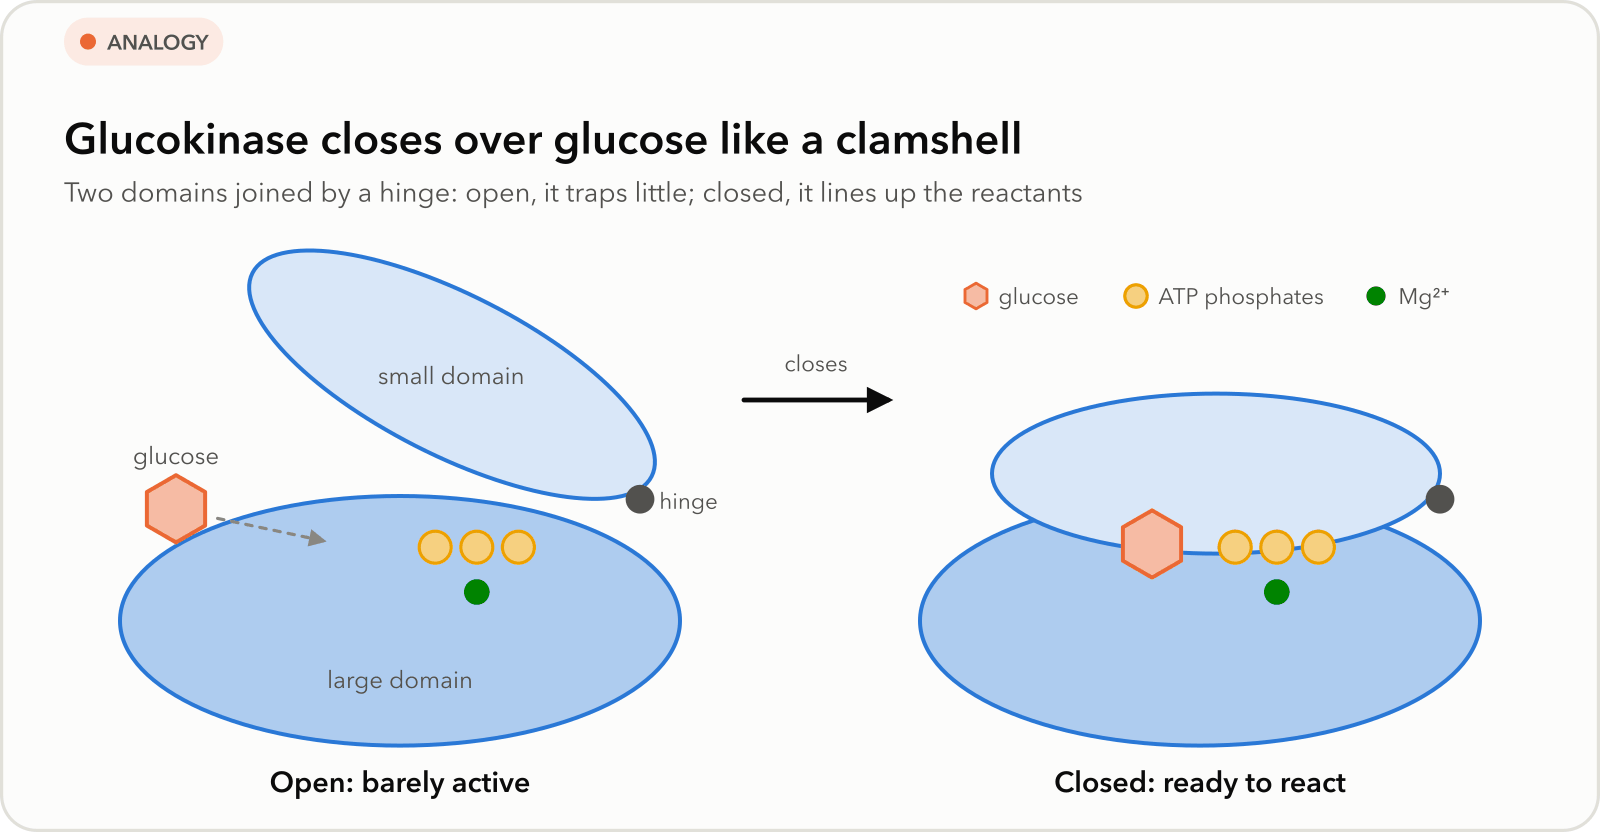

---

### 🔬 The real data: who is who in the active site

In the closed form, each piece has a role:

| Piece | Where it is | What it does | In the analogy |
|---|---|---|---|
| **O6 of glucose** | ~2.7 Å from the phosphorus Pγ of ATP | will receive the phosphate | the hand that catches the ball |
| **Pγ of ATP** | at the end of the triphosphate | is the phosphorus that jumps | the ball |
| **Asp205** | 2.5 Å from the O6–H hydroxyl | **catalytic base**: it will take the proton | the one who frees the hand to catch |
| **Lys169** and **Mg²⁺** | next to the phosphates | neutralize their negative charges | shock absorbers |

A P–O bond is 1.6 Å long: at 2.7 Å, O6 and Pγ are **very close, but not yet bonded**.

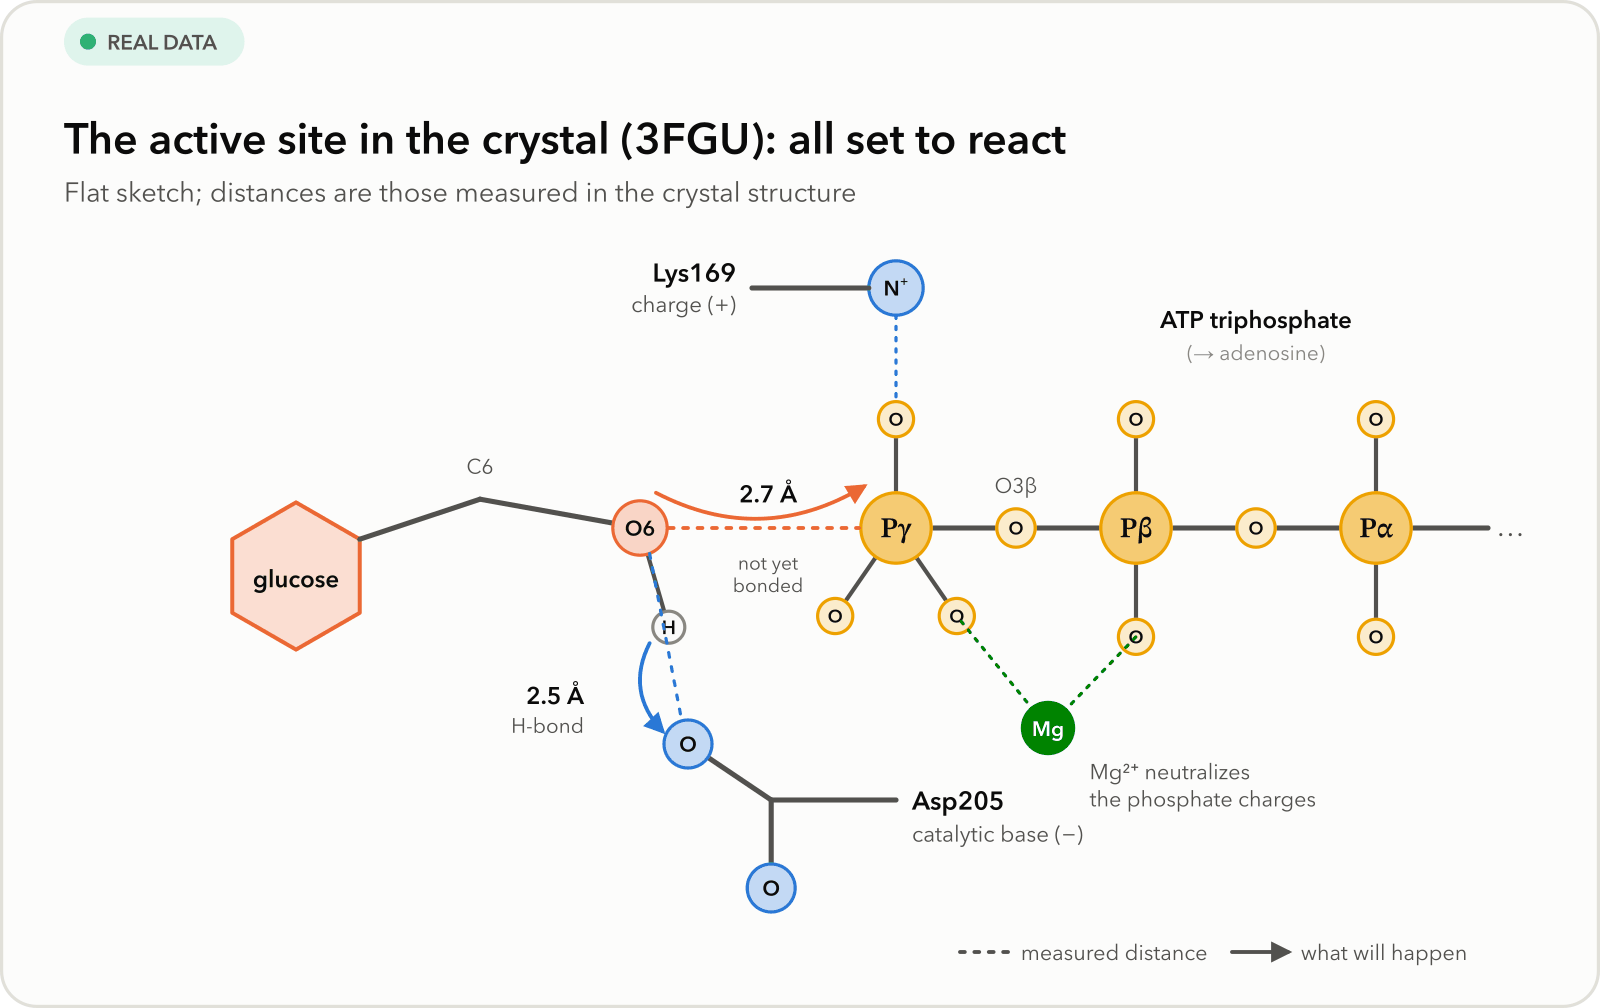

Explore the real enzyme, atom by atom: **drag** to rotate it, use the **scroll wheel** to zoom in
and the buttons to see the **active site** or the **surface**. The **dashed lines** mark the two
distances that tell us whether everything is ready to react (Pγ ··· O6 and O6 ··· Asp205); their
values are computed in the next cell:

In [ ]:
# @title 🧬 Glucokinase in 3D (rotate it with the mouse)
pdb_cristal = pathlib.Path("data/raw/3FGU.pdb").read_text()
visor3d.complejo_cristal(pdb_cristal)

And let's check the two key distances directly in the crystal file:

In [ ]:
# @title 📏 Key distances in the crystal
# Key distances in the crystal (Å): is everything ready to react?
def coords_pdb(texto, resn, name, resi=None):
    for l in texto.splitlines():
        if l.startswith(("ATOM", "HETATM")) and l[17:20].strip() == resn and l[12:16].strip() == name and l[16] in " A":
            if resi is None or int(l[22:26]) == resi:
                return np.array([float(l[30:38]), float(l[38:46]), float(l[46:54])])

PG, O6, OD1 = coords_pdb(pdb_cristal, "ANP", "PG"), coords_pdb(pdb_cristal, "BGC", "O6"), coords_pdb(pdb_cristal, "ASP", "OD1", 205)
viz.mostrar(
    viz.tarjetas([("Pγ ··· O6 (glucose)", f"{np.linalg.norm(PG - O6):.2f}", "Å",
                   "a P–O bond is 1.6 Å long: they are very close, but not yet bonded", "agua"),
                  ("O6 ··· OD1 (Asp205)", f"{np.linalg.norm(O6 - OD1):.2f}", "Å",
                   "short hydrogen bond: Asp205 is ready to take the proton", "azul")],
                 titulo="The two key distances, measured in the crystal file"),
    viz.mensaje("These are the same dashed lines as in the 3D viewer above (aqua and blue). Press \"Active site\" "
                "to zoom in and rotate the molecule: you will see that the O6 of glucose points straight at the γ phosphorus of ATP.",
                "idea"))

> ✍️ **Think about it.** The crystal uses AMP‑PNP, in which the oxygen between the β and γ
> phosphorus atoms was replaced by a nitrogen (N3B). That change prevents the reaction and makes it
> possible to capture the complex. To simulate the real reaction, we will put the oxygen back:
> true ATP.

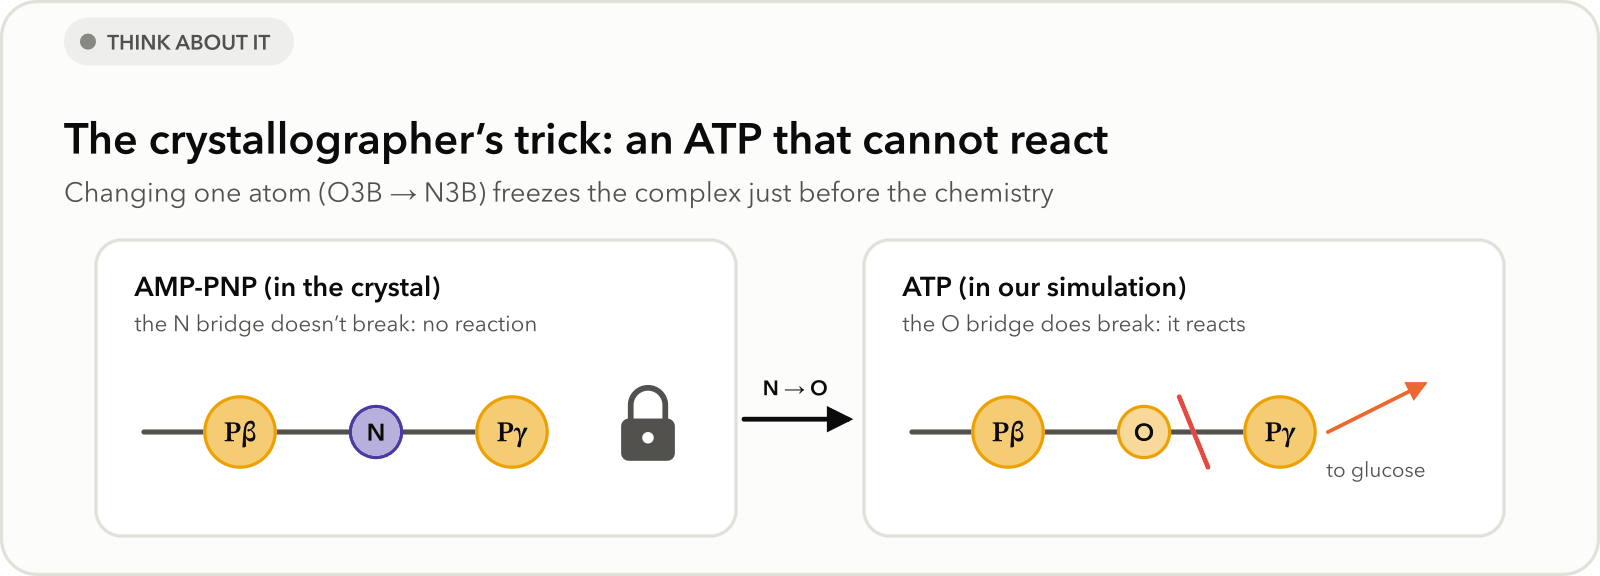

> ✅ **Takeaway.** Glucokinase closes like a clamshell over glucose and leaves O6 2.7 Å from the
> phosphorus it must attack, with Asp205 ready to take its proton and Mg²⁺ and Lys169 holding the
> phosphate charges. The snapshot already shows an enzyme **primed to react**.

## 4. Preparing the enzyme for simulation

> 🎯 **In this section** you will see why a crystal structure cannot be simulated as it is and
> which four fixes turn it into a model ready for molecular dynamics.

---

### 💡 The analogy: from the photo to the scale model

A crystallographic structure is like a photo of a building: it tells you what it looks like, but
to study how it sways in the wind you need to build a **complete scale model**. The photo is
missing things:

* the **hydrogens** (X-rays don't see them),
* **pieces of the chain** that were disordered in the crystal and can't be seen,
* the **rules** for how each atom moves (springs and charges),
* and the **water** with ions that surrounds it in the cell.

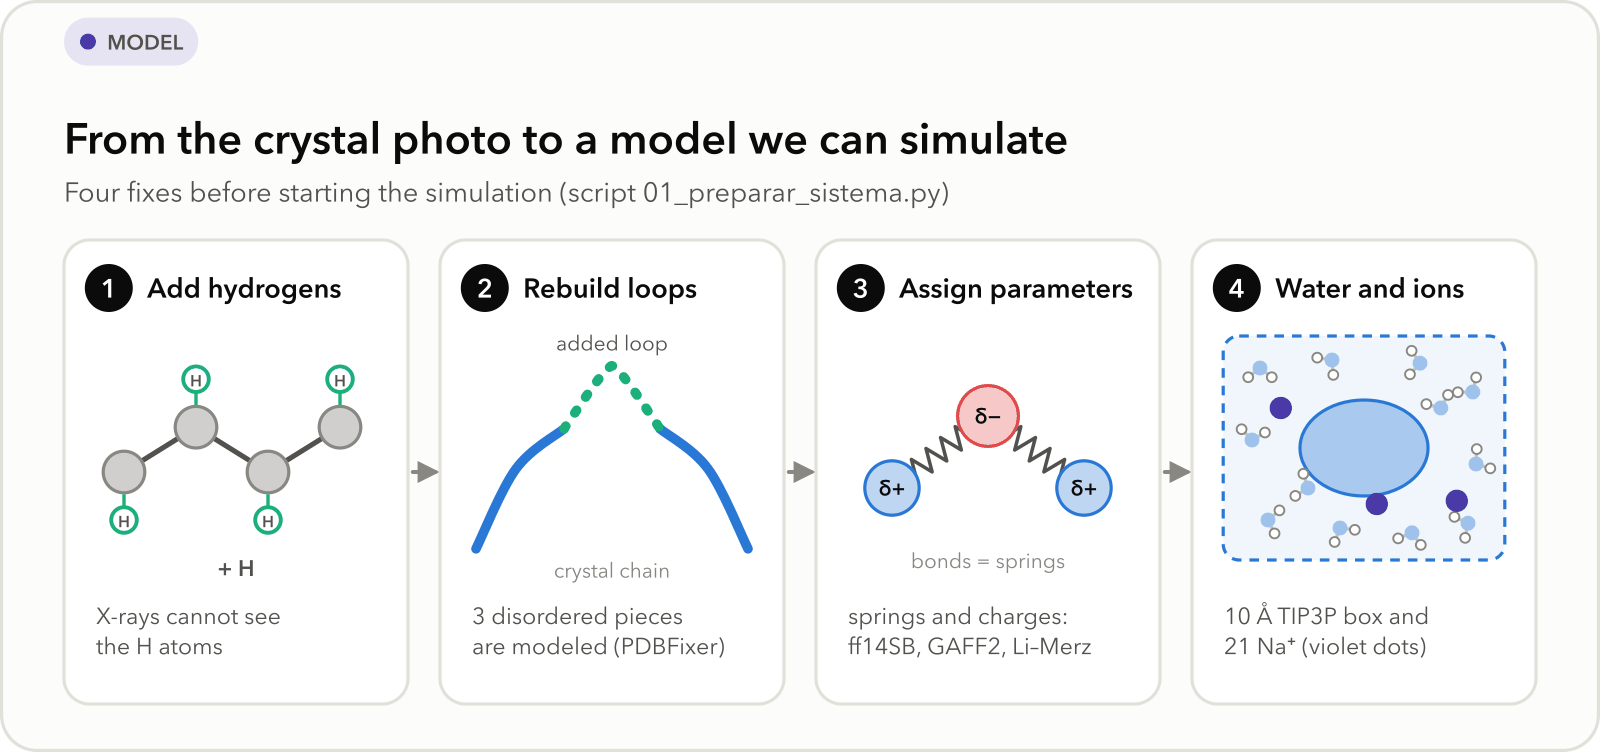

---

### 🔬 The real data: what the script `scripts/01_preparar_sistema.py` did

| Step | What was done | Tool |
|---|---|---|
| 1. Complete the chain | Chain A of 3FGU, residues 5–458; three missing internal loops modeled | PDBFixer |
| 2. Restore ATP | AMP‑PNP → ATP (N3B → O3B) | PDB editing |
| 3. Assign parameters | glucose and ATP with GAFF2 and AM1‑BCC charges; protein with Amber ff14SB; Mg²⁺ and K⁺ with Li–Merz parameters | antechamber, tleap |
| 4. Water and ions | crystallographic waters kept; 10 Å TIP3P water box and 21 Na⁺ to neutralize | tleap |

> ⚠️ **Watch out.** In `completo` (full) mode this preparation requires AmberTools (antechamber,
> tleap), which is not available in Colab; that is why the prepared files travel with the
> repository.

Let's look at the result:

In [ ]:
# @title 🧰 What the prepared system contains
prep = datos.json_("sistema/preparacion.json")
solv = prep["sistema_solvatado"]
cuentas = solv["residue_counts"]
viz.mostrar(
    viz.tarjetas([
        ("atoms in the box", f"{solv['n_atoms']:,}".replace(",", " "), "", "protein, ligands, ions and water", "azul"),
        ("water molecules", f"{cuentas.get('HOH', cuentas.get('WAT', 0)):,}".replace(",", " "), "", "10 Å TIP3P box around it", "agua"),
        ("total charge", f"{solv['total_charge']:+.3f}", "e", f"neutralized with {cuentas.get('Na+', 0)} Na⁺", "violeta"),
        ("modeled loops", str(len(prep["bucles_modelados"])), "", "pieces the crystal could not see", "naranja"),
    ], titulo="The system, ready to simulate",
       nota=f"Source: {prep['fuente']} · Force field: {prep['campo_de_fuerza']}"),
    viz.tabla(pd.DataFrame(
        [("ligands: charges", ", ".join(f"{k} {v:+.2f}" for k, v in solv["ligand_charges"].items())),
         ("residues", ", ".join(f"{k} × {v}" for k, v in cuentas.items() if k in ("HOH", "WAT", "Na+", "GLC", "ATP", "MG", "K+"))),
         ("loops (index, residues)", "; ".join(str(b) for b in prep["bucles_modelados"]))],
        columns=["what", "detail"]), titulo="In detail"),
)

> ✅ **Takeaway.** A crystal structure is the starting point, not the model: you have to add
> hydrogens, complete the missing pieces, give each atom its springs and charges and immerse it in
> water with ions. Only then can it be simulated.

## 5. The enzyme moves: molecular dynamics

> 🎯 **In this section** you will see how a protein is "filmed" with Newton's laws and what that
> movie is good for: measuring how much time the reactants spend well positioned to react.

---

### 💡 The analogy: the photo and the movie

The crystal structure is a **photo**: a single pose. But a protein at 37 °C is never still: it
bends, breathes and vibrates. **Molecular dynamics (MD)** is the **movie**: a sequence of frames
2 femtoseconds apart (0.000000000000002 s). One nanosecond of movie is 500 000 frames.

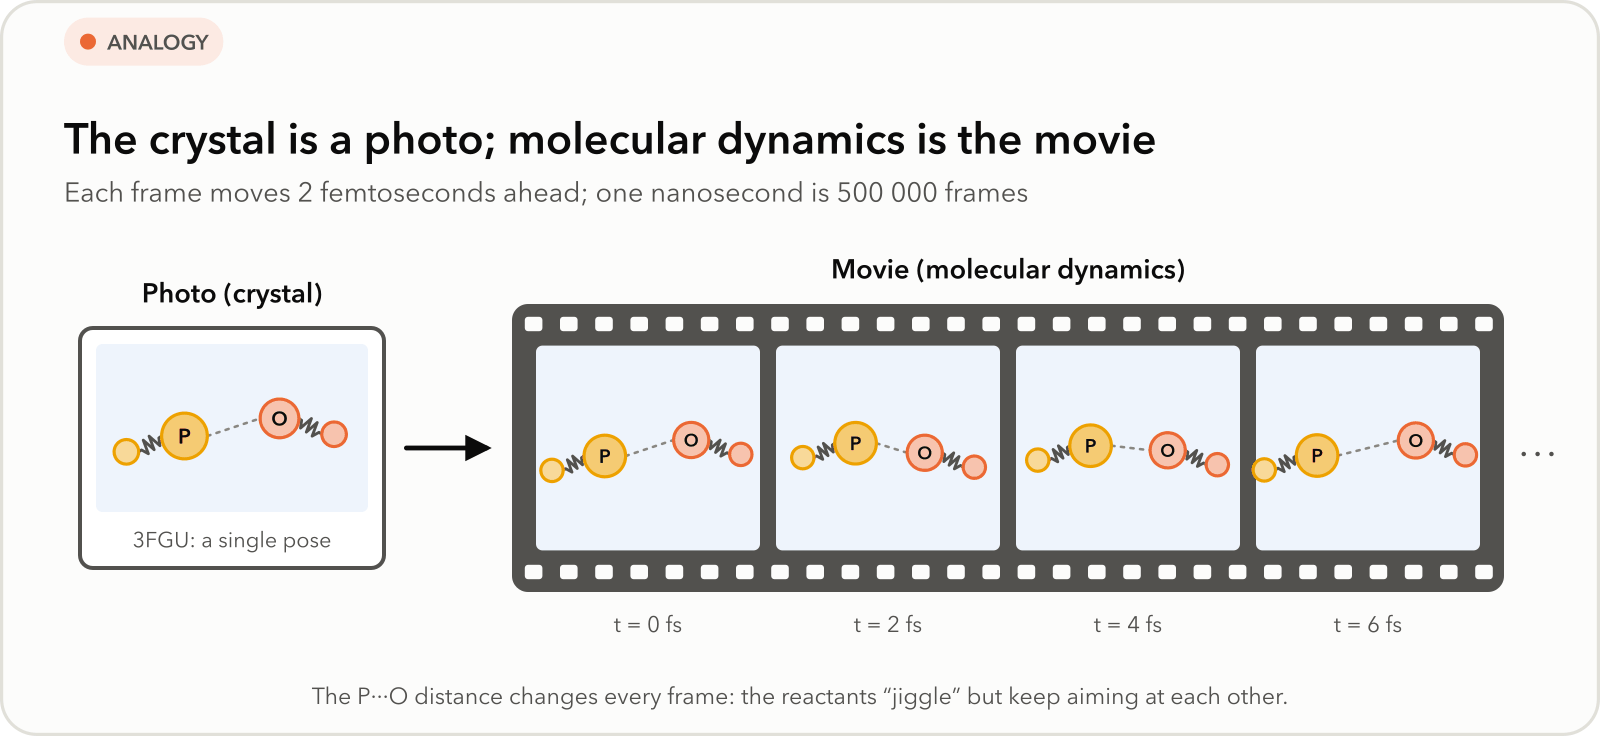

---

### 🧮 The equation in words

**Why do we want an equation?** To know where each atom will be in the next frame. The recipe is
that of a pool table: if you know how hard a ball is pushed, you know how it accelerates and
where it will be an instant later.

Each atom is a **ball** with mass, joined to its neighbors by **springs** (the bonds), and it also
feels the **charges** and the **collisions** of all the others. With that, each frame is one turn
of the same cycle:

$$\text{forces} \;\rightarrow\; \text{acceleration} \;\rightarrow\; \text{new position} \;\rightarrow\; \text{forces} \;\rightarrow\; \cdots$$

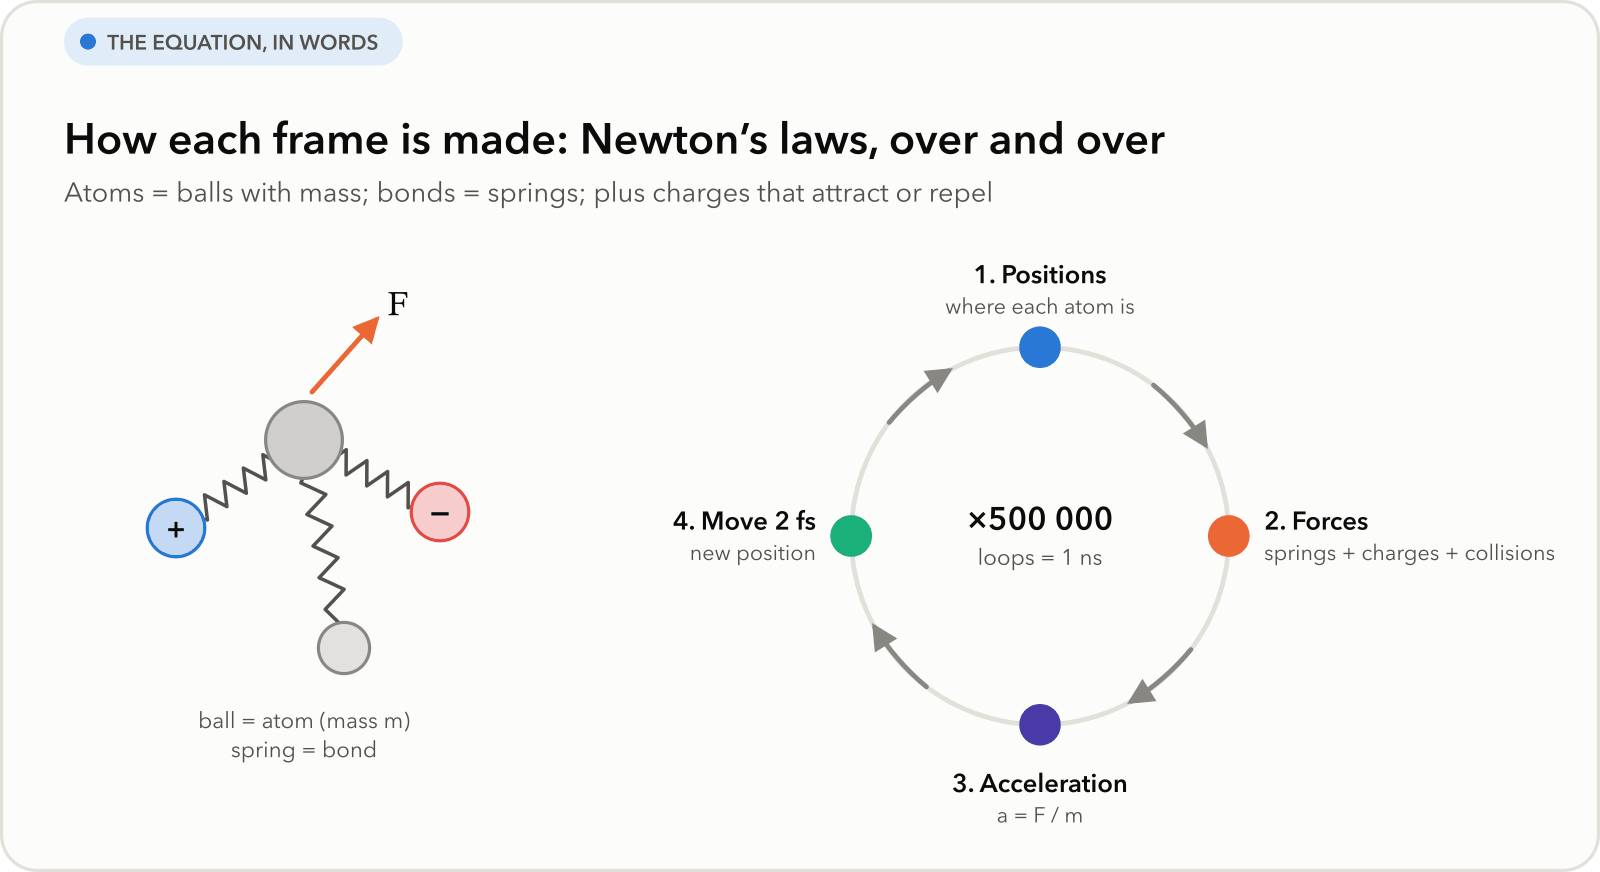

---

### 📐 The full equation, term by term

Newton's second law for each atom *i*, and one time step:

$${\color{#eb6834}{\mathbf{F}_i}} = m_i\,{\color{#4a3aa7}{\mathbf{a}_i}}
\qquad\Rightarrow\qquad
\mathbf{v}_i \leftarrow \mathbf{v}_i + {\color{#4a3aa7}{\mathbf{a}_i}}\,{\color{#1baf7a}{\Delta t}},
\qquad
{\color{#2a78d6}{\mathbf{r}_i}} \leftarrow {\color{#2a78d6}{\mathbf{r}_i}} + \mathbf{v}_i\,{\color{#1baf7a}{\Delta t}}$$

| Term | What it is | In the analogy | Value here |
|---|---|---|---|
| ${\color{#2a78d6}{\mathbf{r}_i}}$ | position of atom *i* | where the ball is | ~57 000 atoms |
| ${\color{#eb6834}{\mathbf{F}_i}}$ | total force on the atom | pulls from the springs + attraction/repulsion of the charges + collisions | Amber ff14SB force field |
| $m_i$ | mass of the atom | how heavy the ball is | H = 1, C = 12, O = 16 g/mol |
| ${\color{#4a3aa7}{\mathbf{a}_i}}$ | acceleration | how much its velocity changes | $\mathbf{F}_i/m_i$ |
| $\mathbf{v}_i$ | velocity | where it is heading and how fast | ~ the one set by the temperature (300 K) |
| ${\color{#1baf7a}{\Delta t}}$ | time step | time between frames | 2 fs |

The forces come from an **energy** $U$ that adds up springs, charges and collisions: each atom is
pushed "downhill" on that energy, $\mathbf{F}_i = -\partial U/\partial \mathbf{r}_i$. The program
(OpenMM) uses a Langevin integrator, a more careful version of this same cycle that also keeps
the temperature at 300 K.

---

### 🎛️ What if…

| If… | then… | because… |
|---|---|---|
| **Δt were much larger** | the simulation "blows up" | the atoms would jump too far between frames and the springs would stretch out of control; 2 fs is possible because the lengths of bonds to H are held fixed |
| **we simulate for longer** | we see slower motions (domains opening and closing) | 1 ns is 500 000 turns of the cycle; large changes can take much longer |
| **we wanted to break a bond** | classical MD cannot do it | its springs know nothing about electrons: that requires QM/MM (section 7) |

---

### 🔬 The real data

**What was done.** With OpenMM and Amber: minimization, heating up to 300 K, equilibration at
1 bar and 1 ns of production (script `02_dinamica_molecular.py`). There is no chemistry here (bonds
don't break): MD tells us **how much time the active site spends in a reactive geometry**, with
the Pγ of ATP close to the O6 of glucose. Those geometries are called **near-attack
conformations** (NAC).

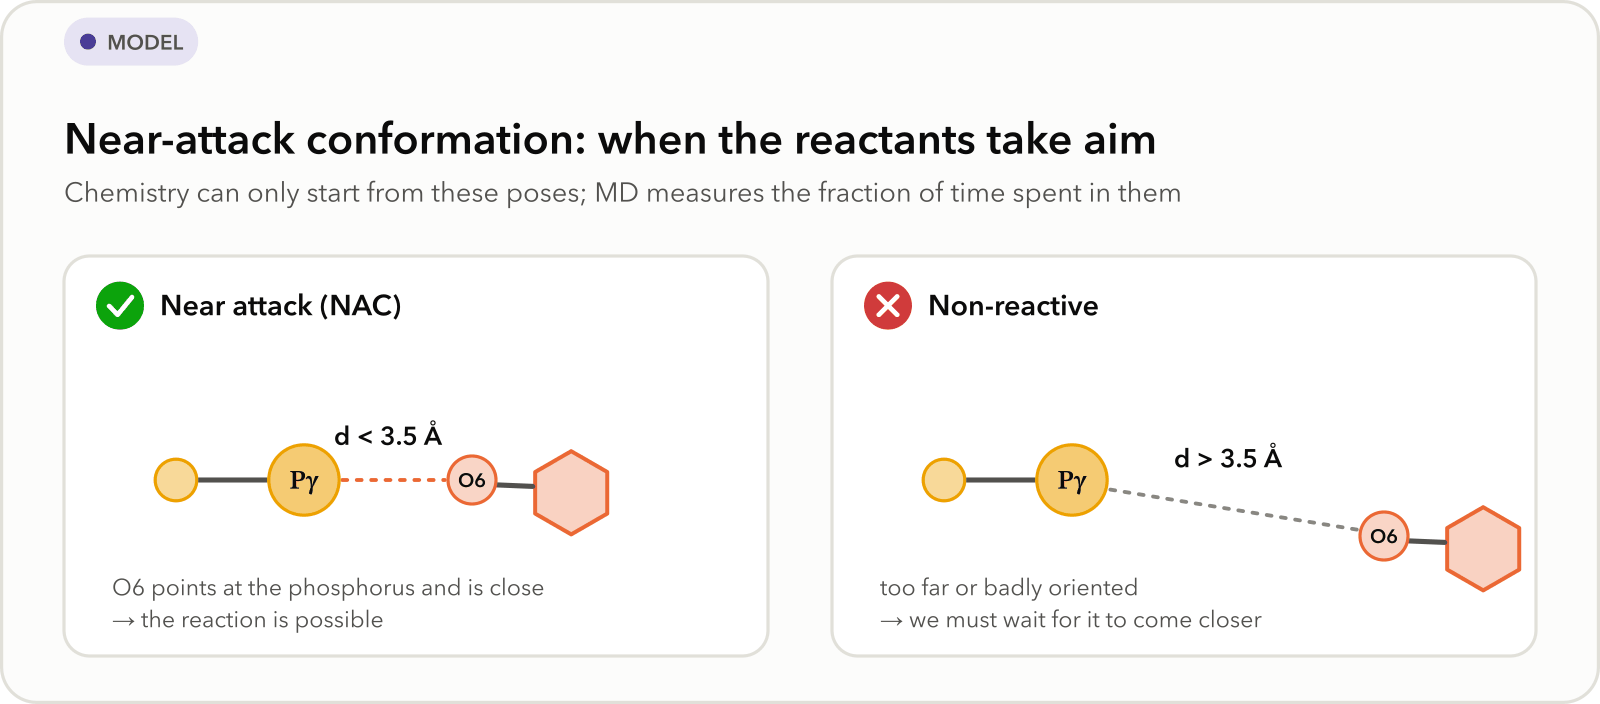

**How to read the plot.** Each point is a frame of the movie (one every 10 ps) and the thick line
is the moving average, which removes the jitter and shows the trend.

* **Top, large:** the distance between the γ phosphorus of ATP and the O6 of glucose. The green
  band is the **near-attack zone** (d < 3.5 Å): while the curve is inside it, the reactants "aim at
  each other". On the right, how many frames fall at each distance and the percentage of time
  inside the zone. The black line is the crystal value.
* **Bottom left:** the RMSD, how far the protein has drifted from the initial structure. A flat
  value of ~1 Å is small: the enzyme is stable and does not fall apart.
* **Bottom right:** the distance from O6 to the catalytic base, Asp205. The green band marks a
  hydrogen bond (< 3.2 Å). Notice that in the classical simulation Asp205 stays **outside** the
  band: we will come back to this in section 10.

In [ ]:
# @title 🎬 Molecular dynamics: how the enzyme moves
if MODO == "completo":
    subprocess.run([sys.executable, "scripts/02_dinamica_molecular.py"], check=True)

md_df = datos.csv("md/analisis.csv")
md_info = datos.json_("md/md.json")
fig = viz.plot_md_summary(md_df, crystal_value=2.68, crystal_hbond=2.5)
viz.mostrar(fig, viz.tarjetas(
    [("Movie", f"{md_info['produccion_ns']:g}", "ns", f"{len(md_df)} frames, one every {md_info['cuadro_ps']} ps", "gris"),
     ("Simulated atoms", f"{md_info['n_atomos']:,}".replace(",", " "), "", "protein, ligands, water and ions", "gris"),
     ("Mean RMSD", f"{md_df['rmsd_CA_A'].mean():.2f}", "Å", "the protein barely deforms", "azul"),
     ("Mean d(Pγ–O6)", f"{md_df['d_PG_O6_A'].mean():.2f}", "Å", "crystal: 2.68 Å", "agua")]),
    viz.datos(pd.DataFrame({"time": md_df["tiempo_ps"].round(0), "d(Pγ–O6)": md_df["d_PG_O6_A"],
                            "near attack?": np.where(md_df["d_PG_O6_A"] < 3.5, "yes", "no"),
                            "d(O6···Asp205)": md_df["d_O6_OD1asp205_A"], "RMSD Cα": md_df["rmsd_CA_A"]}),
              "molecular dynamics",
              "Each row is a frame of the movie: the program measures three numbers in each one and draws the "
              "three plots with them. The \"near attack?\" column is the one that gives the percentage in the title.",
              x="time", y=["d(Pγ–O6)", "d(O6···Asp205)", "RMSD Cα"],
              calculadas={"near attack?": "\"yes\" if d(Pγ–O6) < 3.5 Å"},
              unidades={"time": "ps", "d(Pγ–O6)": "Å", "d(O6···Asp205)": "Å", "RMSD Cα": "Å"},
              formatos={"time": "{:.0f}", "d(Pγ–O6)": "{:.2f}", "d(O6···Asp205)": "{:.2f}", "RMSD Cα": "{:.2f}"},
              resaltar={int(md_df["d_PG_O6_A"].idxmin()): ("closest", "agua"), int(md_df["d_PG_O6_A"].idxmax()): ("farthest", "rojo")},
              barra="d(Pγ–O6)"))

### 🎬 The movie

Here is the real movie: 100 frames, one every 10 ps, aligned on the protein. The ribbons are the
enzyme's chain (large domain in blue and small domain in pink); in the center, glucose, ATP and
Mg²⁺. On the right, the Pγ–O6 distance frame by frame: the yellow dot tells you whether, at that
instant, the reactants are "ready to react" (green band).

In [ ]:
# @title 🎬 The enzyme movie (rotate it and press ▶)
visor3d.pelicula_md()

In [ ]:
# @title 🎯 How much time does the enzyme spend ready to react?
umbral = 3.5  # @param {type:"slider", min:2.8, max:4.5, step:0.1}
# umbral (threshold, Å): practical definition of a near-attack conformation
fraccion = (md_df["d_PG_O6_A"] < umbral).mean()
viz.mostrar(
    viz.tarjetas([("Chosen threshold", f"{umbral:.1f}", "Å", "d(Pγ–O6) below it = \"near attack\"", "gris"),
                  ("Time in near attack", f"{fraccion:.0%}", "", f"{int(round(fraccion * len(md_df)))} of {len(md_df)} frames", "agua"),
                  ("Mean d(Pγ–O6)", f"{md_df['d_PG_O6_A'].mean():.2f}", "Å", None, "azul")]),
    viz.mensaje("The enzyme keeps the reactants \"aiming at each other\" most of the time. Without the enzyme, in water, "
                "that encounter would be a stroke of luck. Move the slider and run the cell again.", "idea"))

> ✅ **Takeaway.** MD is a movie made with Newton's laws, one frame every 2 fs. It does not break
> bonds, but it tells us something key: the enzyme **keeps the reactants aiming at each other**
> most of the time, and only from those near-attack conformations can the chemistry happen.

## 6. Energy hills and reaction rate

> 🎯 **In this section** you will see why a lower energy hill means a faster reaction, and how
> the Eyring equation turns the height of that hill into a number of reactions per second.

---

### 💡 The analogy: a ball trying to cross a hill

Picture a ball at the bottom of a valley. Between that valley (the **reactants**: glucose + ATP)
and the neighbouring valley (the **products**: glucose‑6‑phosphate + ADP) there is a hill. The ball
is never still: heat shakes it constantly and throws it uphill again and again. Almost every time
it falls short and rolls back. Once in a long while, an especially strong kick carries it all the
way to the summit, and it drops down the other side: **the reaction has happened**.

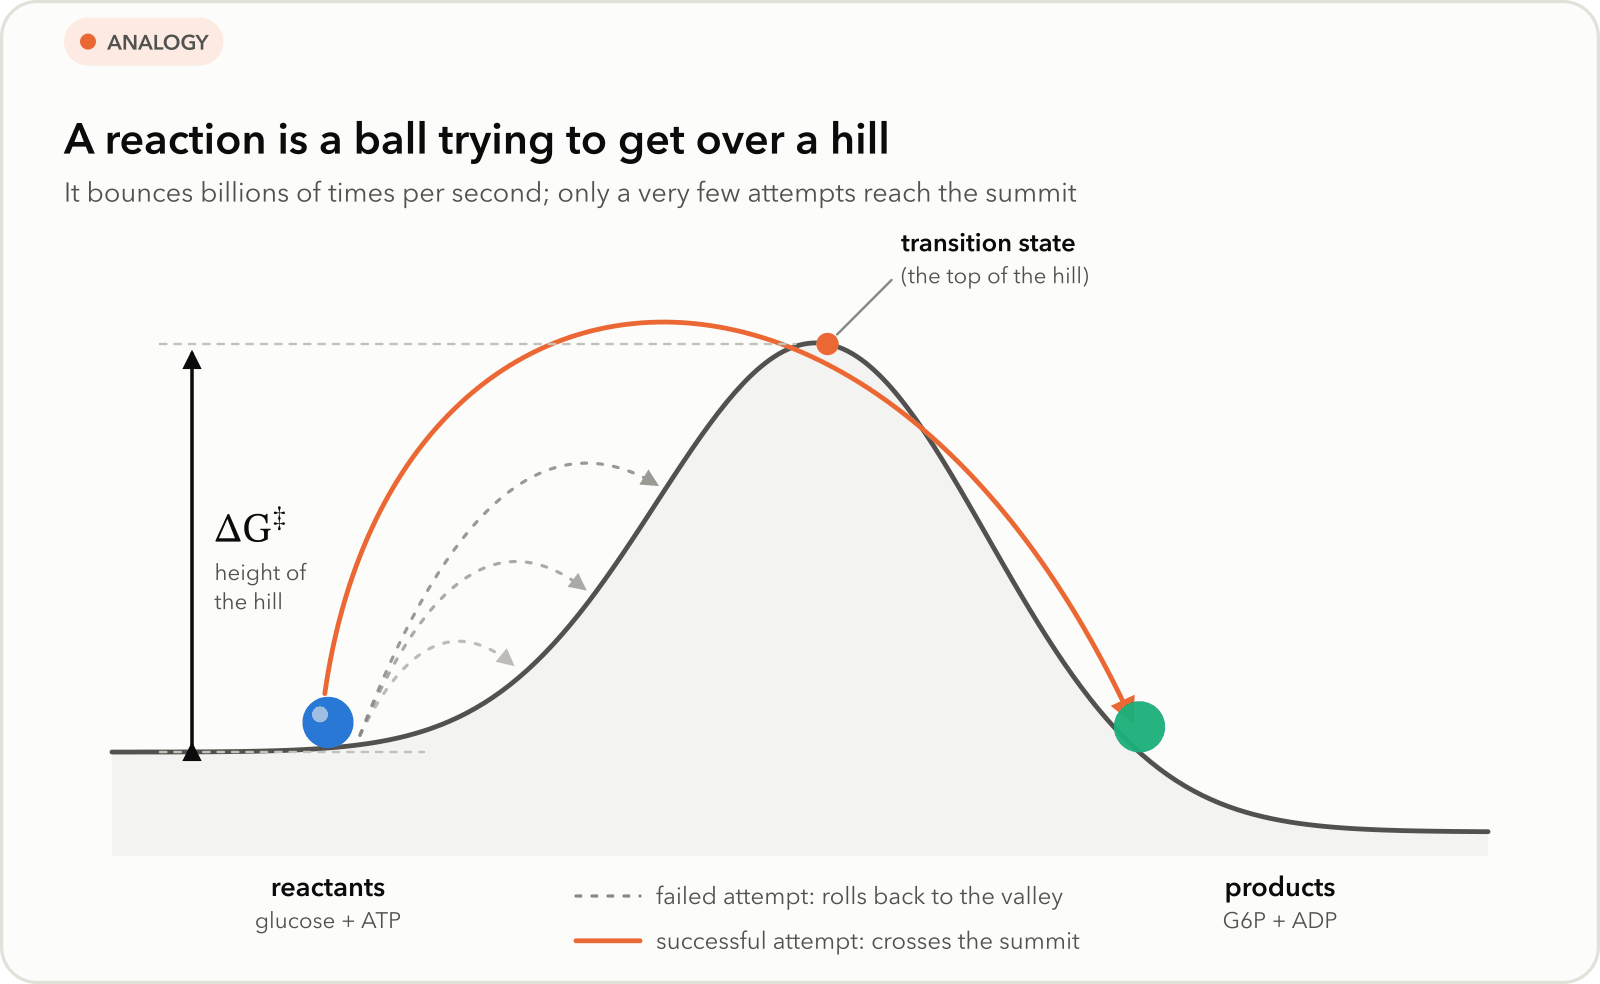

In chemistry the hill is called the **activation barrier** and its summit the **transition
state**. An enzyme does not kick the ball harder: **it lowers the hill**.

---

### 🧮 The equation in words

**Why do we want an equation?** To go from "the hill is high" to "the reaction happens 60 times
per second". With a number we can compare the simulation with the experiment.

The idea is the same as in any game of chance: if you roll a die many times, the number of
"sixes" per minute is *(rolls per minute)* × *(probability of rolling a six)*. Here:

$$\text{rate} \;=\; \underbrace{\text{attempts per second}}_{\text{a huge number}} \;\times\; \underbrace{\text{probability of reaching the summit}}_{\text{tiny}}$$

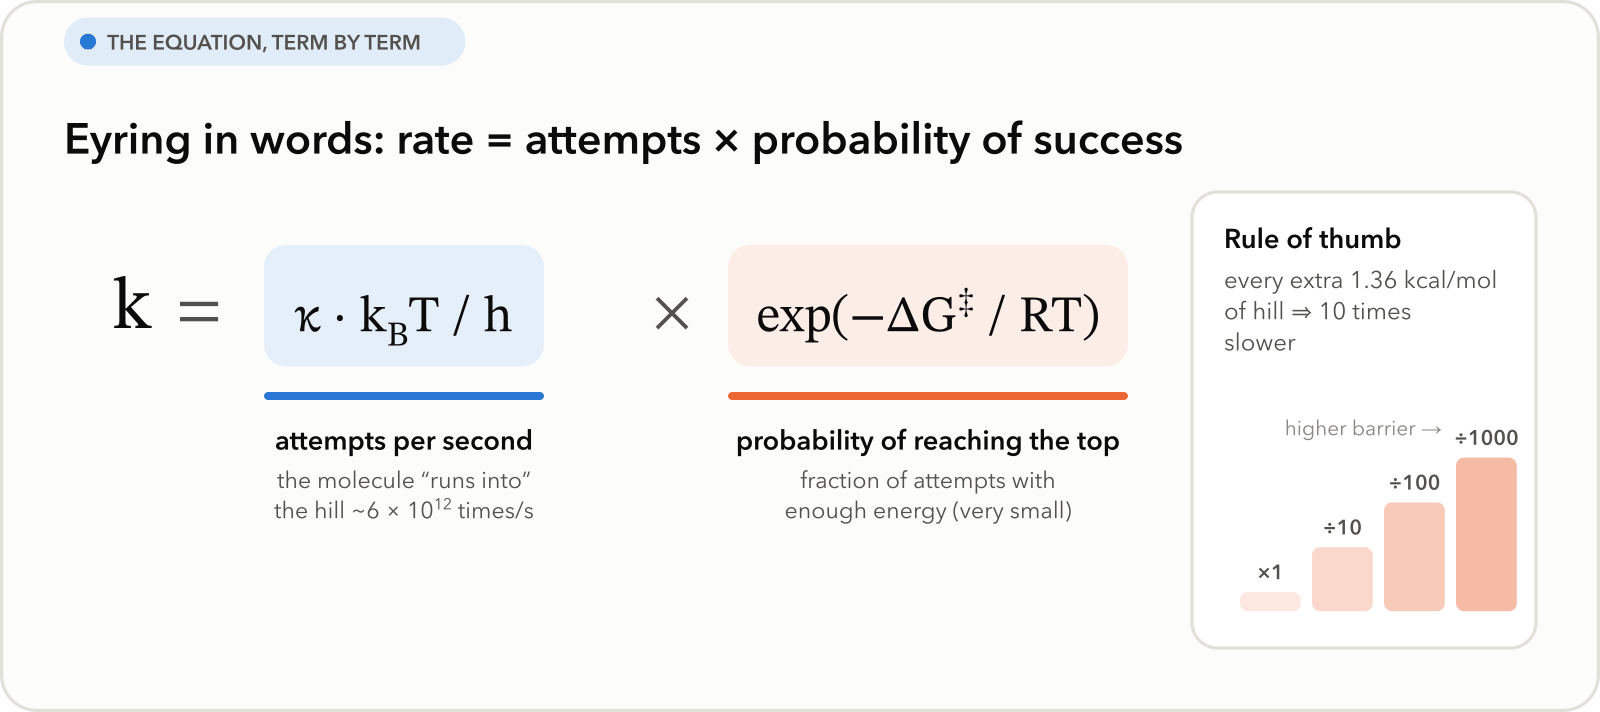

---

### 📐 The full equation, term by term (Eyring, 1935)

$$k \;=\; {\color{#2a78d6}{\kappa\,\frac{k_B T}{h}}}\;\times\;{\color{#eb6834}{\exp\!\left(-\frac{\Delta G^{\ddagger}}{RT}\right)}}$$

The **blue** factor is the attempts; the **orange** one, the probability that an attempt reaches
the summit. Each symbol:

| Term | What it is | In the analogy | Typical value |
|---|---|---|---|
| $k$ | rate constant | how many balls cross per second | ≈ 60 s⁻¹ for glucokinase |
| $k_B T/h$ | attempt frequency | how many times per second the ball is thrown uphill | 6.2 × 10¹² s⁻¹ at 25 °C |
| $\Delta G^{\ddagger}$ | free energy of activation | the height of the hill | 10–25 kcal/mol |
| $R T$ | available thermal energy | the typical strength of the thermal kicks | 0.59 kcal/mol at 25 °C |
| $\kappa$ | transmission coefficient | fraction of balls that, once at the summit, do not turn back | ≈ 1 |

Why an **exponential**? Because getting high up requires many favourable kicks in a row, and the
probability of them all happening multiplies: every extra step of height divides the probability
by the same factor. That is why what matters is the ratio $\Delta G^{\ddagger}/RT$: how many
"typical kicks" tall the hill is.

---

### 🎛️ What if…

| If… | then… | because… |
|---|---|---|
| **ΔG‡ goes up by 1.36 kcal/mol** | the reaction is **10 times slower** | the exponential drops to one tenth (the golden rule) |
| **T goes from 25 to 37 °C** | for a 15 kcal/mol barrier, the rate **almost doubles** | the thermal kicks (RT) are 4 % stronger and the exponential amplifies it |
| **the enzyme lowers ΔG‡ by 10 kcal/mol** | the reaction runs **10⁷ times** faster | 10 / 1.36 ≈ 7 steps of ×10 |

Try it yourself with the sliders:

In [ ]:
# @title 🎛️ Explore the Eyring equation
# 🎛️ Explore the Eyring equation: barrier and temperature
interactivo.explorar_eyring()

In [ ]:
# @title 🎛️ Draw your own energy hill
# 🎛️ Energy profile: barrier (uphill) and reaction energy (drop between valleys)
interactivo.explorar_perfil_energia()

In [ ]:
# @title 📉 Every 1.36 kcal/mol, a factor of 10
barreras = np.linspace(5, 30, 200)
kcat = valor("kcat_s", 60.0)
fig, ax = viz.figure(10.5, 5.8)
k_curva = cin.eyring_rate(barreras)
ax.fill_between(barreras, k_curva.min() / 1e3, k_curva, color=viz._tint(viz.COLORS["reactivo"], 0.9), zorder=1, lw=0)
ax.semilogy(barreras, k_curva, color=viz.COLORS["reactivo"], lw=2.8, zorder=3)
puntos = [(cin.barrier_from_rate(kcat), f"glucokinase\nk_cat ≈ {kcat:.0f} s⁻¹", viz.COLORS["ts"], (12, 6), "left"),
          (cin.barrier_from_rate(1e-8), "a reaction that\ntakes years", viz.INK_SECONDARY, (-16, -10), "right")]
for dg, texto, color, off, ha in puntos:
    viz._guide(ax, "v", dg, start=k_curva.min() / 1e3, end=cin.eyring_rate(dg))
    viz._keypoint(ax, dg, cin.eyring_rate(dg), color, size=11)
    ax.annotate(f"{texto}\nΔG‡ ≈ {dg:.1f} kcal/mol", (dg, cin.eyring_rate(dg)), xytext=off, textcoords="offset points",
                ha=ha, va="bottom" if off[1] > 0 else "top", fontsize=11, color=viz.INK)
# the staircase: 3 steps of 1.36 kcal/mol up from the glucokinase barrier
dg0 = cin.barrier_from_rate(kcat)
for j in range(3):
    a, b = dg0 + j * 1.364, dg0 + (j + 1) * 1.364
    ax.plot([a, b, b], [cin.eyring_rate(a), cin.eyring_rate(a), cin.eyring_rate(b)], color=viz.INK_MUTED, lw=1.2, zorder=4)
    ax.annotate("÷10", (b, np.sqrt(cin.eyring_rate(a) * cin.eyring_rate(b))), xytext=(4, 0), textcoords="offset points",
                ha="left", va="center", fontsize=10, color=viz.INK_SECONDARY)
ax.set_xlim(5, 30); ax.set_ylim(k_curva.min() / 1e3, k_curva.max() * 10)
viz._finish(ax, "ΔG‡: height of the hill (kcal/mol)", "k (s⁻¹, log scale)",
            "Every 1.36 kcal/mol of barrier changes the rate 10-fold",
            "Each grey step raises the hill by 1.36 kcal/mol and divides the rate by 10.")
dg_tab = np.r_[np.arange(10, 30, 2.0), dg0]
dg_tab.sort()
k_tab = cin.eyring_rate(dg_tab)
viz.mostrar(fig, viz.datos(
    pd.DataFrame({"ΔG‡": dg_tab, "k": k_tab, "time per reaction": [viz.duracion(1 / k) for k in k_tab]}),
    "the Eyring equation",
    "Each row is a point on the line: pick a hill height, compute k with the Eyring equation at 25 °C "
    "and, turning it around, how long one reaction takes on average.",
    x="ΔG‡", y="k", calculadas={"k": "(k_B·T/h) · exp(−ΔG‡/RT), with k_B·T/h = 6.2 × 10¹² s⁻¹ and RT = 0.59 kcal/mol",
                               "time per reaction": "1 / k"},
    unidades={"ΔG‡": "kcal/mol", "k": "s⁻¹"}, formatos={"ΔG‡": "{:.1f}"},
    resaltar={int(np.argmin(np.abs(dg_tab - dg0))): ("k_cat", "naranja")}))

> ✅ **Takeaway.** Rate = attempts × probability of success. The attempts are almost fixed
> (~10¹³ per second); what decides everything is the height of the hill, and every 1.36 kcal/mol
> is a factor of 10. An enzyme speeds up the reaction by **lowering the hill**, not by pushing harder.

## 7. Watching the reaction with quantum mechanics: QM/MM

> 🎯 **In this section** you will see why quantum mechanics is needed to watch the phosphate jump
> from ATP to glucose, why it cannot be used for the whole enzyme, and how the **QM/MM** method
> combines the best of both worlds.

---

### 💡 The analogy: photographing a match

To photograph a football match you do not need to focus on all 50 000 spectators: you focus on
the ball and the nearby players, and the stadium stays in the background. In the enzyme, "the
ball" is the jumping phosphate; the stadium is the rest of the protein and the water.

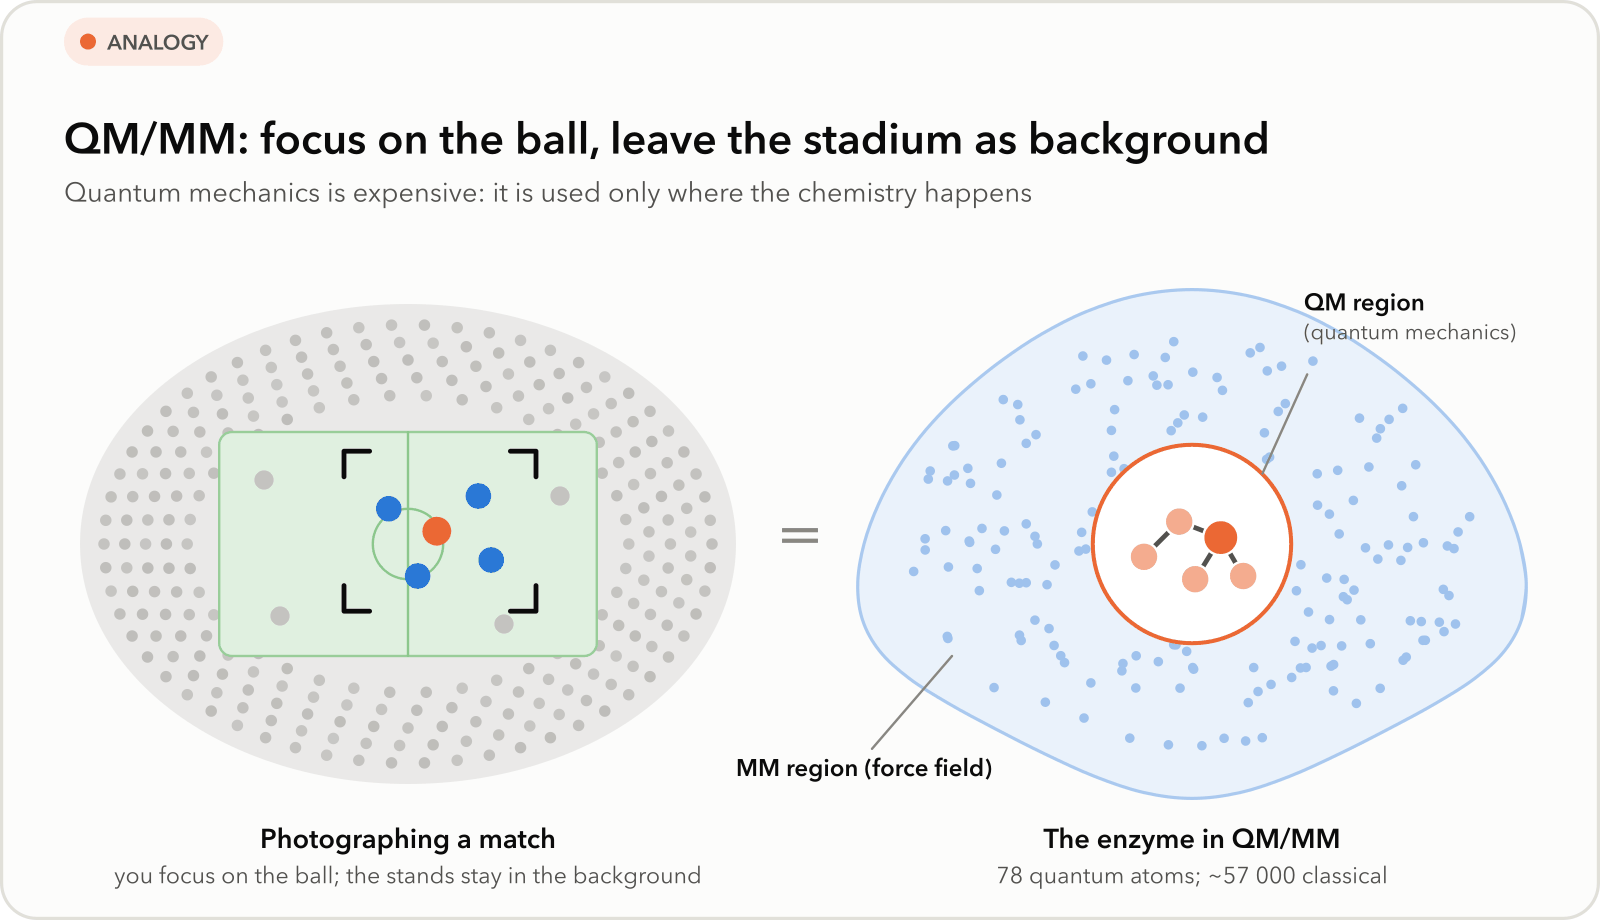

**Why is molecular dynamics not enough?** The classical molecular dynamics of section 5 cannot
break or form bonds: its springs know nothing about electrons. To see the phosphate jump from ATP
to glucose we need **quantum mechanics (QM)**, which does describe the electrons. But it is very
expensive: impossible for 57 000 atoms.

**The solution: QM/MM.** Only the small piece where the chemistry happens (the **QM region**, a
few dozen atoms) is treated with QM, and the rest with the classical force field (**MM region**).
The two regions "see" each other:

* the charges of the MM region create an electric potential that enters the quantum calculation
  (**electrostatic embedding**), and
* the MM region pushes on the QM region with van der Waals forces (**Lennard‑Jones**): without
  this the QM region would "sink" into the protein, because electrostatics alone only attracts.

---

### 🧮 The equation in words

**Why do we want an equation?** To search for the reaction path, the program needs the energy
(and the forces) of every geometry it tries. In QM/MM that energy has two parts:

$$\text{energy} \;=\; \underbrace{\text{quantum energy of the QM region (in the field of the enzyme)}}_{\text{the in-focus photo}} \;+\; \underbrace{\text{the "elbows" between QM and MM}}_{\text{not walking through the crowd}}$$

Back to the stadium: the players we focus on (the QM region) hear the shouting from the stands
(the charges of the enzyme, which attract or repel their electrons), but they cannot push *into*
the crowd: the elbows of the people around them stop them (the short-range repulsion).

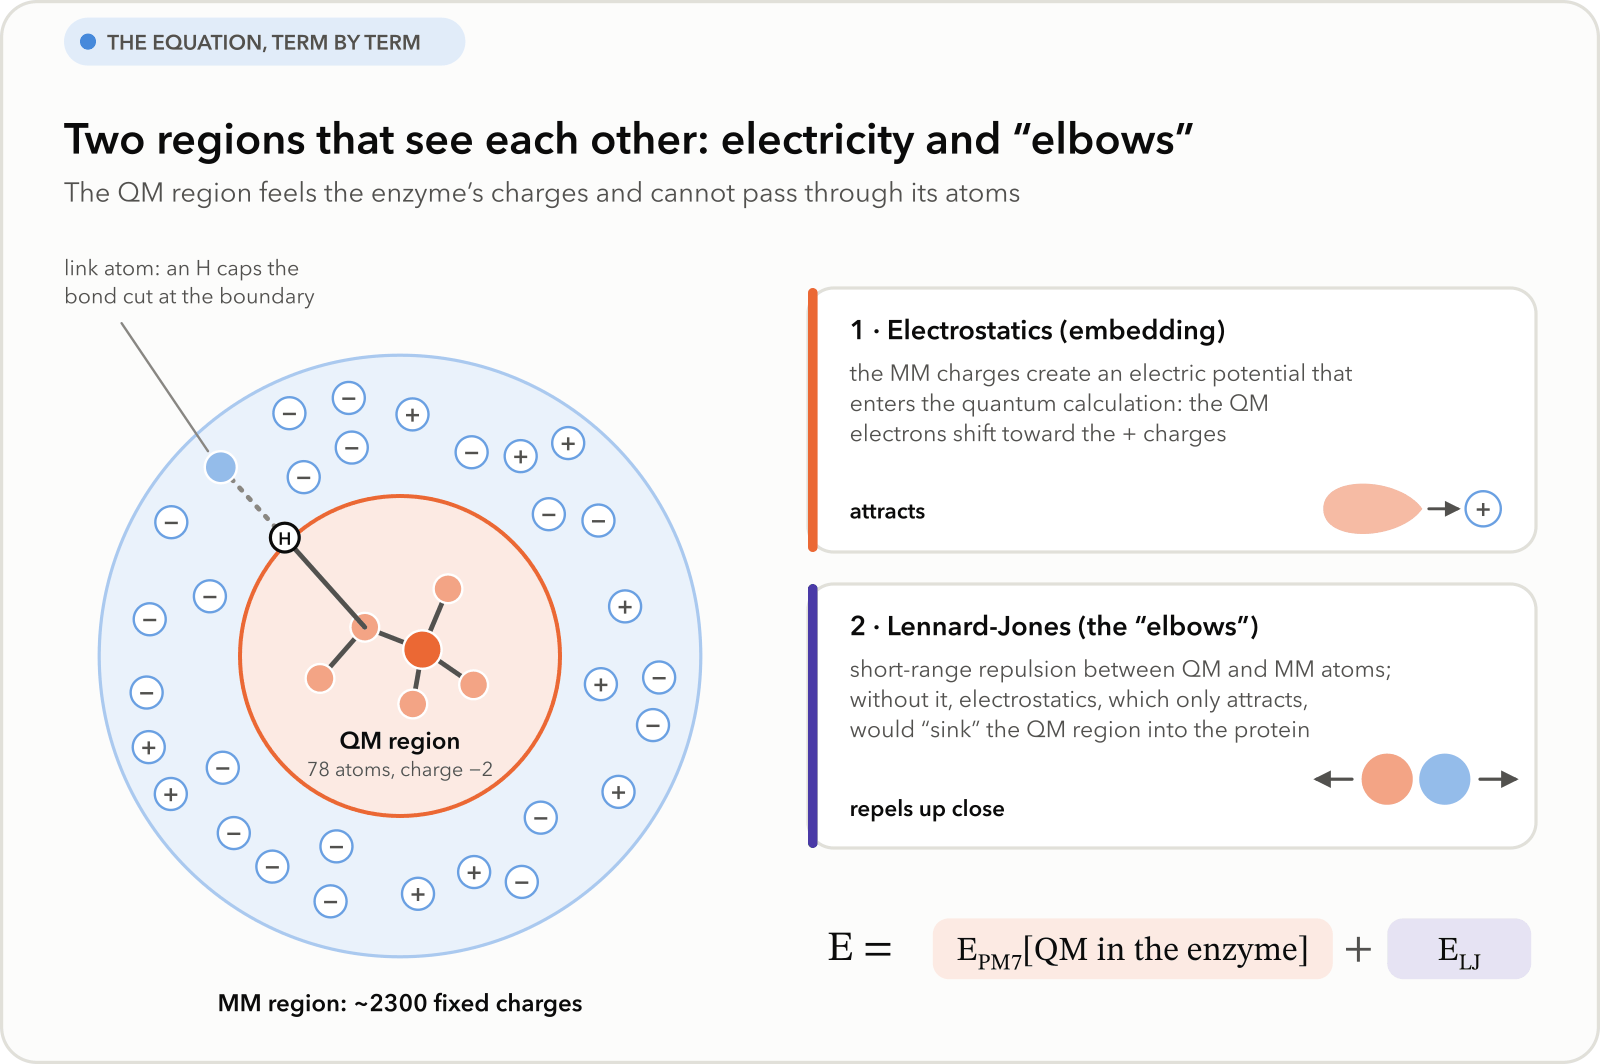

---

### 📐 The full equation, term by term

$$E \;=\; {\color{#eb6834}{E_{\mathrm{PM7}}\big[\text{QM in the potential of the enzyme}\big]}} \;+\; {\color{#4a3aa7}{E_{\mathrm{LJ}}(\text{QM–MM})}}$$

| Term | What it is | In the analogy | In our model |
|---|---|---|---|
| ${\color{#eb6834}{E_{\mathrm{PM7}}[\dots]}}$ | energy of the electrons and nuclei of the QM region, computed with the semiempirical PM7 method | the players in the middle, sharply in focus | 78 atoms, charge −2 |
| potential of the enzyme | the electric field of the MM charges, included *inside* the quantum calculation (embedding) | the music and the shouting of the crowd | ~2300 Amber charges within 16 Å, fixed |
| ${\color{#4a3aa7}{E_{\mathrm{LJ}}}}$ | Lennard‑Jones between QM and MM atoms: weak attraction far away, strong repulsion up close | the elbows of the crowd | Amber parameters |
| link atom | an H that "caps" each covalent bond cut by the boundary | — | side chains cut at the boundary |

**Our recipe (tools from the Leonardo suite, MOPAC PM7 + Amber):**

* **QM region** (78 atoms, charge −2): glucose, the C5'–triphosphate fragment of ATP, the side
  chains of Asp205, Lys169 and Thr228, the Mg²⁺ and its coordinated water.
* Wherever a covalent bond crosses the boundary a **link atom** (an H) is placed.
* The **MM environment** (2300 charges within 16 Å) is kept **fixed** (rigid-environment
  approximation).
* Total energy: $E = E_{\mathrm{PM7}}[\text{QM in the potential of the enzyme}] + E_{\mathrm{LJ}}(\text{QM–MM})$.

---

### 🎛️ What if…

| If… | then… |
|---|---|
| **we remove the potential of the enzyme** | the QM region no longer "sees" the protein: it is like taking it out (section 11 does this, in water) |
| **we remove the Lennard‑Jones term** | electrostatics, which only attracts, "sinks" the QM region into the protein and the geometry stops making sense |
| **we enlarge the QM region** | the model is more faithful, but each calculation costs much more |
| **we let the MM environment move** | the calculation would be more realistic and much more expensive; with a fixed environment, the barrier depends on the chosen conformation (section 10) |

---

### 🔬 The real data: our partition

In [ ]:
# @title 🔍 The quantum region inside the enzyme
particion = datos.json_("qmmm/particion.json")
print(f"QM region: {particion['n_qm']} atoms + {particion['n_link']} link H; free: {particion['n_free']}")
print(f"MM environment: {particion['n_mm']} point charges; QM charge = {particion['qm_charge']}; MM charge = {particion['mm_charge']:.2f} e")
print("QM atoms per residue:", pd.Series([a["resname"] for a in particion["qm_atoms"]]).value_counts().to_dict())
display(visor3d.region_qm())

**How do we know the program computes the forces correctly?** By comparing the analytic gradient
with the numerical one (move an atom by 0.005 Å and see how much the energy changes). Every
simulation code should pass this check before it is used:

In [ ]:
# @title 🧪 Quality control: analytic versus numerical forces
grad = datos.csv("qmmm/comprobacion_gradiente.csv")
grad["relative error"] = (grad["diff"].abs() / grad["analytic"].abs().clip(lower=1e-6)).map(lambda x: f"{x:.1%}")
display(grad.round(3))

> ✅ **Takeaway.** QM/MM focuses quantum mechanics where the chemistry happens (78 atoms) and
> treats the rest of the enzyme as classical charges and "elbows". The energy has two parts: the
> quantum energy of the QM region **inside the electric field of the enzyme** and the
> Lennard‑Jones repulsion that keeps it from sinking into the protein.

## 8. Reactant, product and the energy profile

> 🎯 **In this section** you will describe the whole reaction with **a single number**, the
> reaction coordinate ξ, and obtain the first energy profile of the phosphate transfer inside the
> enzyme.

---

### 💡 The analogy: the ribbon in a tug of war

In a tug of war, the ribbon tied to the middle of the rope tells you who is winning: if it is on
one team's side, that team is ahead; if it is in the middle, it is a draw. Here the rope is the
phosphate group (the Pγ), and the two "teams" are the O3β oxygen of ATP (which lets it go) and the
O6 oxygen of glucose (which receives it).

First we relax the QM region at its starting point (the **reactant**: glucose + ATP). Then we
build the **product** (glucose‑6‑phosphate + ADP, with the O6 proton already on Asp205) and relax
it too. The energy difference tells us whether the reaction is "downhill" or "uphill" inside the
enzyme.

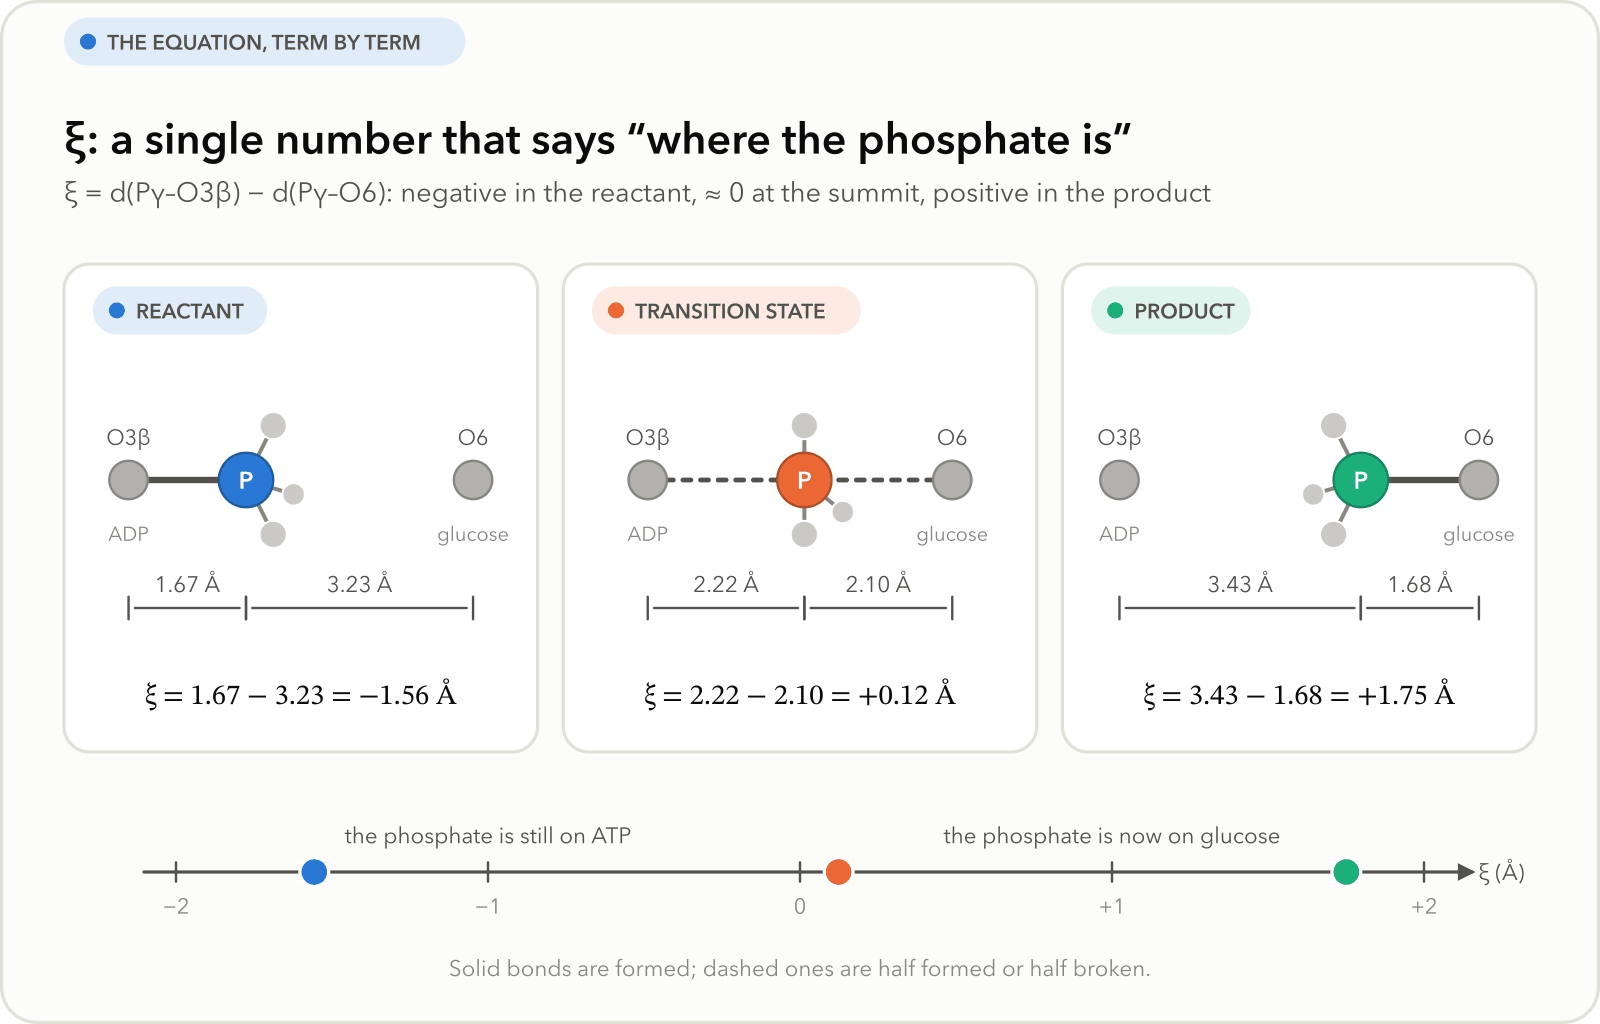

---

### 🧮 The equation in words

**Why do we want an equation?** A reaction moves dozens of atoms at once; to draw an energy
profile we need a horizontal axis, a number that advances continuously from the reactant to the
product.

$$\xi \;=\; \text{how far the phosphorus has moved away from ADP} \;-\; \text{how far it still is from glucose}$$

---

### 📐 The full equation, term by term

$$\xi \;=\; {\color{#2a78d6}{d(\mathrm{P_\gamma\!-\!O_{3\beta}})}} \;-\; {\color{#1baf7a}{d(\mathrm{P_\gamma\!-\!O_6})}}$$

The **blue** term is the bond that is breaking (reactant side); the **aquamarine** one, the bond
that is forming (product side).

| Situation | d(Pγ–O3β) | d(Pγ–O6) | ξ | In the analogy | In our calculation |
|---|---|---|---|---|---|
| reactant (phosphate on ATP) | short (1.6 Å) | long (3.2 Å) | negative | the ribbon on the ATP side | ξ = −1.56 Å |
| transition state | intermediate | intermediate | ≈ 0 | the ribbon in the middle | ξ = +0.12 Å |
| product (phosphate on glucose) | long | short (1.7 Å) | positive | the ribbon on the glucose side | ξ = +1.75 Å |

---

### 🎛️ What if…

| If… | then… | because… |
|---|---|---|
| **the phosphorus moves 0.1 Å** towards glucose, in line | ξ goes up by about **0.2 Å** | one distance grows while the other shrinks at the same time |
| **ξ = 0** | the phosphorus is equally far from both oxygens, but that **does not guarantee** it is the summit | the summit is the energy maximum, which is searched for separately (section 9) |
| **we fix ξ** at an intermediate value and let everything else relax | we get one point of the **relaxed scan** | the restraint holds the geometry "halfway" |

A **relaxed scan** fixes ξ at intermediate values (with a harmonic restraint) and lets everything
else adjust: the result is an approximate **energy profile**, and its highest point is a first
estimate of the transition state.

---

### 🔬 The real data

In [ ]:
# @title ⚗️ Reactant and product inside the enzyme
if MODO == "completo":
    subprocess.run([sys.executable, "scripts/03_qmmm_reaccion.py"], check=True)

res = datos.json_("qmmm/resumen.json")
R, P = res["etapas"]["reactivo"], res["etapas"]["producto"]
viz.tarjetas(
    [("Reactant · ξ", f"{R['xi']:+.2f}".replace("-", "−"), "Å",
      f"Pγ–O3β {R['d_PG_O3B']:.2f} Å (bonded) · Pγ–O6 {R['d_PG_O6']:.2f} Å (free)", "azul"),
     ("Product · ξ", f"{P['xi']:+.2f}", "Å",
      f"Pγ–O6 {P['d_PG_O6']:.2f} Å (bonded) · Pγ–O3β {P['d_PG_O3B']:.2f} Å (free)", "agua"),
     ("The O6 proton", f"{P['d_OD1_H']:.2f}", "Å",
      f"in the product it sits on Asp205 (in the reactant, O6–H = {R['d_O6_H']:.2f} Å)", "violeta"),
     ("Reaction ΔE", f"{P['dE_reaccion_kcal']:+.1f}", "kcal/mol", "uphill inside the enzyme (PM7, fixed environment)", "naranja")],
    titulo="The two ends of the reaction, relaxed in the enzyme")

In [ ]:
# @title 📈 The energy profile of the reaction
escaneo = datos.csv("qmmm/escaneo.csv")
xi_esc = np.r_[R["xi"], escaneo["xi"].values]                   # the profile starts at the relaxed reactant (E = 0)
e_esc = np.r_[0.0, escaneo["energia_rel_kcal"].values]
fig = viz.plot_energy_profile(xi_esc, e_esc, relative=False, xlabel="ξ = d(Pγ–O3β) − d(Pγ–O6)  (Å)",
                              ts_index=int(np.argmax(e_esc)), annotate_states=True,
                              state_names=("reactant\nphosphate on ATP", "summit: 1st TS estimate", "product\nphosphate on glucose"),
                              title=f"To move the phosphate you must climb a {e_esc.max():.0f} kcal/mol hill",
                              subtitle="Relaxed scan: ξ is fixed at each point and everything else relaxes (PM7 in the field of the enzyme)")
tabla_esc = pd.DataFrame({
    "point": ["reactant"] + [str(int(p)) for p in escaneo["punto"]],
    "fixed ξ": np.r_[np.nan, escaneo["xi_objetivo"].values],
    "Pγ–O3β": np.r_[R["d_PG_O3B"], escaneo["d_PG_O3B"].values],
    "Pγ–O6": np.r_[R["d_PG_O6"], escaneo["d_PG_O6"].values],
    "ξ": xi_esc,
    "O6–H": np.r_[R.get("d_O6_H", np.nan), escaneo["d_O6_H"].values],
    "E": e_esc})
k_ts = int(np.argmax(e_esc))
viz.mostrar(fig, viz.datos(
    tabla_esc, "the reaction scan",
    "Each row is an optimized geometry. The program fixes ξ at a value (\"fixed ξ\"), relaxes all the other atoms and "
    "measures the energy. Notice how Pγ–O3β (the breaking bond) gets longer while Pγ–O6 (the forming bond) gets shorter.",
    x="ξ", y="E", calculadas={"ξ": "d(Pγ–O3β) − d(Pγ–O6)", "E": "energy of the point − energy of the relaxed reactant"},
    unidades={"fixed ξ": "Å", "Pγ–O3β": "Å", "Pγ–O6": "Å", "ξ": "Å", "O6–H": "Å", "E": "kcal/mol"},
    formatos={c: "{:.2f}" for c in ("fixed ξ", "Pγ–O3β", "Pγ–O6", "ξ", "O6–H")} | {"E": "{:.1f}"},
    resaltar={0: ("R", "azul"), k_ts: ("summit", "naranja"), len(tabla_esc) - 1: ("P", "agua")}, barra="E"))

> **A detail worth noticing.** The profile starts with a jump of ~4 kcal/mol between the reactant
> (ξ = −1.56 Å, E = 0) and the first point of the scan. The initial optimization of the reactant
> stopped on a *shoulder* of the surface; the true minimum appeared later, when descending from the
> transition state (section 9). Practical lesson: a "converged" optimizer does not guarantee the
> lowest minimum; that is why reaction paths are checked in both directions.

### 🎬 Watch it happen

Now the movie: the atoms on the left and, on the right, the **energy profile with a yellow dot
that follows the movie**. Press ▶ or drag the bar. Watch three things:

1. The **pink** bond (Pγ–O3β, on ATP) gets thinner and turns dashed: **it is breaking**.
2. The **aqua** bond (Pγ–O6, towards glucose) appears and thickens: **it is forming**.
3. At the summit of the plot (the transition state) both are half-formed: the phosphorus sits
   **between** the two oxygens.

Only real bonds are drawn: those of the model's topology, plus these four changing ones, with a
thickness proportional to their bond order (solid when formed, dashed when half-formed or
half-broken). The thin green lines are the coordination of Mg²⁺, which is not a covalent bond.
The movie follows the minimum-energy path computed in section 9, from the relaxed reactant to the
product.

In [ ]:
# @title 🎬 The reaction in motion, synchronized with its energy
visor3d.pelicula_reaccion("enzima")

> ✅ **Takeaway.** ξ = d(Pγ–O3β) − d(Pγ–O6) sums up the reaction in a single number: negative
> with the phosphate on ATP, close to zero at the summit, positive with the phosphate on glucose.
> A relaxed scan along ξ gives the first energy profile and a first estimate of the barrier,
> which section 9 refines.

## 9. The transition state

> 🎯 **In this section** you will locate the true transition state (a saddle point), **validate**
> it with its vibrational frequencies and check that it connects the reactant with the product.

---

### 💡 The analogy: the mountain pass, again

The scan gave us an approximate hill, but by forcing a single distance. The true transition state
is a **saddle point**: a maximum along the path and a minimum in every other direction, exactly
like the pass between two mountains (if you step off the trail, you go up).

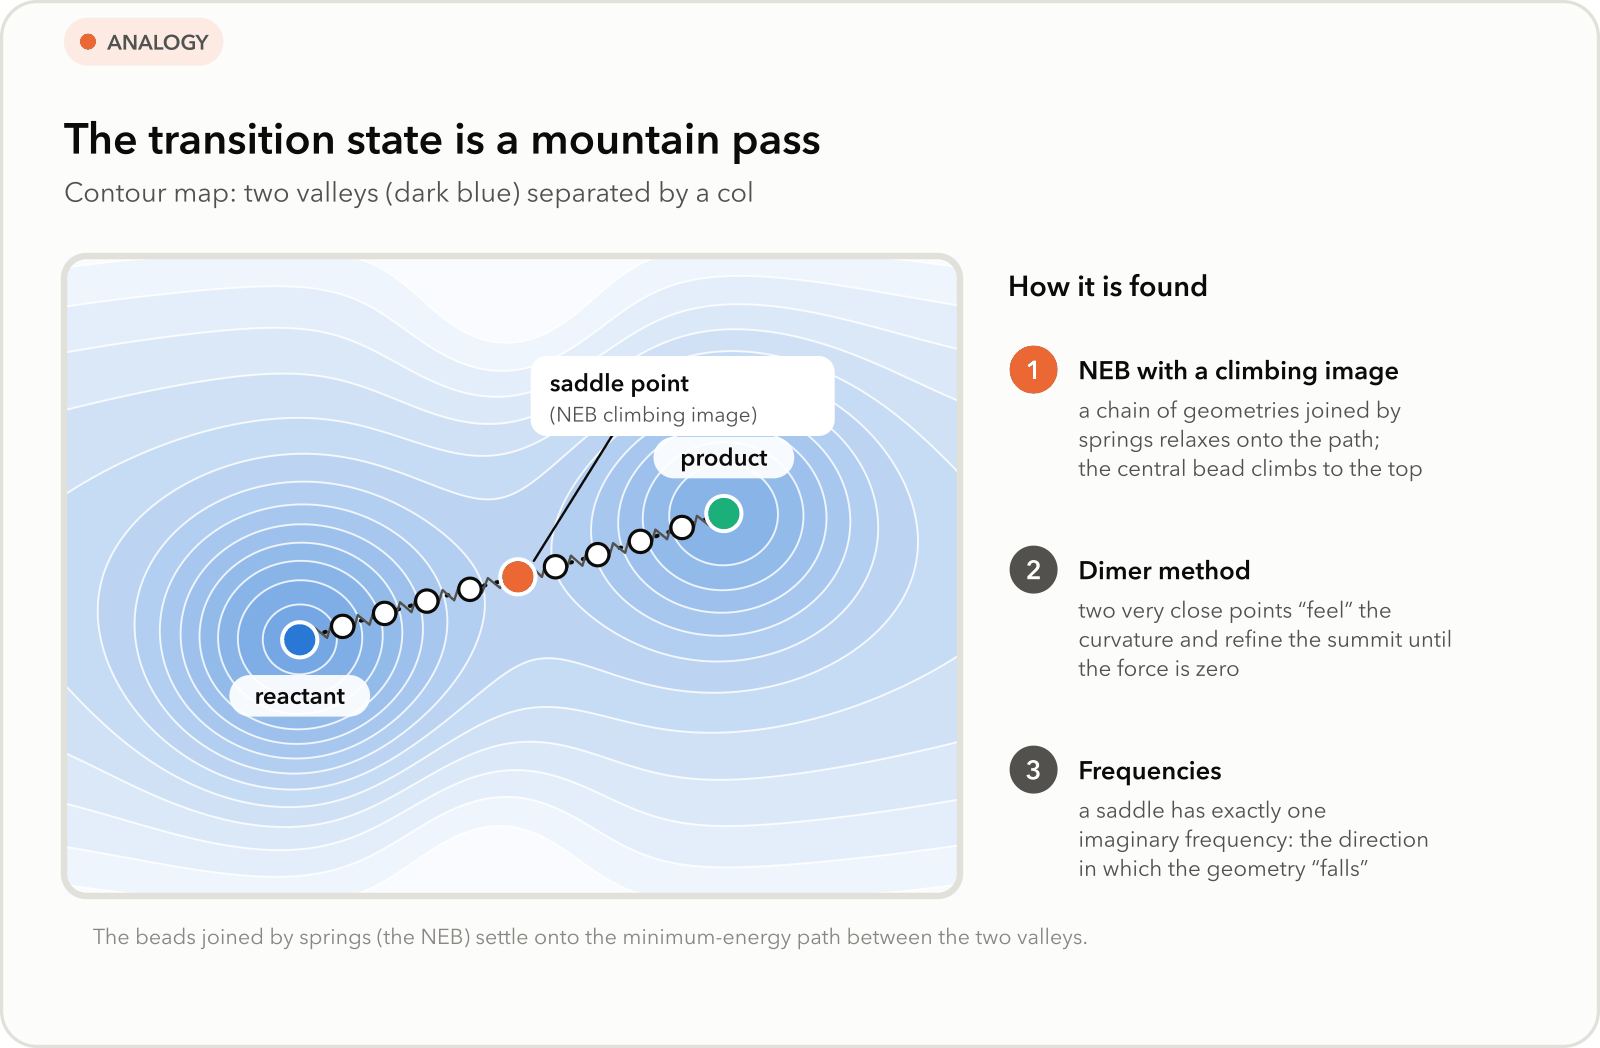

**How it is located (three steps):**

1. **Climbing-image NEB** (*nudged elastic band*): a chain of geometries between reactant and
   product, joined by springs, that relaxes until it traces the minimum-energy path. The highest
   image "climbs" to the summit. It is the modern analogue of the **QST2** method (two end points →
   TS) in Gaussian and MOPAC.
2. **Dimer method**: refines the summit using only gradients, until the force is zero.
3. **Frequencies**: a true saddle point has **exactly one** imaginary frequency, and its vector
   describes the motion of the reaction. This is the definitive test.

---

### 🧮 The test in words: why "imaginary"?

**Why do we want an equation?** At the summit the force is zero… but so it is at the bottom of a
valley. To tell them apart we look at **the shape** of the terrain around the point, and that is
what the vibrations give us. Each vibration is like a **spring**: the steeper the walls, the
faster it oscillates.

$$\text{frequency} \;\propto\; \sqrt{\text{spring stiffness}}$$

In a valley every wall goes up: all the springs are normal. At the saddle, along the path the
terrain goes **down** on both sides: it is an "upside-down spring" (negative stiffness), and the
square root of a negative number is an **imaginary** number. Programs write it as a negative
frequency.

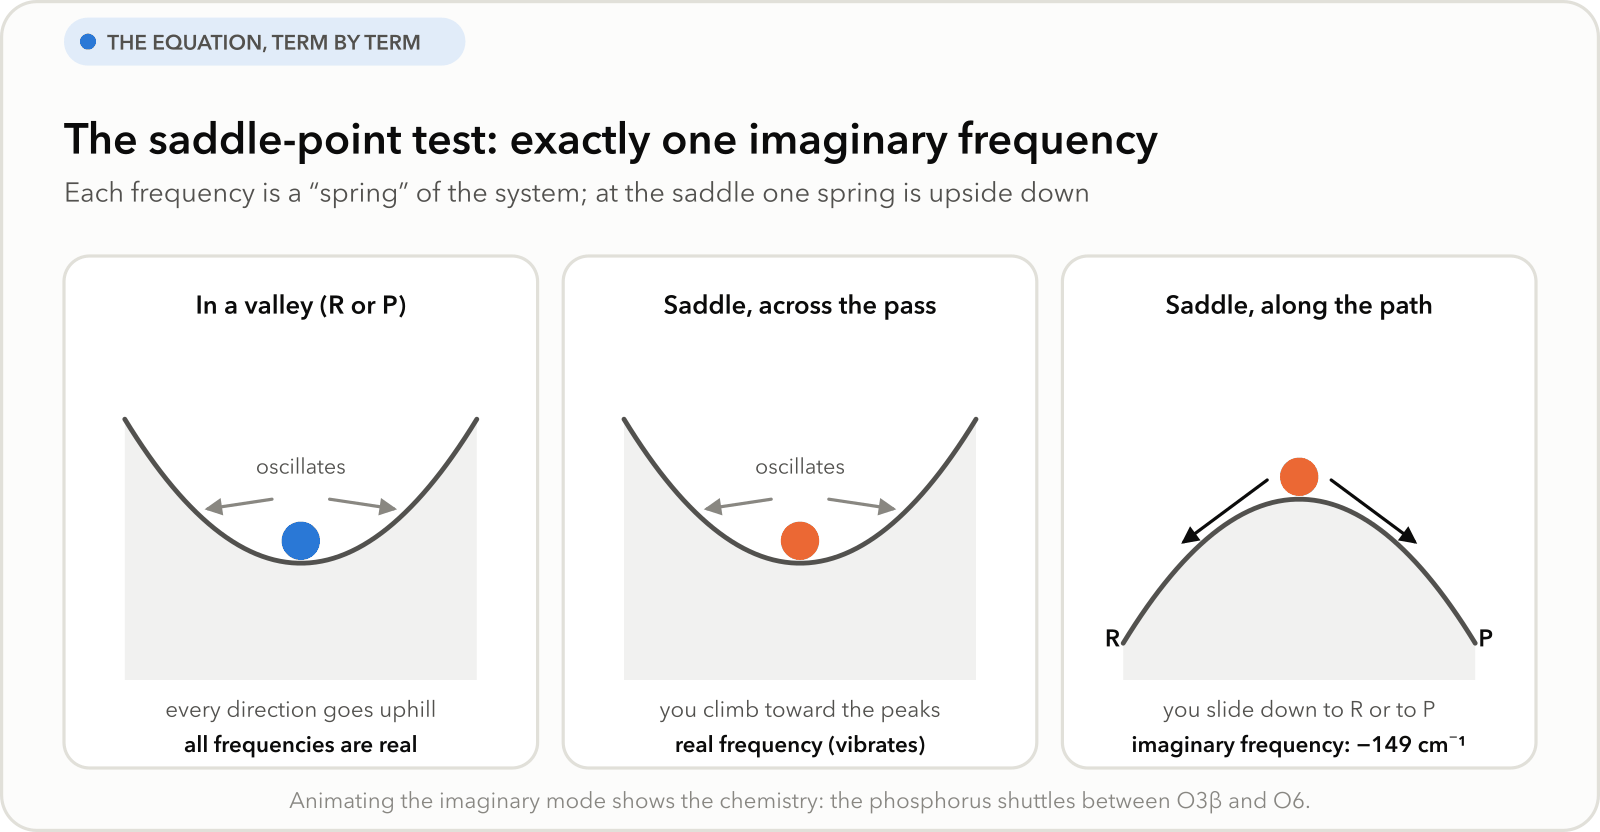

---

### 📐 The full equation, term by term

$$\nu \;=\; \frac{1}{2\pi}\sqrt{\frac{{\color{#eb6834}{k}}}{\mu}}$$

| Term | What it is | In the analogy | At the transition state |
|---|---|---|---|
| $\nu$ | vibrational frequency (in cm⁻¹ in chemistry) | how many times per second the ball oscillates | −149 cm⁻¹ in the reaction mode |
| ${\color{#eb6834}{k}}$ | curvature of the energy in that direction | the stiffness of the spring: how steep the walls are | **negative** along the path |
| $\mu$ | effective mass that moves | how heavy the ball is | mostly the phosphorus and its oxygens |

---

### 🎛️ What if…

| If the frequency calculation gives… | then the geometry is… |
|---|---|
| **no** imaginary frequency | a **minimum** (reactant, product or an intermediate), not a TS |
| **exactly one** | a **first-order saddle point**: a transition state ✔ |
| **two or more** | a summit in several directions (higher-order saddle): keep searching |

---

### 🔬 The real data

In [ ]:
# @title ⛰️ From the scan to the minimum-energy path (NEB)
neb = datos.csv("qmmm/neb.csv")
perfiles = [(xi_esc, e_esc, "restrained scan"),
            (np.r_[R["xi"], neb["xi"].values[1:]], np.r_[0.0, neb["energia_rel_kcal"].values[1:]], "NEB (climbing image)")]
fig = viz.plot_energy_profiles(perfiles, xlabel="ξ (Å)", relative=False, colors=[viz.INK_MUTED, viz.COLORS["reactivo"]],
                               title="The NEB finds the same summit along a more natural path",
                               subtitle="Grey: scan that forces a single distance. Blue: NEB, which relaxes all coordinates at once")
tabla_neb = pd.DataFrame({"image": neb["imagen"] if "imagen" in neb else np.arange(len(neb)),
                          "ξ": np.r_[R["xi"], neb["xi"].values[1:]], "E": np.r_[0.0, neb["energia_rel_kcal"].values[1:]]})
viz.mostrar(fig, viz.datos(
    tabla_neb, "the NEB (the chain of images)",
    "Each row is a \"bead\" of the elastic chain that joins reactant and product. At the end of the optimization the highest "
    "image has climbed to the summit: that is the estimate of the transition state.",
    x="ξ", y="E", unidades={"ξ": "Å", "E": "kcal/mol"}, formatos={"ξ": "{:+.2f}", "E": "{:.1f}"},
    resaltar={0: ("R", "azul"), int(tabla_neb["E"].idxmax()): ("climbing", "naranja"), len(tabla_neb) - 1: ("P", "agua")},
    barra="E"))

In [ ]:
# @title ✅ The transition state and its imaginary frequency
ts = res["etapas"].get("dimero")
if ts is None or not ts.get("convergido", True):
    display(viz.mensaje("The dimer did not converge: the NEB climbing image is used as the TS.", "ojo"))
    ts = ts or {**res["etapas"]["neb"], "xi": neb.loc[res["etapas"]["neb"]["imagen_ts"], "xi"], "d_PG_O6": float("nan"), "d_PG_O3B": float("nan")}
fr = res["etapas"].get("frecuencias", {})
val = fr["validacion"]
freqs = np.asarray(fr["frecuencias_mas_bajas"])
tarjetas_ts = viz.tarjetas(
    [("Barrier ΔE‡", f"{ts['barrera_kcal']:.1f}", "kcal/mol", "from the relaxed reactant (dimer method)", "naranja"),
     ("ξ at the summit", f"{ts['xi']:+.2f}", "Å", "almost zero: halfway", "naranja"),
     ("Pγ ··· O6 / Pγ ··· O3β", f"{ts['d_PG_O6']:.2f} / {ts['d_PG_O3B']:.2f}", "Å", "the phosphorus, equidistant from both oxygens", "azul"),
     ("Imaginary frequencies", f"{val['imaginary_mode_count']}", "", "first-order saddle point ✔" if val["ok"] else "check ✘",
      "verde" if val["ok"] else "rojo")],
    titulo="The transition state, located and validated")
fig = viz.plot_frequencies([("TS in the enzyme", freqs)],
                           title=f"A single imaginary frequency ({freqs.min():.0f} cm⁻¹): it is a saddle point".replace("-", "−"),
                           subtitle="The six slowest vibrations of the transition state; all the others are real (positive)")
viz.mostrar(tarjetas_ts, fig, viz.datos(
    pd.DataFrame({"mode": np.arange(1, len(freqs) + 1), "frequency": freqs,
                  "type": ["imaginary: the geometry \"falls\"" if f < 0 else "real: the geometry vibrates" for f in freqs]}),
    "the lowest frequencies of the TS",
    "The frequencies come from the matrix of second derivatives of the energy (the Hessian). By convention, a negative "
    "curvature is written as a negative (\"imaginary\") frequency.",
    y="frequency", unidades={"frequency": "cm⁻¹"}, formatos={"frequency": "{:.1f}"},
    resaltar={int(np.argmin(freqs)): ("the reaction", "naranja")}))

**What the geometry of the transition state tells us.** At the TS the phosphorus is at the same
distance from both oxygens (≈ 2.1–2.2 Å from O6 and from O3β): it is a **concerted, "in-line"**
TS; the phosphate passes from one oxygen to the other, flipping its three oxygens like an umbrella.
The O6 proton, on the other hand, **has not moved yet** (it is still ~1.07 Å from O6). Only after
crossing the summit, once the P–O6 bond has formed, does the proton jump to Asp205: the path goes
down a "plateau" until ξ ≈ 1 Å and only then finishes falling. In this model Asp205 acts as a base
**after** the phosphoryl transfer. An independent QM/MM study (Zhang et al., 2009) describes Asp205
as a general base and Lys169 as a general acid that protonates the phosphate; the fact that two
models disagree on the *order* of the steps but agree on the barrier (section 12) is a good
example of why mechanisms are studied with both simulations and mutants.

**The motion of the transition state.** The imaginary frequency corresponds to a vibration that
does not oscillate but "falls" towards the reactant or towards the product. Animating it shows us
the chemistry: watch the phosphorus go back and forth between the O3β of ATP and the O6 of glucose,
and the dot on the plot cross from the "towards the reactant" zone to the "towards the product" zone:

In [ ]:
# @title 🎞️ The motion of the transition state
visor3d.modo_imaginario()

**Coming down from the summit.** If we push the TS a tiny bit to each side along the imaginary
mode and let the geometry relax, we descend along the minimum-energy path to the reactant and to
the product. This confirms that **this** TS connects **these** reactants with **these** products
(the idea of the IRC, *intrinsic reaction coordinate*).

In [ ]:
# @title ⬇️ Down from the summit to reactant and product
camino = datos.csv("qmmm/camino_descenso.csv")
fig = viz.plot_energy_profile(camino["xi"].values, camino["energia_rel_kcal"].values, relative=False, xlabel="ξ (Å)",
                              ts_index=int(camino["energia_rel_kcal"].idxmax()), smooth=False, sort=False, annotate_states=True,
                              state_names=("reactant", "TS", "end of descent"),
                              title="From the summit you come down to both valleys: this TS connects R with P",
                              subtitle="Each point is a relaxed geometry; the plateau after the summit is the proton moving to Asp205")
viz.mostrar(fig, viz.datos(
    camino.rename(columns={"cuadro": "step", "energia_rel_kcal": "E"})[["step", "xi", "E"]].rename(columns={"xi": "ξ"}),
    "the descent from the summit",
    "Each row is a step of the descent: starting from the TS the geometry is nudged a little to each side and allowed to fall. "
    "The steps are in the order of the path, from one valley to the other through the summit.",
    x="ξ", y="E", unidades={"ξ": "Å", "E": "kcal/mol"}, formatos={"ξ": "{:+.2f}", "E": "{:.1f}"},
    resaltar={int(camino["energia_rel_kcal"].idxmax()): ("TS", "naranja")}, barra="E"))

In [ ]:
# @title 📊 Energy diagram of the reaction
niveles = [("E·S (reactant)", 0.0), ("TS", ts["barrera_kcal"]), ("E·P (product)", P["dE_reaccion_kcal"])]
fig = viz.plot_energy_levels(niveles, ts_indices=[1], title="The reaction in three numbers",
                             subtitle="PM7/Amber, fixed environment: relative electronic energies (ΔE), not yet free energies")
viz.mostrar(fig, viz.datos(
    pd.DataFrame({"state": [n for n, _ in niveles], "E": [e for _, e in niveles]}), "the three levels",
    "The three heights of the diagram. The barrier is the difference TS − reactant; the reaction energy, product − reactant.",
    y="E", unidades={"E": "kcal/mol"}, formatos={"E": "{:.1f}"},
    resaltar={0: ("R", "azul"), 1: ("TS", "naranja"), 2: ("P", "agua")}))

> ✅ **Takeaway.** The transition state is a **saddle point**: it is located in steps
> (scan → NEB → dimer) and **validated** with two tests: exactly one imaginary frequency (here
> −149 cm⁻¹, the phosphorus going back and forth) and a path that, coming down from the summit,
> reaches the reactants on one side and the products on the other.

## 10. From ΔE‡ to ΔG‡: three improvements to the calculation

> 🎯 **In this section** you will turn the electronic barrier ΔE‡ into the free energy ΔG‡ that
> the Eyring equation asks for, and learn to ask yourself how much to trust a computed number.

---

### 💡 The analogy: the careful surveyor

A surveyor who has measured the height of a mountain **once, on one day, with one instrument**
asks three questions before publishing the number: does the ground move? would I have measured
something else on another day? is my instrument properly calibrated?

So far we have an **electronic energy** ΔE‡, computed in **one** conformation of the enzyme with
**one** semiempirical method. The Eyring equation asks for a **free energy** ΔG‡. A good
computational scientist asks the same three questions, and answers them with extra calculations:

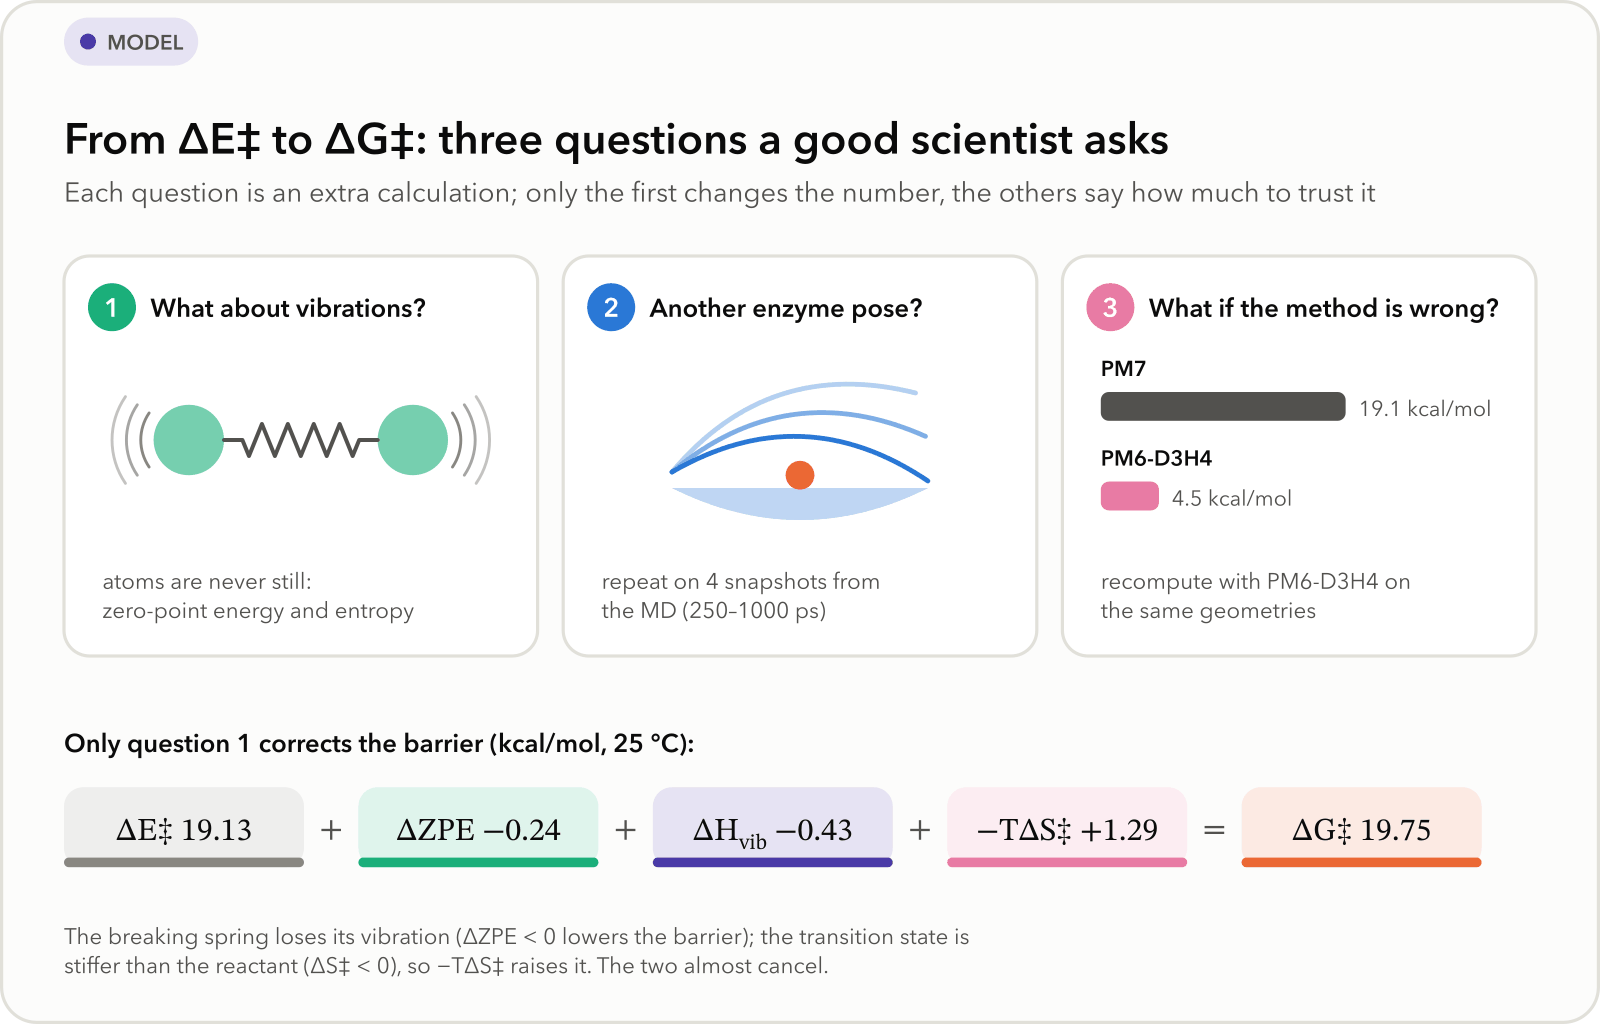

---

### 🧮 The equation in words

**Why do we want an equation?** Because the "bare" height (ΔE‡) ignores that atoms are always
vibrating. The free energy adds what it costs, or saves, in vibration and in order:

$$\text{free barrier} \;=\; \text{electronic barrier} \;+\; \text{vibration at rest} \;+\; \text{thermal vibration} \;-\; T\times\text{(change in disorder)}$$

---

### 📐 The full equation, term by term

$$\Delta G^{\ddagger} = \Delta E^{\ddagger} + {\color{#1baf7a}{\Delta \mathrm{ZPE}}} + {\color{#4a3aa7}{\Delta H_{\mathrm{vib}}(T)}} - {\color{#e87ba4}{T\,\Delta S_{\mathrm{vib}}(T)}}$$

| Term | What it is | In the analogy | Our value (25 °C) |
|---|---|---|---|
| **ΔE‡** | electronic height of the hill, atoms standing still | the "one-day" measurement | 19.1 kcal/mol |
| **ΔZPE** | change in the **zero-point energy**: even at 0 K atoms vibrate | the ground trembles even without wind | −0.2 kcal/mol |
| **ΔH<sub>vib</sub>(T)** | extra vibrational energy at temperature T | the extra trembling on a hot day | −0.4 kcal/mol |
| **−TΔS<sub>vib</sub>** | the price of order: a TS stiffer than the reactant has a negative ΔS‡ | tidying a room takes work | +1.3 kcal/mol |

* **ΔZPE**: the P–O bond that breaks loses its stretching vibration at the TS, so it is usually
  **negative** (it lowers the barrier).
* **−TΔS‡**: if the TS is "stiffer" than the reactant (ΔS‡ < 0), this term **raises** the barrier.

**The other two questions do not change the formula, but our confidence in the number:**

**2. What if the enzyme were in another pose?** Since the environment is fixed, each MD snapshot
can give a different barrier. We repeat the calculation on several snapshots (250, 500, 750 and
1000 ps) to see **whether the barrier changes and why**. A good result is not a number: it is a
number with its uncertainty, and sometimes the answer is that the reaction is not even possible
from some conformations.

**3. What if the method is wrong?** PM7 is semiempirical. We recompute the energies with another
Hamiltonian (PM6‑D3H4) on the same geometries: if the barrier changes little, the result is
robust; if it changes a lot, we know how much to (dis)trust it.

---

### 🎛️ What if…

| If… | then… | because… |
|---|---|---|
| **the temperature goes from 25 to 37 °C** | ΔG‡ barely rises (from 19.75 to 19.80 kcal/mol) | with ΔS‡ ≈ −4.3 cal/mol/K, 12 K more only add 12 × 0.0043 ≈ 0.05 kcal/mol |
| **the TS were more flexible than the reactant** (ΔS‡ > 0) | the entropic term would **lower** the barrier | −TΔS‡ would change sign |
| **we change the method** (PM7 → PM6‑D3H4) | the barrier goes from 19.1 to 4.5 kcal/mol | semiempirical methods are calibrated against specific molecules |

---

### 🔬 The real data

In [ ]:
# @title 🎻 The vibrations: from ΔE‡ to ΔG‡
termo = res["etapas"].get("termoquimica", {})
T_ref = "298.15"
if T_ref in termo:
    t = termo[T_ref]
    extra = [f"at {float(Tk) - 273.15:.0f} °C: ΔG‡ = {termo[Tk]['dG_kcal']:.2f} kcal/mol" for Tk in ("303.15", "310.15") if Tk in termo]
    display(viz.tarjetas(
        [("Electronic ΔE‡", f"{t['dE_kcal']:.2f}", "kcal/mol", "the hill with the atoms standing still", "gris"),
         ("ΔZPE", f"{t['dZPE_kcal']:+.2f}", "kcal/mol", "the breaking P–O spring stops vibrating", "agua"),
         ("Vibrational ΔS‡", f"{t['dS_vib_cal']:+.1f}", "cal/mol/K", f"stiffer TS → −TΔS‡ = {-298.15 * t['dS_vib_cal'] / 1000:+.2f} kcal/mol", "magenta"),
         ("ΔG‡ at 25 °C", f"{t['dG_kcal']:.2f}", "kcal/mol", f"ΔH‡ = {t['dH_kcal']:.2f} kcal/mol", "naranja")],
        titulo="Harmonic thermochemistry (free atoms of the QM region)",
        nota=" · ".join(extra) + ("  —  " + textos.t(termo["nota"]) if termo.get("nota") else "")))
else:
    display(viz.mensaje("Thermochemistry not available in these data.", "ojo"))

In [ ]:
# @title 📸 The barrier in different MD conformations
try:
    inst = datos.json_("qmmm/instantaneas.json")
    def _hay(v):
        return v is not None and np.isfinite(v)
    filas = []
    for r in inst["instantaneas"]:
        b = r.get("barrera_kcal")
        if _hay(b):
            que = f"TS found ({r.get('ts_origen', 'dimer')}): barrier {b:.1f} kcal/mol, stable product exists"
        else:
            que = (f"no stable product: the energy rises to {r['escaneo_max_rel_kcal']:.0f} kcal/mol at ξ = {r['xi_max']:.1f} Å; "
                   f"the O6 H is {r['d_OD1_H_reactivo']:.1f} Å away from Asp205")
        filas.append((textos.t(r["instantanea"]), b if _hay(b) else np.nan, r.get("ts_d_PG_O6", np.nan), r.get("ts_d_PG_O3B", np.nan), que))
    df_inst = pd.DataFrame(filas, columns=["conformation", "ΔE‡ (kcal/mol)", "d(Pγ–O6) TS (Å)", "d(Pγ–O3β) TS (Å)", "what happened?"])
    ok = df_inst.dropna(subset=["ΔE‡ (kcal/mol)"])
    media, sd = ok["ΔE‡ (kcal/mol)"].mean(), ok["ΔE‡ (kcal/mol)"].std(ddof=1) if len(ok) > 1 else 0.0

    esc_inst = datos.csv("qmmm/instantaneas_escaneos.csv")
    fallidas = [(g["xi"].values, g["energia_rel_kcal"].values, nombre) for nombre, g in esc_inst.groupby("instantanea", sort=False)]
    fig = viz.plot_snapshot_scans((xi_esc, e_esc), fallidas,       # the same crystal scan as in section 8
                                  title="From the wrong conformation, the reaction has nowhere to go",
                                  subtitle="ξ scans. Blue: the minimized crystal (summit and product valley). Red: four MD frames in which Asp205 moved away")
    viz.mostrar(fig, viz.tabla(df_inst, titulo="What happened in each conformation",
                               formatos={"ΔE‡ (kcal/mol)": "{:.1f}", "d(Pγ–O6) TS (Å)": "{:.2f}", "d(Pγ–O3β) TS (Å)": "{:.2f}"},
                               nota="\"—\": there is no transition state to measure, because without a stable product there is no summit between two valleys."),
                viz.datos(esc_inst.pivot_table(index="punto", columns="instantanea", values="energia_rel_kcal", sort=False)
                          .reset_index().rename(columns={"punto": textos.t("punto")}).assign(**{"ξ (mean)": esc_inst.groupby("punto")["xi"].mean().values})
                          [[textos.t("punto"), "ξ (mean)"] + list(dict.fromkeys(esc_inst["instantanea"]))],
                          "the red curves",
                          "Each row is a point of the scan (ξ fixed further and further to the right); each column, one MD "
                          "conformation. In no column does the energy reach a maximum and come back down: there is no summit and no product valley.",
                          x="ξ (mean)", y=list(dict.fromkeys(esc_inst["instantanea"])),
                          unidades={"ξ (mean)": "Å", **{c: "kcal/mol" for c in esc_inst["instantanea"].unique()}},
                          formatos={"ξ (mean)": "{:+.2f}", **{c: "{:.1f}" for c in esc_inst["instantanea"].unique()}},
                          nota="ξ varies by a few hundredths between conformations; its mean is shown."))
    if len(ok) > 1:
        display(viz.mensaje(f"Mean barrier = {media:.1f} ± {sd:.1f} kcal/mol (n = {len(ok)})", "dato"))
except FileNotFoundError:
    display(viz.mensaje("Average over snapshots not available in these data.", "ojo"))

**What the MD snapshots teach us.** In the minimized crystal conformation, the O6–H hydroxyl of
glucose is hydrogen-bonded to Asp205 (1.7 Å) and the path has a stable product. In several
snapshots of the classical dynamics, however, Asp205 has moved away from O6–H (in the MD the
O6···OD1 distance averages 4.3 Å, section 5): when the phosphoryl transfer is forced, the proton
**does not find the base** and the energy keeps rising, with no product minimum. Two lessons:
(1) the reaction can only happen from the right **near-attack conformations**, which are a
fraction of the time; (2) the classical force field does not always preserve the catalytic
geometry (here, the hydroxyl–carboxylate interaction next to Mg²⁺), so the modeller must compare
the MD with the crystal before choosing the starting structure for QM/MM. An "average" barrier only
makes sense over reactive conformations.

In [ ]:
# @title ⚖️ And with another method?
met = res["etapas"].get("metodos", {})
colores = {"PM7": "azul", "PM6-D3H4": "magenta"}
items = [(f"{nombre}//PM7", f"{d['barrera_kcal']:.1f}", "kcal/mol barrier",
          f"ΔE(reaction) = {d['dE_reaccion_kcal']:+.1f} kcal/mol", colores.get(nombre, "gris"))
         for nombre, d in met.items() if isinstance(d, dict)]
viz.tarjetas(items, titulo="The same geometries, two semiempirical Hamiltonians", nota=textos.t(met.get("nota", "")))

**What these numbers say.** The vibrational correction is small (ΔZPE ≈ −0.2 and −TΔS‡ ≈ +1.3
kcal/mol partly cancel): ΔG‡ ≈ ΔE‡ + 0.6 kcal/mol. The average over snapshots tells how much the
barrier "breathes" with the conformation of the enzyme. And changing the Hamiltonian is the
surprise: PM6‑D3H4 gives very different energies on the same geometries. Semiempirical methods are
parametrized against specific sets of molecules, and the trio phosphate + Mg²⁺ + carboxylate is a
hard case for them (hypervalent phosphorus, high charges, a divalent cation). The lesson:
**before believing a barrier, you need to know what chemistry the method was calibrated for**
and, if possible, compare with a higher-level calculation (DFT) or with experiment (section 12);
here PM7 turns out to be consistent with another published QM/MM calculation and with experiment,
and PM6‑D3H4 does not.

> ✅ **Takeaway.** ΔG‡ = ΔE‡ + ΔZPE + ΔH_vib − TΔS_vib: the vibrations correct little
> (19.1 → 19.75 kcal/mol, because ΔZPE and −TΔS‡ nearly cancel). The other two questions do not
> change the number but our **confidence** in it: the barrier only makes sense from reactive
> conformations, and a method poorly calibrated for phosphate + Mg²⁺ can give a very different value.

## 11. The same reaction **outside** the enzyme

> 🎯 **In this section** you will measure how much of the catalysis is done by *the rest* of the
> protein, by repeating the reaction with the active site immersed in water, and you will meet
> MOPAC's native transition-state finders.

---

### 💡 The analogy: the same song, outside the stadium

How much of a concert's sound is due to the band and how much to the acoustics of the stadium? To
find out, the band plays the same song in a studio. Here the "band" is the active site and the
"stadium" is the rest of the protein.

We take out the active site (the same QM cluster, with its anchors fixed) and put it in **water**
(COSMO implicit solvent), without the electric field of the other 2300 atoms. If the barrier
changes, that change is the work of the protein environment.

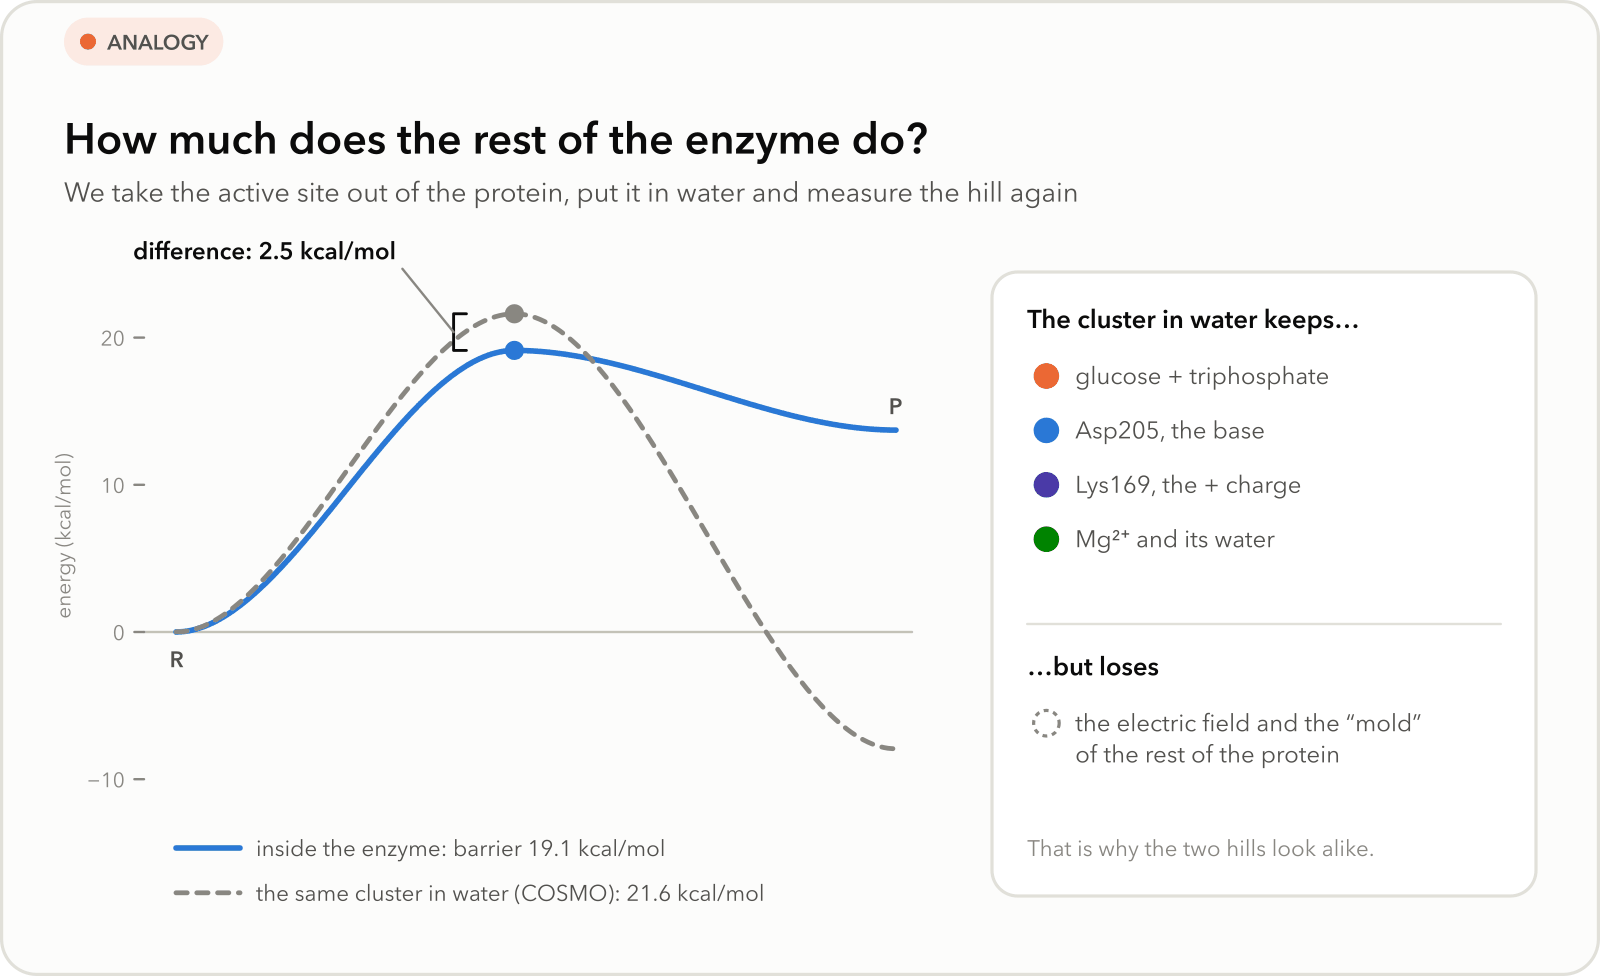

---

### 🧮 The equation in words

**Why do we want an equation?** To put a number on the "stadium's contribution":

$$\text{effect of the rest of the protein} \;=\; \text{barrier inside the enzyme} \;-\; \text{barrier of the cluster in water}$$

$$\Delta\Delta E^{\ddagger}_{\text{environment}} \;=\; {\color{#2a78d6}{\Delta E^{\ddagger}_{\text{enzyme}}}} \;-\; {\color{#898781}{\Delta E^{\ddagger}_{\text{water}}}} \;=\; 19.1 - 21.6 \;\approx\; -2.5\ \text{kcal/mol}$$

A **negative** number means the protein environment **lowers** the hill. With the golden rule
(1.36 kcal/mol = ×10), 2.5 kcal/mol means the reaction runs about **70 times** faster inside the
enzyme than in the isolated cluster.

---

### 🧰 The tools: MOPAC's native methods

Outside the enzyme there is no external potential to "freeze", so here we do use MOPAC's native
transition-state finders, with the names under which the Leonardo suite orchestrates them:

| Name in Leonardo | MOPAC keyword | What it does | In the mountain-pass analogy |
|---|---|---|---|
| QST2 | `SADDLE` | Searches for the TS starting from reactant and product (two end points) | walking from both valleys until you meet |
| QST3 / TS | `TS` | Refines the saddle point by following the mode of negative curvature | pinning down the exact position of the pass |
| Validation | `FORCETS` | Frequencies over the free coordinates: there must be one imaginary | checking that only one direction goes down |
| Path | `IRC=1*` | Follows the intrinsic reaction coordinate in both directions | walking down from the pass into both valleys |

A practical detail: `SADDLE` gives an *estimate* of the TS that has to be refined. Here the
refinement was done with the dimer method and then with MOPAC's `TS` keyword, which reached the
same saddle point.

---

### 🔬 The real data

In [ ]:
# @title 💧 The active site in water: MOPAC results
agua = res["etapas"]["agua"]
display(viz.tarjetas(
    [("1 · SADDLE (QST2)", f"{agua['barrera_saddle_qst2_kcal']:.1f}", "kcal/mol", f"first TS estimate, ξ = {agua['saddle_xi']:+.2f} Å", "gris"),
     ("2 · Refined TS", f"{agua['barrera_kcal']:.1f}", "kcal/mol", textos.t(agua["metodo_ts"]), "naranja"),
     ("TS geometry", f"{agua['ts_d_PG_O6']:.2f} / {agua['ts_d_PG_O3B']:.2f}", "Å",
      f"Pγ···O6 / Pγ···O3β; O6–H is still {agua['ts_d_O6_H']:.2f} Å", "azul"),
     ("Reaction ΔE", f"{agua['dE_reaccion']:+.1f}", "kcal/mol", "in water the reaction is downhill", "agua")],
    titulo="The same reaction, outside the enzyme (PM7 + COSMO implicit water)"))
conjuntos = [("3 · FORCETS (MOPAC)", agua["frecuencias_mas_bajas"])]
if "frecuencias_ase_mas_bajas" in agua:
    conjuntos.append(("Finer Hessian (ASE)", agua["frecuencias_ase_mas_bajas"]))
fig = viz.plot_frequencies(conjuntos, title="Look at the magnitude, don't just count the imaginary ones",
                           subtitle="Grey: noise from the solvent cavity. Orange: motions that \"fall\". The finer Hessian leaves only one: the reaction")
n_f = max(len(f) for _, f in conjuntos)
tabla_f = pd.DataFrame({"mode": np.arange(1, n_f + 1),
                        **{nombre.split(" (")[0].replace("3 · ", ""): np.r_[np.asarray(f, float), [np.nan] * (n_f - len(f))]
                           for nombre, f in conjuntos}})
viz.mostrar(fig, viz.datos(
    tabla_f, "the lowest frequencies of the TS in water",
    "Each column is one Hessian calculation; each row, one of the slowest modes sorted from lowest to highest. "
    "Values between −40 and +40 cm⁻¹ are numerical noise from the solvent cavity.",
    y=list(tabla_f.columns[1:]), unidades={c: "cm⁻¹" for c in tabla_f.columns[1:]}, formatos={c: "{:.1f}" for c in tabla_f.columns[1:]},
    resaltar={0: ("the reaction", "naranja")}))

**A lesson about validation.** The `FORCETS` Hessian on the COSMO surface shows several small
"imaginary" frequencies (|ν| < 40 cm⁻¹): they are numerical noise from the solvent cavity, not
real motions; that is why it pays to look at the *magnitude* of the frequencies and not just count
them. The Hessian from finer finite differences (ASE) leaves a single clear mode (≈ −160 cm⁻¹, the
jumping phosphorus) and a residual −37 cm⁻¹ attributable to the cavity. MOPAC's `IRC` aborted
because of an internal program error on this solvated surface (that happens in practice too); the
path was obtained with the same descent from the TS as in section 9.

In [ ]:
# @title 📈 The reaction path in water
try:
    cam_agua = datos.csv("qmmm/agua_camino_descenso.csv")
    fig = viz.plot_energy_profile(cam_agua["xi"].values, cam_agua["energia_kcal"].values - agua["E_reactivo"], relative=False,
                                  xlabel="ξ (Å)", smooth=False, sort=False, ts_index=int(np.argmax(cam_agua["energia_kcal"].values)),
                                  annotate_states=True, annotate_reaction=True, state_names=("reactant", "TS", "product"),
                                  color=viz.PALETTE[6],
                                  title=f"In water the hill is {agua['barrera_kcal']:.1f} kcal/mol high",
                                  subtitle="Descent path from the refined TS; energies relative to the reactant in water")
    e_rel = cam_agua["energia_kcal"].values - agua["E_reactivo"]
    viz.mostrar(fig, viz.datos(
        pd.DataFrame({"step": cam_agua["cuadro"], "ξ": cam_agua["xi"], "E": e_rel}), "the path in water",
        "Each row is a step of the descent from the TS in water, in the order of the path.",
        x="ξ", y="E", calculadas={"E": "energy of the step − energy of the reactant in water"},
        unidades={"ξ": "Å", "E": "kcal/mol"}, formatos={"ξ": "{:+.2f}", "E": "{:.1f}"},
        resaltar={int(np.argmax(e_rel)): ("TS", "naranja")}, barra="E"))
except FileNotFoundError:
    display(viz.mensaje("Path in water not available.", "ojo"))

The same movie as in section 8, but now **without the rest of the protein**: only the active site
in water. Compare the height of the hill in the plot with the one inside the enzyme.

In [ ]:
# @title 🎬 The reaction in water, synchronized with its energy
visor3d.pelicula_reaccion("agua")

In [ ]:
# @title ⚖️ Inside the enzyme versus outside it
con = [("E·S", 0.0), ("TS", ts["barrera_kcal"]), ("E·P", P["dE_reaccion_kcal"])]
sin = [("R", 0.0), ("TS", agua["barrera_kcal"]), ("P", agua["dE_reaccion"])]
efecto = ts["barrera_kcal"] - agua["barrera_kcal"]
fig = viz.plot_energy_levels(con, compare=sin, ts_indices=[1], label="inside the enzyme", compare_label="active site in water",
                             title=f"The rest of the protein lowers the hill by {abs(efecto):.1f} kcal/mol",
                             subtitle="Blue/orange: inside the enzyme. Grey: the same active site in water")
viz.mostrar(fig, viz.tarjetas(
    [("Effect of the protein environment", f"{efecto:+.1f}", "kcal/mol", "barrier in the enzyme − barrier in water", "azul"),
     ("In rate", f"× {10 ** (-efecto / 1.364):.0f}", "", "every 1.36 kcal/mol is a factor of 10", "naranja")]),
    viz.datos(pd.DataFrame({"state": ["reactant", "transition state", "product"],
                            "in the enzyme": [e for _, e in con], "in water": [e for _, e in sin],
                            "difference": [a - b for (_, a), (_, b) in zip(con, sin)]}),
              "the two diagrams",
              "The heights of the two diagrams, side by side. The transition-state row is the one that decides the rate.",
              y=["in the enzyme", "in water"], calculadas={"difference": "in the enzyme − in water"},
              unidades={"in the enzyme": "kcal/mol", "in water": "kcal/mol", "difference": "kcal/mol"},
              formatos={"in the enzyme": "{:.1f}", "in water": "{:.1f}", "difference": "{:+.1f}"},
              resaltar={1: ("TS", "naranja")}))

**How to read this comparison.** The cluster "in water" is **not** the uncatalyzed reaction: it
still contains the catalytic base (Asp205), the positive charge of Lys169 and the Mg²⁺, that is,
the essential chemical machinery. That is why the two hills look alike: the difference (a few
kcal/mol) measures what the *rest* of the protein contributes, mainly its electric field and the
fact that it keeps the reactants aligned. The true reaction without enzyme, glucose and ATP alone
in water, is extraordinarily slow: the spontaneous hydrolysis of a phosphate dianion has a
half-life of ~10¹² years (Lad, Williams and Wolfenden, 2003; ΔG‡ ≈ 44 kcal/mol), because no base,
no cation and no electric field are there to help. Between that reaction and k<sub>cat</sub> ≈ 60 s⁻¹
there is a factor of ~10²¹: that is the real size of catalysis.

> ✅ **Takeaway.** The active site alone, in water, already has almost all the chemical machinery
> (Asp205, Lys169, Mg²⁺), which is why its barrier (21.6) resembles the enzyme's (19.1). The rest
> of the protein contributes about 2.5 kcal/mol more (a factor of ~70). Full catalysis, compared
> with the reaction with no help at all, is ~10²¹-fold.

## 12. From the barrier to *k*<sub>cat</sub>

> 🎯 **In this section** you will turn the calculated barriers into a turnover number
> *k*<sub>cat</sub> and compare it, honestly, with experiment and with another published
> calculation.

---

### 💡 The analogy: a ruler with two scales

A thermometer can have two scales, °C and °F: the same measurement read in two ways. The Eyring
equation is a ruler like that: on top you read the **height of the hill**, underneath the
**reactions per second**. From the height of the hill we estimate how many times per second the
enzyme completes the reaction: that number is **k**<sub>cat</sub>, the "turnover number". We compare
it with the value measured in the lab and with another published QM/MM calculation.

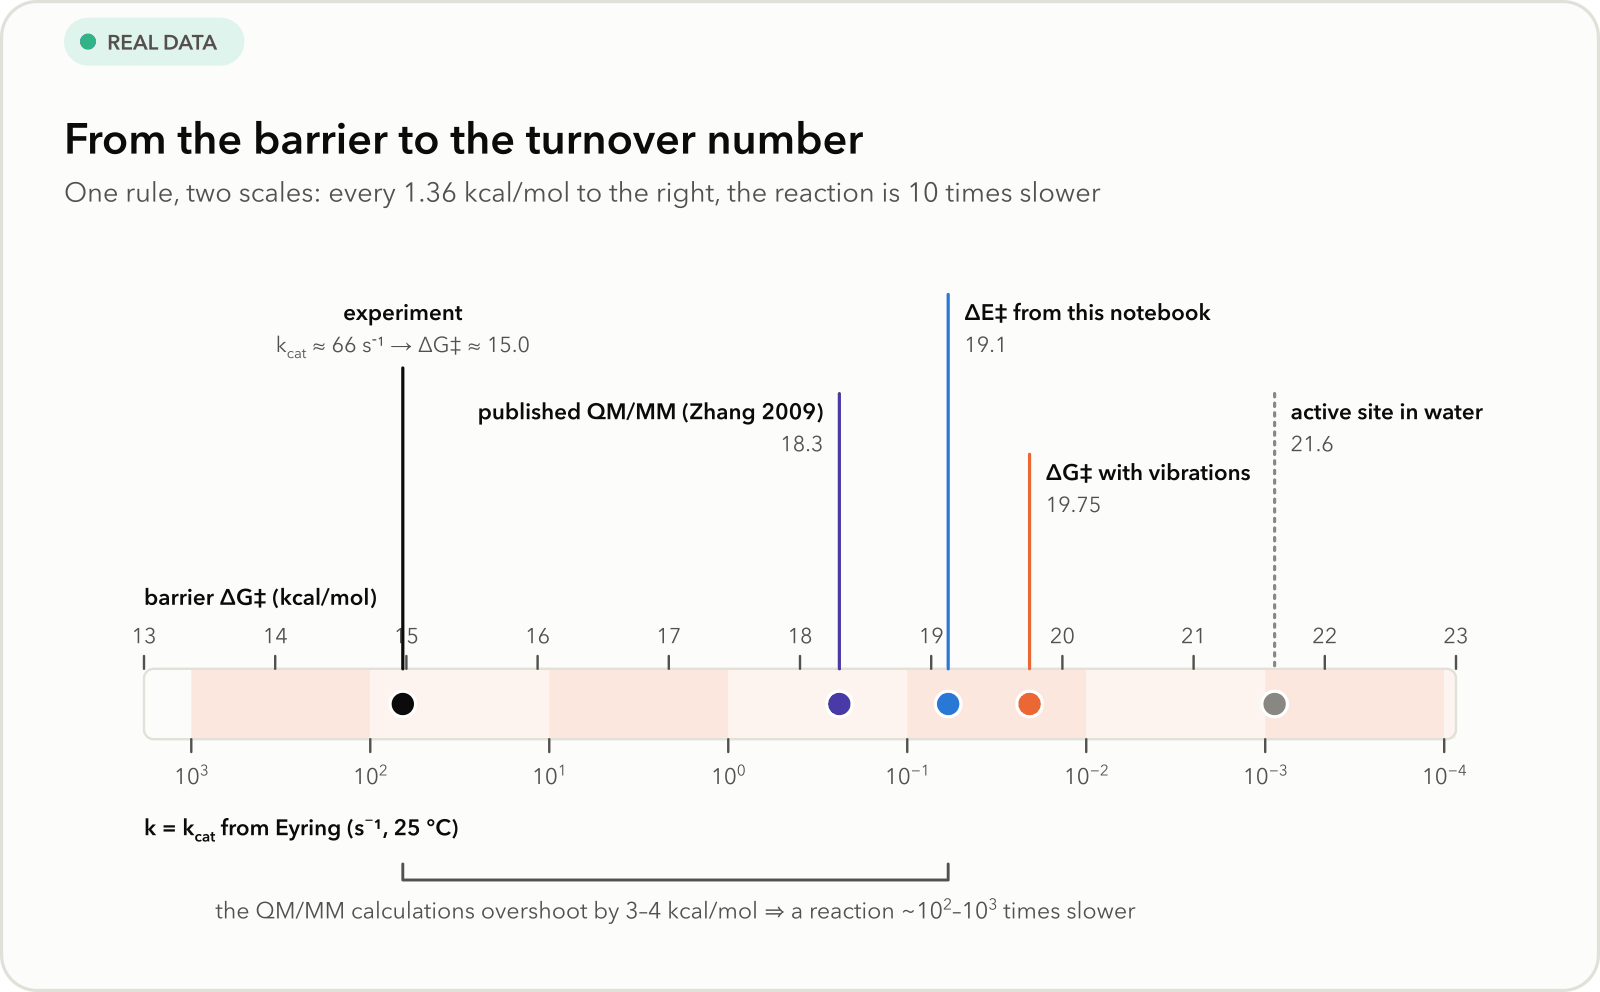

---

### 🧮 The equation in words

It is the same equation as in section 6, *attempts × probability of success*, used in both
directions:

* **from simulation to experiment**: given the calculated barrier, how many reactions per second does it predict?
* **from experiment to barrier**: given the measured k<sub>cat</sub>, what hill height does it imply?

---

### 📐 The full equation, term by term

$$k_{\mathrm{cat}} \;=\; {\color{#2a78d6}{\frac{k_BT}{h}}}\;{\color{#eb6834}{e^{-\Delta G^{\ddagger}/RT}}}
\qquad\Longleftrightarrow\qquad
\Delta G^{\ddagger} \;=\; RT\,\ln\!\frac{k_BT}{h\,k_{\mathrm{cat}}}$$

| Term | What it is | In the analogy | Value |
|---|---|---|---|
| $k_{\mathrm{cat}}$ | reactions per second per enzyme molecule | the bottom scale | measured: ≈ 62–66 s⁻¹ |
| ${\color{#2a78d6}{k_BT/h}}$ | attempts per second | — | 6.2 × 10¹² s⁻¹ at 25 °C |
| ${\color{#eb6834}{\exp(-\Delta G^{\ddagger}/RT)}}$ | probability of crossing the summit | — | tiny |
| $\Delta G^{\ddagger}$ | height of the hill | the top scale | experiment: ≈ 15 kcal/mol |

---

### 🎛️ What if… (or why we must be honest)

Our ΔG‡ comes from a semiempirical method (PM7), a frozen environment and a harmonic
approximation. An error of 1.4 kcal/mol is already a factor of 10 in rate. That is why we compare
orders of magnitude and, above all, *trends*, not decimals.

| If the calculated barrier is off by… | k<sub>cat</sub> is off by a factor of… |
|---|---|
| 0.5 kcal/mol | ~2 |
| 1.4 kcal/mol | ~10 |
| 4 kcal/mol | ~850 |

> ⚠️ **Watch out.** A calculated barrier "almost equal" to the experimental one can give a
> k<sub>cat</sub> ten or a hundred times different. Always compare on the energy scale **and** on
> the rate scale.

---

### 🔬 The real data

In [ ]:
# @title 🏁 Our barrier versus experiment
T = 298.15
kcat_exp = valor("kcat_s", 60.0)
dG_qmmm = termo.get(T_ref, {}).get("dG_kcal", ts["barrera_kcal"])
filas = [("ΔE‡ PM7, one conformation (this notebook)", ts["barrera_kcal"], viz.COLORS["reactivo"]),
         ("ΔG‡ PM7 + harmonic thermochemistry (this notebook)", dG_qmmm, viz.COLORS["ts"])]
try:
    if len(ok) > 1:
        filas.append(("ΔE‡ averaged over MD snapshots (this notebook)", media, viz.COLORS["reactivo"]))
except NameError:
    pass
filas.append(("published QM/MM ΔE‡, Zhang et al. 2009", valor("qmmm_barrier_literature_kcal", np.nan), viz.PALETTE[6]))
filas.append(("active site in water, COSMO (this notebook)", agua["barrera_kcal"], viz.INK_MUTED))
dG_exp = cin.barrier_from_rate(kcat_exp, T)
etiquetas = {"ΔE‡ PM7, one conformation (this notebook)": "ΔE‡ in the enzyme (PM7)",
             "ΔG‡ PM7 + harmonic thermochemistry (this notebook)": "ΔG‡ with vibrations",
             "ΔE‡ averaged over MD snapshots (this notebook)": "average ΔE‡ (MD)",
             "published QM/MM ΔE‡, Zhang et al. 2009": "Zhang et al. 2009 (QM/MM)",
             "active site in water, COSMO (this notebook)": "active site in water"}
fig = viz.plot_estimates([(etiquetas.get(n, n), b, c) for n, b, c in filas], reference=dG_exp,
                         reference_label=f"experiment (k_cat ≈ {kcat_exp:.0f} s⁻¹)", rate_fn=lambda b: cin.eyring_rate(b, T),
                         title="The QM/MM calculations sit 3–4 kcal/mol above experiment",
                         subtitle="Each point is a barrier estimate; on the right, the rate implied by the Eyring equation")
filas.append(("experiment: ΔG‡ implied by k_cat", dG_exp, None))
tabla = pd.DataFrame([(n, b, viz._sci(cin.eyring_rate(b, T))) for n, b, _ in filas], columns=["estimate", "barrier (kcal/mol)", "k (s⁻¹) from Eyring"])
viz.mostrar(fig, viz.tabla(tabla, formatos={"barrier (kcal/mol)": "{:.1f}"}, titulo="The same estimates, in numbers",
                           nota=f"Experimental k_cat ≈ {kcat_exp:.0f} s⁻¹ ({ref['kcat_s']['source']})."),
            viz.mensaje("Our barrier and that of Zhang et al. (18.3 kcal/mol, a different program and a different QM/MM partition) "
                        "agree within 1 kcal/mol; both overestimate the experimental one (≈15) by 3-4 kcal/mol, that is, a factor "
                        "of ~10²-10³ in k. That is what to expect from a semiempirical method with a fixed environment.", "idea"))

> ✅ **Takeaway.** Eyring turns barriers into rates in both directions. Our barrier and that of
> Zhang et al. agree with each other within 1 kcal/mol and sit 3–4 kcal/mol above the one implied
> by experiment (≈ 15): the simulation gets the mechanism and the order of magnitude of the hill
> right, not the decimals of *k*<sub>cat</sub>.

## 13. Michaelis–Menten from the mechanism

> 🎯 **In this section** you will see why an enzyme's rate **saturates** when there is a lot of
> substrate, where the Michaelis–Menten equation comes from (no need to take it on faith: we will
> derive it and simulate it) and how K<sub>M</sub>, V<sub>max</sub>, k<sub>cat</sub> and
> k<sub>cat</sub>/K<sub>M</sub> are obtained from data.

---

### 💡 The analogy: the supermarket checkout lane

A supermarket checkout lane (the **enzyme**) serves customers (the **substrate**). With few
customers, each one who arrives is served right away: the lane's "rate" grows with the number of
customers. With many customers a queue forms: the cashier works flat out and it makes no difference
if more arrive. The rate **saturates**.

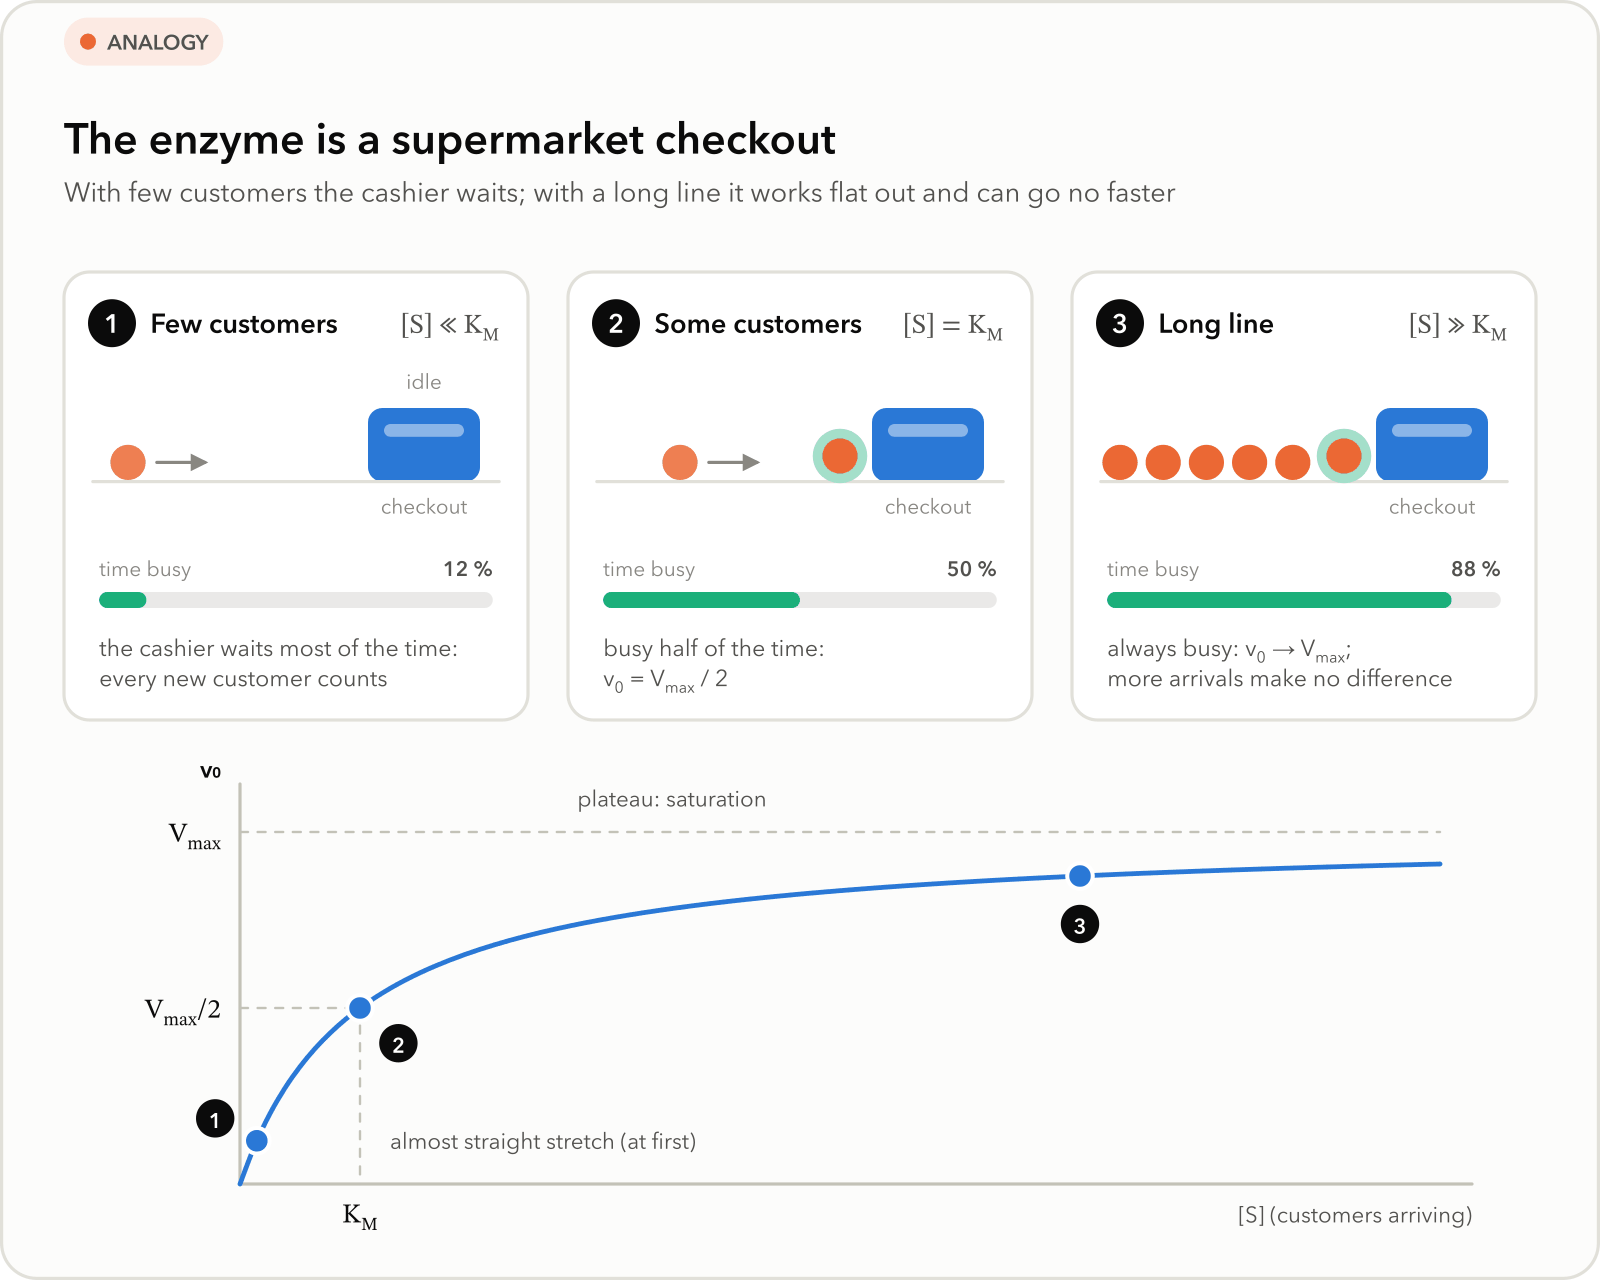

That behavior has the shape of a hyperbola and is described by two numbers:

* **V**<sub>max</sub>: the rate with the lane always busy (all the enzyme in the ES form).
* **K**<sub>M</sub>: the customer concentration at which the lane works at **half** its maximum.
  A small K<sub>M</sub> means the enzyme "fills up" with little substrate.

---

### 🧮 The equation in words

**Why do we want an equation?** To predict how much product comes out per second for any amount of
substrate, and to summarize a whole enzyme in two numbers that can be compared across labs,
mutants and drugs.

The idea is simple: the rate is the **maximum rate** multiplied by the **fraction of time the lane
is busy**:

$$\text{rate} \;=\; \underbrace{\text{rate with the lane always busy}}_{V_{\max}} \;\times\; \underbrace{\text{fraction of time busy}}_{\text{from 0 to 1}}$$

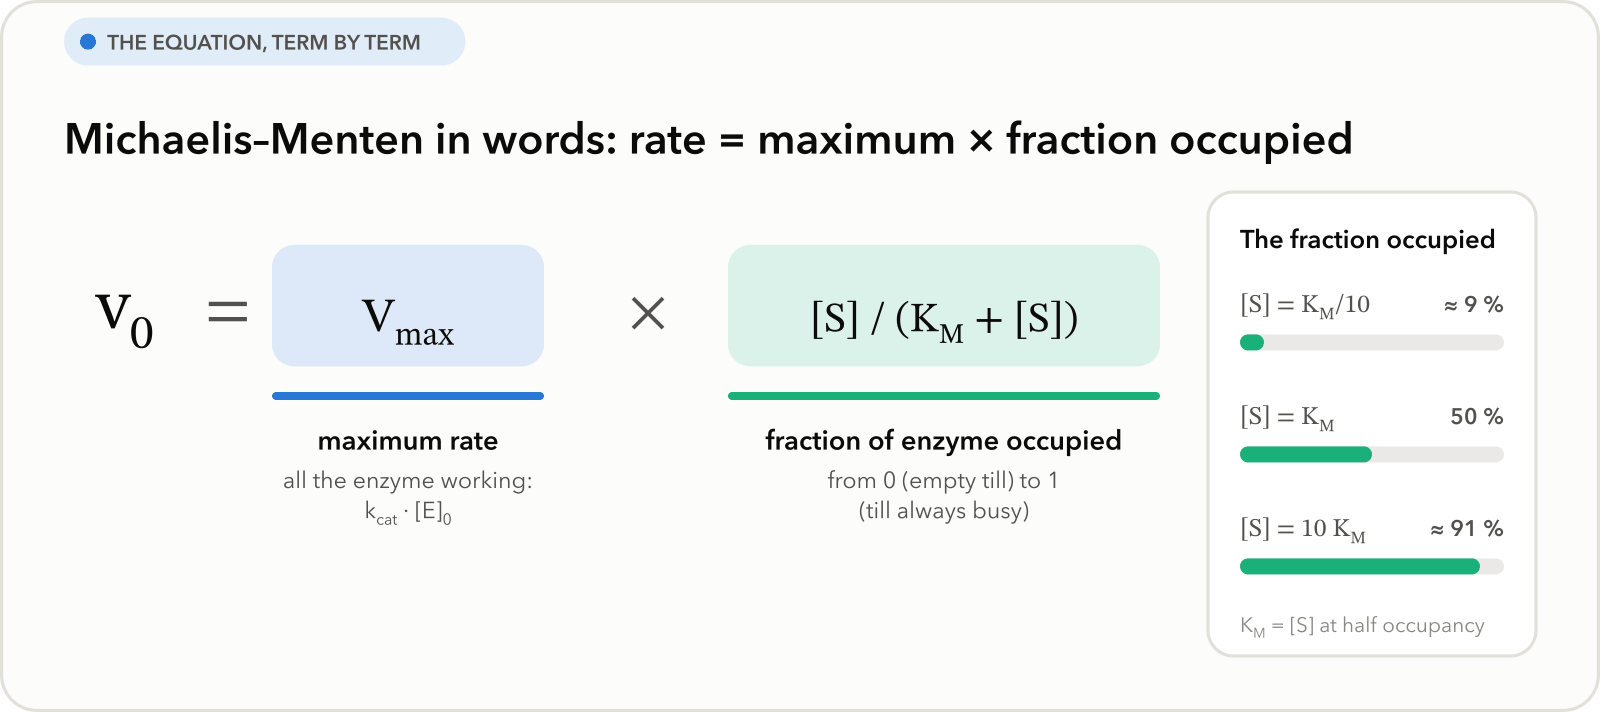

The occupied fraction, $[\mathrm{S}]/(K_M + [\mathrm{S}])$, is 0 without substrate, 1/2 when
$[\mathrm{S}] = K_M$, and approaches 1 (without ever reaching it) when there is a huge amount. That's all.

---

### 📐 The full equation, term by term

**The mechanism behind it (Michaelis and Menten 1913; Briggs and Haldane 1925):**

$$\mathrm{E + S \;\underset{k_{-1}}{\overset{k_1}{\rightleftharpoons}}\; ES \;\overset{k_2}{\longrightarrow}\; E + P}$$

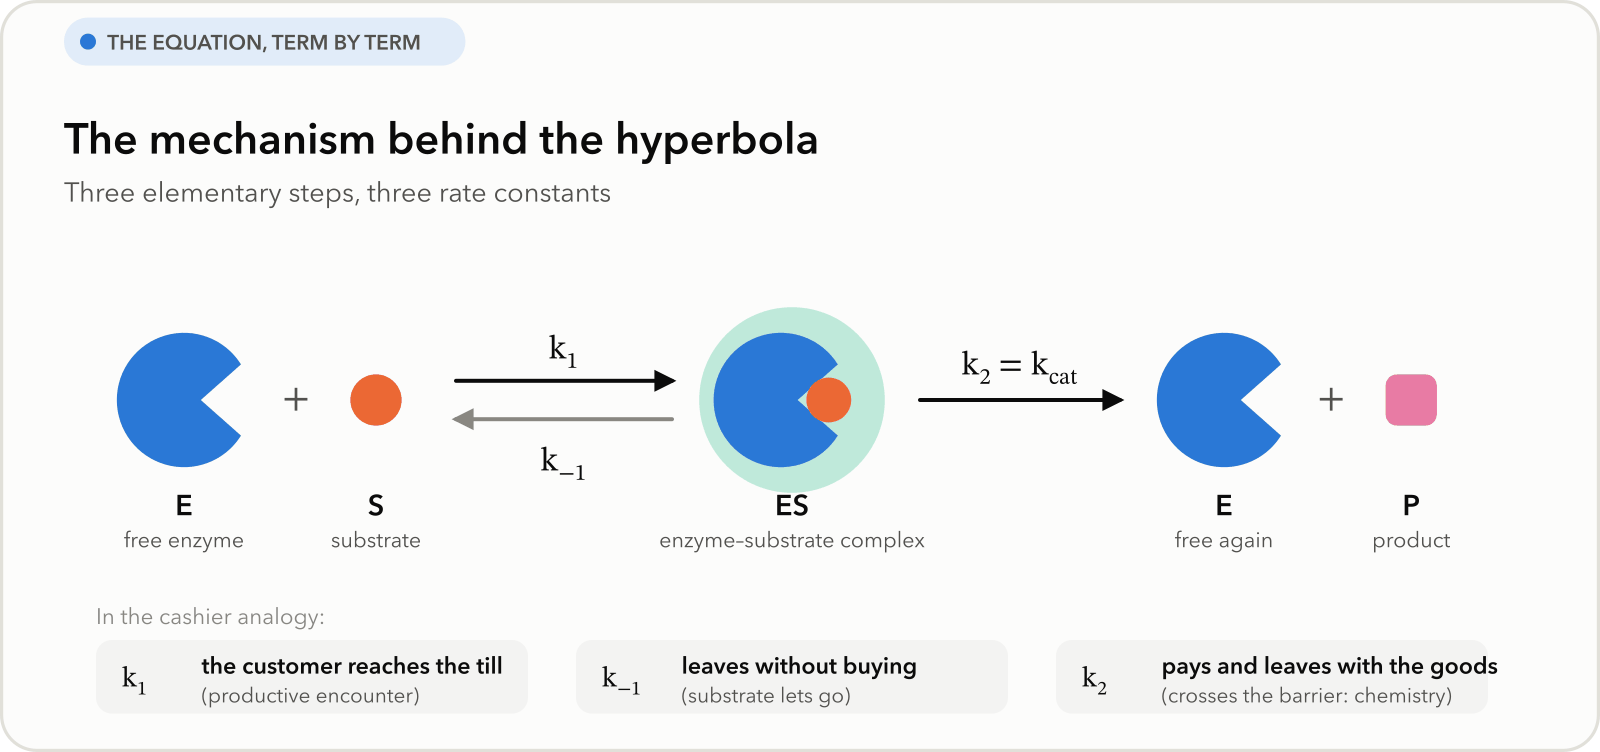

| Constant | What it describes | In the analogy | Units |
|---|---|---|---|
| $k_1$ | the substrate enters the active site (productive collision) | the customer reaches the lane | M⁻¹ s⁻¹ |
| $k_{-1}$ | the substrate is released without reacting | leaves without buying | s⁻¹ |
| $k_2$ (= k<sub>cat</sub>) | the ES complex crosses the barrier and releases the product | pays and leaves with the purchase | s⁻¹ |

**The derivation, step by step.** (Follow each line: it is just algebra.)

1. Rate of product formation: $v_0 = k_2[\mathrm{ES}]$ — *customers paying per second = cashier's
   speed × customers being served*.
2. **Steady-state assumption**: ES forms as fast as it is consumed, so its concentration barely
   changes: $k_1[\mathrm{E}][\mathrm{S}] = (k_{-1} + k_2)[\mathrm{ES}]$ — *as many customers reach the
   lane as leave it (buying or not)*.
3. The total enzyme is shared out: $[\mathrm{E}]_0 = [\mathrm{E}] + [\mathrm{ES}]$, so $[\mathrm{E}] = [\mathrm{E}]_0 - [\mathrm{ES}]$ —
   *each lane is either free or busy*.
4. Substituting (3) into (2) and solving: $[\mathrm{ES}] = \dfrac{[\mathrm{E}]_0[\mathrm{S}]}{K_M + [\mathrm{S}]}$ with
   $K_M \equiv \dfrac{k_{-1}+k_2}{k_1}$.
5. Plugging (4) into (1):

$$\boxed{v_0 \;=\; {\color{#2a78d6}{V_{\max}}}\;\times\;{\color{#1baf7a}{\frac{[\mathrm{S}]}{K_M + [\mathrm{S}]}}}} \qquad\text{with}\qquad {\color{#2a78d6}{V_{\max} = k_2[\mathrm{E}]_0}}$$

The **blue** factor is the maximum rate; the **green** one, the fraction of enzyme occupied (the
same colors as in the drawing).

| Term | What it is | In the analogy |
|---|---|---|
| $v_0$ | initial rate of product formation | customers leaving with their purchase per second |
| ${\color{#2a78d6}{V_{\max}}}$ | rate with all the enzyme occupied: k<sub>cat</sub>·[E]<sub>0</sub> | every lane serving nonstop |
| [S] | substrate concentration | how many customers are in the store |
| $K_M$ | [S] at which the enzyme is half occupied: (k<sub>−1</sub> + k<sub>2</sub>)/k<sub>1</sub> | how many customers it takes for the lane to be busy half the time |

> ⚠️ **Watch out.** $K_M$ equals the dissociation constant $K_d = k_{-1}/k_1$ only when
> $k_2 \ll k_{-1}$ (the customer leaves without buying far more often than they buy). In general
> K<sub>M</sub> is not a pure "affinity".

---

### 🎛️ What if…

| If… | then… | because… |
|---|---|---|
| [S] ≪ K<sub>M</sub> | v₀ ≈ (V<sub>max</sub>/K<sub>M</sub>)·[S]: **a straight line** | the enzyme is almost empty and every substrate molecule counts; slope = (k<sub>cat</sub>/K<sub>M</sub>)·[E]<sub>0</sub> |
| [S] = K<sub>M</sub> | v₀ = V<sub>max</sub>/2 | the lane is busy half the time |
| [S] ≫ K<sub>M</sub> | v₀ → V<sub>max</sub>: **saturation** | there is always a queue: more customers don't speed up the cashier |
| **K<sub>M</sub> goes up** | the curve stretches to the right | the enzyme "grabs" the substrate less well or releases it faster: more is needed for the same rate |
| **V<sub>max</sub> goes up** | the whole curve scales upward | more enzyme, or a faster enzyme |

---

### 🔬 Let's simulate the mechanism

Instead of taking the formula on faith, **let's solve the mechanism numerically** and watch the
hyperbola appear on its own. First, the movie of the concentrations:

In [ ]:
# @title 🎛️ The mechanism in action: E + S ⇌ ES → E + P
# 🎛️ Move k1, k-1, k2, [E]0 and [S]0 and watch the pre-steady state and product formation
interactivo.explorar_mecanismo()

In [ ]:
# @title 🔁 From the simulation to the hyperbola
k2 = 60  # @param {type:"slider", min:6, max:600, step:6}
# k2 = k_cat (s⁻¹); try 6 and 600 (exercise 3)
E0, k1, k_1 = 0.05, 1.0, 50.0                   # µM, µM⁻¹s⁻¹, s⁻¹
S = np.array([5, 10, 20, 40, 80, 150, 300, 600, 1200, 2400])       # µM
v0_sim = cin.initial_rates_from_simulation(E0, S, k1, k_1, k2, t_window=(0.01, 0.1))
ajuste = cin.fit_michaelis_menten(S, v0_sim)
teoria = cin.steady_state_parameters(k1, k_1, k2)
fig = viz.plot_initial_rates_from_ode(S, v0_sim, fit=ajuste)
v0_mm = cin.michaelis_menten(S, ajuste["vmax"], ajuste["km"])
tabla_sim = pd.DataFrame({"[S]₀": S, "simulated v₀": v0_sim, "v₀ from the hyperbola": v0_mm,
                          "difference": v0_sim - v0_mm, "occupied fraction": S / (ajuste["km"] + S)})
datos_sim = viz.datos(
    tabla_sim, "from the simulation to the hyperbola",
    "Each row is a complete simulation of the mechanism with a different [S]₀: v₀ is the initial slope of the "
    "product curve. The line in the plot is the hyperbola that best passes through these points.",
    x="[S]₀", y="simulated v₀",
    calculadas={"v₀ from the hyperbola": "V_max·[S]₀ / (K_M + [S]₀), with V_max and K_M from the fit",
                "difference": "simulated v₀ − v₀ from the hyperbola",
                "occupied fraction": "[S]₀ / (K_M + [S]₀)"},
    unidades={"[S]₀": "µM", "simulated v₀": "µM/s", "v₀ from the hyperbola": "µM/s", "difference": "µM/s"},
    formatos={"[S]₀": "{:g}", "simulated v₀": "{:.4f}", "v₀ from the hyperbola": "{:.4f}", "difference": "{:+.1e}",
              "occupied fraction": "{:.0%}"},
    resaltar={int(np.argmin(np.abs(S - ajuste["km"]))): ("≈ K_M", "naranja")}, barra="simulated v₀")
viz.mostrar(fig, datos_sim, viz.tarjetas([
    ("K_M from the fit", f"{ajuste['km']:.1f}", "µM", "fitting the hyperbola to the simulated v₀", "azul"),
    ("K_M from the formula", f"{teoria['km']:.1f}", "µM", "(k₋₁ + k₂)/k₁", "agua"),
    ("V_max from the fit", f"{ajuste['vmax']:.3f}", "µM/s", "plateau of the curve", "azul"),
    ("V_max from the formula", f"{k2 * E0:.3f}", "µM/s", "k₂·[E]₀", "agua"),
], titulo="Do the simulation and the paper derivation agree?",
   nota="If the pairs match, the derivation works: the hyperbola comes out of the mechanism on its own."))

In [ ]:
# @title 🎛️ The hyperbola: move V_max and K_M
# 🎛️ The hyperbola: move Vmax and Km
interactivo.explorar_michaelis_menten()

### 🔬 The real data: three numbers that come out of the curve

| Constant | How it is obtained | What it measures | In the analogy | Glucokinase (literature) |
|---|---|---|---|---|
| **K<sub>M</sub>** (or S<sub>0.5</sub>) | fit of v₀ versus [S] | apparent affinity; at what [S] the enzyme is half full | customers needed for half occupancy | ≈ 7.7 mM glucose |
| **k<sub>cat</sub>** = V<sub>max</sub>/[E]<sub>0</sub> | V<sub>max</sub> from the fit ÷ enzyme concentration | turnover: reactions per second per enzyme molecule | customers per second that **one** lane serves flat out | ≈ 62–66 s⁻¹ |
| **k<sub>cat</sub>/K<sub>M</sub>** | ratio of the two above | efficiency at low [S]; physical limit ≈ 10⁸–10⁹ M⁻¹s⁻¹ (diffusion) | how well the lane makes use of an almost empty store | ≈ 8 × 10³ M⁻¹s⁻¹ |

Now an "experiment": data simulated with the literature parameters and 4 % noise, treated the way a
biochemist would: a **nonlinear fit** and, for comparison, the three classic linearizations.

> ⚠️ **Watch out.** **Lineweaver–Burk** (1/v₀ versus 1/[S]) amplifies the error of the
> low-concentration points: today it is used to *visualize*, and the nonlinear fit to *quantify*.

In [ ]:
# @title 🔬 A simulated experiment and its fit
rng = np.random.default_rng(7)
S_mM = np.array([0.5, 1, 2, 3, 5, 7.5, 10, 15, 20, 30, 40, 60])
E0_uM = 0.2                                     # enzyme in the tube (µM)
Km_real = valor("s_half_mm", 7.5)               # we treat the enzyme as hyperbolic in this exercise
Vmax_real = valor("kcat_s", 60.0) * E0_uM       # µM/s
v_obs = cin.michaelis_menten(S_mM, Vmax_real, Km_real) * (1 + 0.04 * rng.standard_normal(S_mM.size))
aj = cin.fit_michaelis_menten(S_mM, v_obs)
fig = viz.plot_michaelis_menten(S_mM, v_obs, fit=aj, title=f"The enzyme reaches half its maximum at {aj['km']:.1f} mM substrate",
                                subtitle="Data simulated with 4 % noise (points) and nonlinear Michaelis–Menten fit (line)")
kc = cin.kcat_km_from_fit(aj, E0_uM)
v_ajuste = cin.michaelis_menten(S_mM, aj["vmax"], aj["km"])
tabla_exp = pd.DataFrame({"[S]": S_mM, "measured v₀": v_obs, "fitted v₀": v_ajuste, "residual": v_obs - v_ajuste,
                          "occupied fraction": S_mM / (aj["km"] + S_mM)})
datos_exp = viz.datos(
    tabla_exp, "the simulated experiment",
    "Each row is a test tube: a glucose concentration and the measured initial rate (with 4 % noise). "
    "The nonlinear fit looks for the V_max and K_M that make the residuals as small as possible.",
    x="[S]", y="measured v₀",
    calculadas={"fitted v₀": "V_max·[S] / (K_M + [S]), with V_max and K_M from the fit",
                "residual": "measured v₀ − fitted v₀ (what the curve does not explain: the noise)",
                "occupied fraction": "[S] / (K_M + [S]) = fitted v₀ / V_max"},
    unidades={"[S]": "mM", "measured v₀": "µM/s", "fitted v₀": "µM/s", "residual": "µM/s"},
    formatos={"[S]": "{:g}", "measured v₀": "{:.2f}", "fitted v₀": "{:.2f}", "residual": "{:+.2f}", "occupied fraction": "{:.0%}"},
    resaltar={int(np.argmin(np.abs(S_mM - aj["km"]))): ("≈ K_M", "naranja")}, barra="measured v₀")
viz.mostrar(fig, datos_exp, viz.tarjetas([
    ("V_max", f"{aj['vmax']:.2f}", f"± {aj['vmax_err']:.2f} µM/s", "the plateau: all the enzyme occupied", "azul"),
    ("K_M", f"{aj['km']:.2f}", f"± {aj['km_err']:.2f} mM", f"[S] at half rate (R² = {aj['r2']:.4f})", "naranja"),
    ("k_cat = V_max/[E]₀", f"{kc['kcat']:.0f}", "s⁻¹", f"one reaction every {cin.turnover_time(kc['kcat'])*1000:.0f} ms per enzyme", "agua"),
    ("k_cat/K_M", f"{kc['kcat_over_km_molar']:.2e}", "M⁻¹s⁻¹", "efficiency when substrate is scarce", "violeta"),
], titulo="The four numbers that come out of the curve"))

In [ ]:
# @title 📐 The three classic linearizations
fig = viz.plot_linearizations(S_mM, v_obs, title="Three ways to turn the hyperbola into a straight line",
                              subtitle="The axis intercepts (gray points) give V_max and K_M; orange circles: the points that distort Lineweaver–Burk the most")
lb = cin.linear_fit(*cin.lineweaver_burk(S_mM, v_obs))
tabla_lin = pd.DataFrame({"[S]": S_mM, "v₀": v_obs, "1/[S]": 1 / S_mM, "1/v₀": 1 / v_obs,
                          "v₀/[S]": v_obs / S_mM, "[S]/v₀": S_mM / v_obs})
datos_lin = viz.datos(
    tabla_lin, "the three linearizations",
    "The same 12 tubes, transformed. Each plot uses a pair of columns: Lineweaver–Burk plots 1/v₀ versus "
    "1/[S]; Eadie–Hofstee, v₀ versus v₀/[S]; Hanes–Woolf, [S]/v₀ versus [S]. Look at the first two rows: "
    "with little glucose, 1/[S] and 1/v₀ shoot up, and those points, the noisiest ones, dominate the Lineweaver–Burk line.",
    calculadas={"1/[S]": "1 ÷ [S]  (x axis of Lineweaver–Burk)", "1/v₀": "1 ÷ v₀  (y axis of Lineweaver–Burk)",
                "v₀/[S]": "v₀ ÷ [S]  (x axis of Eadie–Hofstee; its y axis is v₀)",
                "[S]/v₀": "[S] ÷ v₀  (y axis of Hanes–Woolf; its x axis is [S])"},
    unidades={"[S]": "mM", "v₀": "µM/s", "1/[S]": "mM⁻¹", "1/v₀": "s/µM", "v₀/[S]": "µM·s⁻¹/mM", "[S]/v₀": "mM·s/µM"},
    formatos={"[S]": "{:g}", "v₀": "{:.2f}", "1/[S]": "{:.3f}", "1/v₀": "{:.3f}", "v₀/[S]": "{:.3f}", "[S]/v₀": "{:.3f}"},
    resaltar={0: ("weighs a lot in L‑B", "naranja"), 1: ("weighs a lot in L‑B", "naranja")}, barra="1/v₀")
viz.mostrar(fig, datos_lin, viz.tarjetas([
    ("V_max from Lineweaver–Burk", f"{1/lb['intercept']:.2f}", "µM/s", f"nonlinear fit: {aj['vmax']:.2f}", "gris"),
    ("K_M from Lineweaver–Burk", f"{lb['slope']/lb['intercept']:.2f}", "mM", f"nonlinear fit: {aj['km']:.2f}", "gris"),
], titulo="Lineweaver–Burk versus the nonlinear fit",
   nota="The straight lines help visualize the type of behavior; to quantify, use the nonlinear fit."))

> ✅ **Takeaway.** Rate = maximum rate × fraction of enzyme occupied. The hyperbola **emerges**
> from the mechanism E + S ⇌ ES → E + P; K<sub>M</sub> is the [S] of half occupancy,
> k<sub>cat</sub> the reactions per second of each enzyme, and k<sub>cat</sub>/K<sub>M</sub> its
> efficiency when substrate is scarce. They are measured with a nonlinear fit.

## 14. Cooperativity: glucokinase is a sensor

> 🎯 **In this section** you will see why the glucokinase curve is not a hyperbola but a
> **sigmoid**, what the Hill coefficient *n* measures, and how an enzyme with **a single site** can
> behave like a switch that decides when the pancreas releases insulin.

---

### 💡 The analogy: dimmer versus switch

A **dimmer** (hyperbola) raises the light little by little from the very start. A **threshold
switch** (sigmoid) does almost nothing up to a certain point and then turns on all at once. The
pancreas needs a switch: below ~5 mM glucose it must not release insulin, and above it, it must.
Glucokinase is that switch.

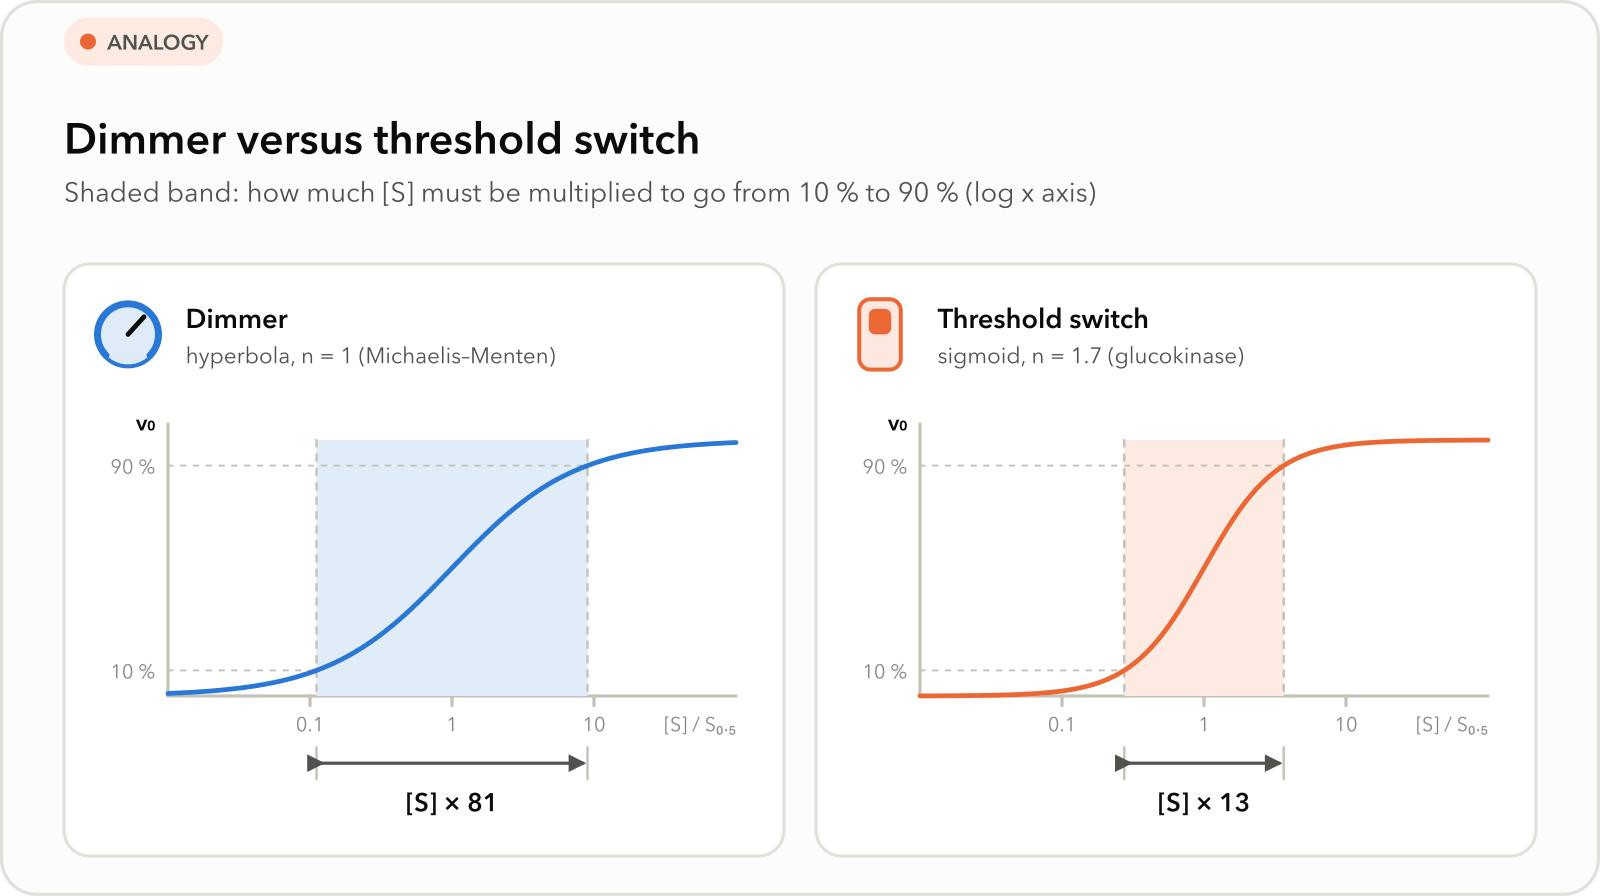

Look at the shaded bands: to go from 10 % to 90 % activity, the hyperbola needs glucose to be
multiplied **by 81**; the glucokinase sigmoid, only **by 13**.

---

### 🧮 The equation in words

**Why do we want another equation?** Because Michaelis–Menten can only draw hyperbolas, and the
glucokinase data are not a hyperbola. We need a number that says **how abrupt** the switch is.

The idea is the same as in section 13 (rate = maximum × fraction occupied), but the substrate
concentration enters **raised to a power n**:

$$\text{rate} \;=\; V_{\max} \times \frac{(\text{substrate})^{\,n}}{(\text{threshold})^{\,n} + (\text{substrate})^{\,n}}$$

Raising to *n* > 1 makes concentrations **below** the threshold count even less and those **above**
it count even more: the curve flattens at the start and steepens in the middle. That is the switch.

---

### 📐 The full equation, term by term (Hill)

$$v_0 = \frac{V_{\max}[\mathrm{S}]^{\color{#eb6834}{n}}}{{\color{#2a78d6}{S_{0.5}}}^{\,\color{#eb6834}{n}} + [\mathrm{S}]^{\color{#eb6834}{n}}}$$

| Term | What it is | In the analogy | Glucokinase |
|---|---|---|---|
| $V_{\max}$ | maximum rate | the light at full brightness | k<sub>cat</sub>·[E]<sub>0</sub> |
| ${\color{#2a78d6}{S_{0.5}}}$ | concentration at which half of V<sub>max</sub> is reached (the analog of K<sub>M</sub>) | where the switch's threshold is | ≈ 7.7 mM glucose |
| ${\color{#eb6834}{n}}$ | **Hill coefficient**: how abrupt the change is | how "suddenly" the light turns on | ≈ 1.7 |

$n = 1$ is Michaelis–Menten; $n > 1$ is positive cooperativity.

---

### 🎛️ What if…

| If… | to go from 10 % to 90 % activity, [S] must be multiplied by… | example |
|---|---|---|
| n = 1 | **81** | a Michaelis–Menten enzyme |
| n = 1.7 | **~13** | glucokinase |
| n = 4 | **3** | hemoglobin |

---

### 💡 The surprise: an enzyme with memory

Glucokinase is a **monomer** with a single glucose site: there can be no "communication between
subunits" as in hemoglobin. Its cooperativity is **kinetic**: the enzyme switches between a poorly
active (open) form and an active (closed) form at a rate **comparable to that of catalysis**
(k<sub>ex</sub> ≈ 5–100 s⁻¹ versus k<sub>cat</sub> ≈ 60 s⁻¹, Larion et al. 2012).

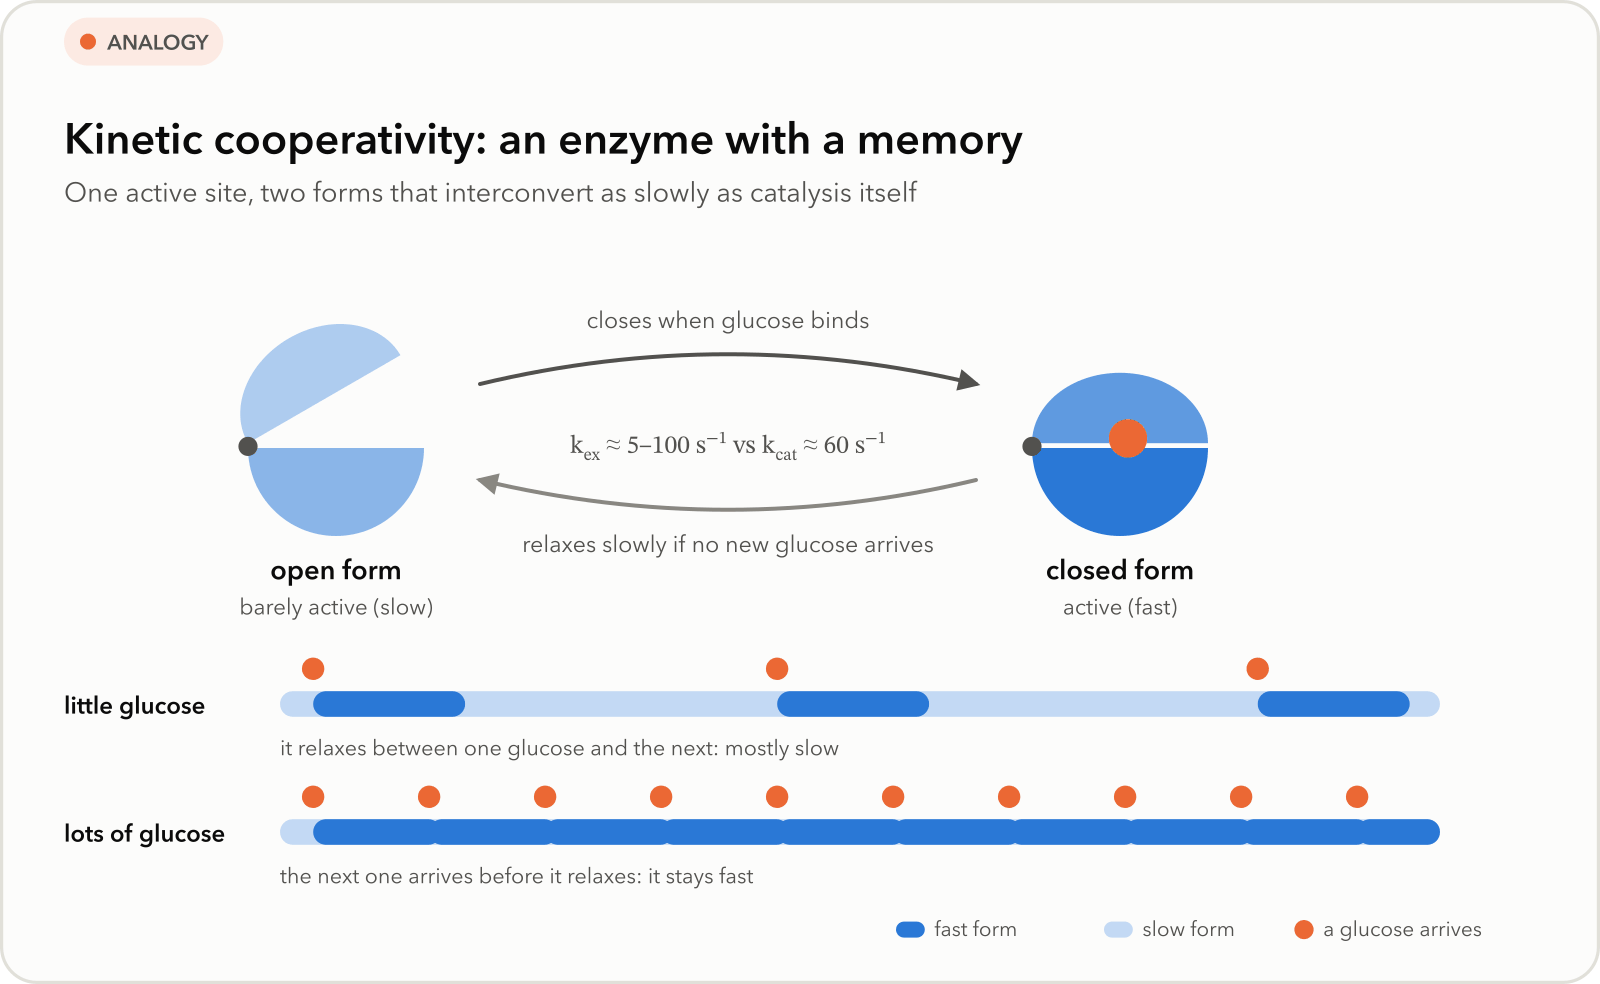

With plenty of glucose the enzyme has no time to relax to the slow form between one cycle and the
next, so it works more than it "should". This is the **mnemonic** or **slow-transition** model
(Storer and Cornish‑Bowden 1977; Neet and Ainslie; Cárdenas 1984).

> ✍️ **Think about it.** A competitive inhibitor such as N‑acetylglucosamine *suppresses*
> cooperativity (n → 1), because it keeps the site occupied and breaks the "memory". The MD
> simulations of section 5 (domains that open and close) are the molecular picture of that change.

---

### 🔬 The real data

Move *n* and S<sub>0.5</sub>, and compare with the hyperbola:

In [ ]:
# @title 🎛️ Sigmoid versus hyperbola
# 🎛️ Move n and S0.5: compare with the hyperbola and look at the 10 %–90 % window
interactivo.explorar_hill()

In [ ]:
# @title 🩸 Glucokinase in the blood glucose range
S_g = np.linspace(0.01, 30, 300)
s_half, n_h = valor("s_half_mm", 7.5), valor("hill_n", 1.7)
fig = viz.plot_hill_vs_mm(S_g, cin.michaelis_menten(S_g, 1.0, s_half), cin.hill(S_g, 1.0, s_half, n_h), n_hill=n_h, s_half=s_half,
                          ylabel="v₀ / V_max", title="In the blood range, glucokinase responds like a switch",
                          subtitle="Between 4 and 10 mM glucose (the physiological range) the sigmoid is much more sensitive than the hyperbola")
fig.set_size_inches(10.5, 5.8)
ax = fig.axes[0]
viz._kband(ax, 4, 7, "fasting blood\nglucose (4–7 mM)", color=viz._tint(viz.COLORS["ts"], 0.9), y_text=0.97)
s10, s90 = cin.substrate_at_fraction(1.0, s_half, n_h, 0.1), cin.substrate_at_fraction(1.0, s_half, n_h, 0.9)
S_tab = np.array(sorted({1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 30, round(s_half, 2)}), dtype=float)
mm_tab, hill_tab = cin.michaelis_menten(S_tab, 1.0, s_half), cin.hill(S_tab, 1.0, s_half, n_h)
tabla_hill = pd.DataFrame({"[glucose]": S_tab, "[S]/S₀.₅": S_tab / s_half, "hyperbola (n = 1)": mm_tab,
                           f"sigmoid (n = {n_h:g})": hill_tab, "difference": hill_tab - mm_tab})
resalte = {int(np.argmin(np.abs(S_tab - s_half))): ("S₀.₅", "naranja")}
resalte.update({i: ("fasting", "agua") for i, sv in enumerate(S_tab) if 4 <= sv <= 7 and i not in resalte})
datos_hill = viz.datos(
    tabla_hill, "sigmoid versus hyperbola",
    "The two curves evaluated at round glucose concentrations, as a fraction of V_max. With little glucose the "
    "sigmoid runs below (the enzyme barely responds); near S₀.₅ they cross; above it, the sigmoid rises faster.",
    x="[glucose]", y=["hyperbola (n = 1)", f"sigmoid (n = {n_h:g})"],
    calculadas={"[S]/S₀.₅": "[glucose] ÷ S₀.₅",
                "hyperbola (n = 1)": "[S] / (S₀.₅ + [S])  (Michaelis–Menten with K_M = S₀.₅)",
                f"sigmoid (n = {n_h:g})": "[S]ⁿ / (S₀.₅ⁿ + [S]ⁿ)  (Hill)",
                "difference": "sigmoid − hyperbola"},
    unidades={"[glucose]": "mM", "hyperbola (n = 1)": "v₀/V_max", f"sigmoid (n = {n_h:g})": "v₀/V_max", "difference": "v₀/V_max"},
    formatos={"[glucose]": "{:g}", "[S]/S₀.₅": "{:.2f}", "hyperbola (n = 1)": "{:.0%}", f"sigmoid (n = {n_h:g})": "{:.0%}",
              "difference": "{:+.0%}"},
    resaltar=resalte, barra=f"sigmoid (n = {n_h:g})")
viz.mostrar(fig, datos_hill, viz.tarjetas([
    ("S₀.₅", f"{s_half:g}", "mM", "glucose at half activity", "naranja"),
    ("Hill coefficient", f"{n_h:g}", "", "n > 1: sigmoid", "naranja"),
    ("from 10 % to 90 %", f"{s10:.1f} → {s90:.1f}", "mM", f"[S] × {s90/s10:.0f}", "naranja"),
    ("with n = 1", "× 81", "", "the hyperbola would need much more", "azul"),
], titulo="The glucokinase switch in numbers"))

In [ ]:
# @title 📐 Hill fit and Hill plot
# Hill fit to simulated data and Hill plot (the slope is n)
S_h = np.array([1, 2, 3, 4, 5, 6, 7.5, 9, 11, 14, 18, 25, 35, 50])
v_h = cin.hill(S_h, 10.0, s_half, n_h) * (1 + 0.03 * rng.standard_normal(S_h.size))
ajh = cin.fit_hill(S_h, v_h)
fig = viz.plot_hill_plot(S_h, v_h, ajh["vmax"], title=f"The data rise more steeply than the reference: n = {ajh['n']:.2f}",
                         subtitle="log[v/(V_max − v)] versus log[S]: the slope is the Hill coefficient; the dashed line is n = 1")
frac = v_h / (ajh["vmax"] - v_h)
tabla_hp = pd.DataFrame({"[S]": S_h, "v₀": v_h, "log₁₀[S]": np.log10(S_h), "v₀/(V_max − v₀)": frac,
                         "log₁₀[v₀/(V_max − v₀)]": np.log10(frac)})
datos_hp = viz.datos(
    tabla_hp, "the Hill plot",
    "The 14 tubes of the simulated experiment. For the Hill plot both columns are transformed: the x axis is "
    "log₁₀[S] and the y axis is log₁₀[v₀/(V_max − v₀)], with V_max from the fit. If the enzyme follows the Hill equation, "
    "the points fall on a straight line of slope n; they cross 0 on the y axis right at [S] = S₀.₅ (half occupied).",
    x="log₁₀[S]", y="log₁₀[v₀/(V_max − v₀)]",
    calculadas={"log₁₀[S]": "base-10 logarithm of [S]",
                "v₀/(V_max − v₀)": "enzyme \"on\" ÷ enzyme \"off\"",
                "log₁₀[v₀/(V_max − v₀)]": "logarithm of the previous column (= n·log[S] − n·log S₀.₅)"},
    unidades={"[S]": "mM", "v₀": "µM/s"},
    formatos={"[S]": "{:g}", "v₀": "{:.2f}", "log₁₀[S]": "{:.3f}", "v₀/(V_max − v₀)": "{:.3f}", "log₁₀[v₀/(V_max − v₀)]": "{:+.3f}"},
    resaltar={int(np.argmin(np.abs(np.log10(frac)))): ("≈ S₀.₅", "naranja")})
viz.mostrar(fig, datos_hp, viz.tarjetas([
    ("V_max", f"{ajh['vmax']:.2f}", "", "plateau of the fit", "azul"),
    ("S₀.₅", f"{ajh['s_half']:.2f}", "mM", "glucose at half activity", "naranja"),
    ("n (Hill)", f"{ajh['n']:.2f}", f"± {ajh['n_err']:.2f}", "n > 1: positive cooperativity", "naranja"),
], titulo="Hill fit to simulated data with 3 % noise"))

### 🔬 Mutations that move the switch: GCK‑MODY and hyperinsulinism

A mutation that raises S<sub>0.5</sub> (or lowers k<sub>cat</sub>) makes the pancreas "see" less
glucose than there is and release insulin late: high blood glucose from birth, but stable
(GCK‑MODY). An activating mutation lowers S<sub>0.5</sub>: too much insulin, congenital
hypoglycemia. In the analogy: the switch shifts to the right or to the left. With the published
values (Valentínová 2012; Sayed 2009) we plot what each mutant does at 5 mM glucose:

In [ ]:
# @title 🧬 GCK‑MODY mutants: the switch shifts
mut = ref.get("mutants", [])
if mut:
    S_g = np.linspace(0.01, 30, 300)
    elegidos = [m for m in mut if m["name"] in ("V244G", "G223S", "I110N", "W99L", "M197I")]
    curvas = [("wild type", s_half, n_h, 1.0)] + [(m["name"], m["s_half_mm"], m.get("hill_n", n_h), m.get("kcat_rel", 1.0)) for m in elegidos]
    fig, ax = viz.figure(11.5, 6.4)
    viz._kband(ax, 4, 7, color=viz._tint(viz.COLORS["ts"], 0.9))
    etiquetas = []
    for (nombre, s05, nn, krel), color in zip(curvas, [viz.INK] + list(viz.PALETTE[: len(elegidos)])):
        y = krel * cin.hill(S_g, 1.0, s05, nn)
        ax.plot(S_g, y, color=color, lw=3.2 if nombre == "wild type" else 2.4, zorder=4 if nombre == "wild type" else 3,
                label=f"{nombre}: S₀.₅ = {s05:g} mM, k_cat ×{krel:.2f}")
        y5 = krel * cin.hill(5.0, 1.0, s05, nn)
        ax.plot([5.0], [y5], "o", ms=8, mfc=color, mec="white", mew=1.6, zorder=6)
        etiquetas.append([y[-1], nombre])
    # direct labels at the end of each curve, spaced so they don't overlap
    etiquetas.sort()
    y_max = max(e[0] for e in etiquetas)
    for j in range(1, len(etiquetas)):
        etiquetas[j][0] = max(etiquetas[j][0], etiquetas[j - 1][0] + 0.06 * y_max)
    for y_lab, nombre in etiquetas:
        ax.annotate(nombre, (S_g[-1], y_lab), xytext=(6, 0), textcoords="offset points", ha="left", va="center",
                    fontsize=10.5, color=viz.INK, fontweight="semibold" if nombre == "wild type" else "normal",
                    annotation_clip=False)
    viz._guide(ax, "v", 5.0, color=viz.INK_SECONDARY)
    ax.annotate("5 mM (band: fasting glucose, 4–7 mM)\neach point: the activity with which\nthe pancreas \"sees\" glucose", (5.0, 0.0), xytext=(96, 14),
                textcoords="offset points", ha="left", va="bottom", fontsize=10.5, color=viz.INK_SECONDARY)
    ax.set_xlim(0, 30); ax.set_ylim(bottom=0)
    viz._finish(ax, "[glucose] (mM)", "activity relative to wild-type V_max",
                "Each mutation shifts the insulin switch",
                "Hill curves with the published values: further right or lower = the pancreas \"sees\" less glucose (GCK‑MODY)")
    ax.legend(fontsize=10, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.13), frameon=False)
    tabla = pd.DataFrame([(m["name"], m["kind"], m["s_half_mm"], m.get("hill_n"), m.get("kcat_s"),
                           round(m.get("kcat_rel", 1.0) * cin.hill(5.0, 1.0, m["s_half_mm"], m.get("hill_n", n_h)), 3)) for m in mut],
                         columns=["mutant", "phenotype", "S₀.₅ (mM)", "n", "k_cat (s⁻¹)", "activity at 5 mM (rel.)"])
    tabla.loc[len(tabla)] = ["wild type", "-", s_half, n_h, valor("kcat_s"), round(cin.hill(5.0, 1.0, s_half, n_h), 3)]
    viz.mostrar(fig, viz.tabla(tabla, titulo="The mutants, one by one", nota="Source: " + ref.get("mutants_source", "")))
else:
    viz.mostrar(viz.mensaje("No mutant data in the reference table.", tipo="ojo"))

> ✅ **Takeaway.** The Hill coefficient *n* measures how abrupt the switch is: with n ≈ 1.7
> glucokinase goes from off to on with a change in glucose ~6 times smaller than a
> Michaelis–Menten enzyme. Its cooperativity does not come from several subunits but from a
> **kinetic memory**, and mutations that shift S<sub>0.5</sub> shift the insulin threshold.

## 15. Inhibitors and activators

> 🎯 **In this section** you will tell the types of inhibitors apart by the fingerprint they leave
> on V<sub>max</sub>, K<sub>M</sub> and the Lineweaver–Burk plot, learn three ways to measure
> K<sub>i</sub>, and meet the real inhibitors, regulators and activators of glucokinase.

---

### 💡 The analogy: three ways to slow down the checkout lane

Back to the cashier of section 13. There are three ways to slow them down:

* **Competitive**: someone joins the queue *without buying anything* and takes a turn. With many
  real customers, the intruder goes unnoticed: V<sub>max</sub> does not change, but more substrate
  is needed to reach it (the apparent K<sub>M</sub> goes up).
* **Uncompetitive**: someone jams the till *only when there is already a customer*: V<sub>max</sub>
  goes down and, curiously, so does K<sub>M</sub> (it traps the ES complex).
* **Noncompetitive**: someone turns off the lane's light, whether or not there is a customer: the
  lane works more slowly (V<sub>max</sub> goes down) but customers still come in the same way
  (K<sub>M</sub> does not change).

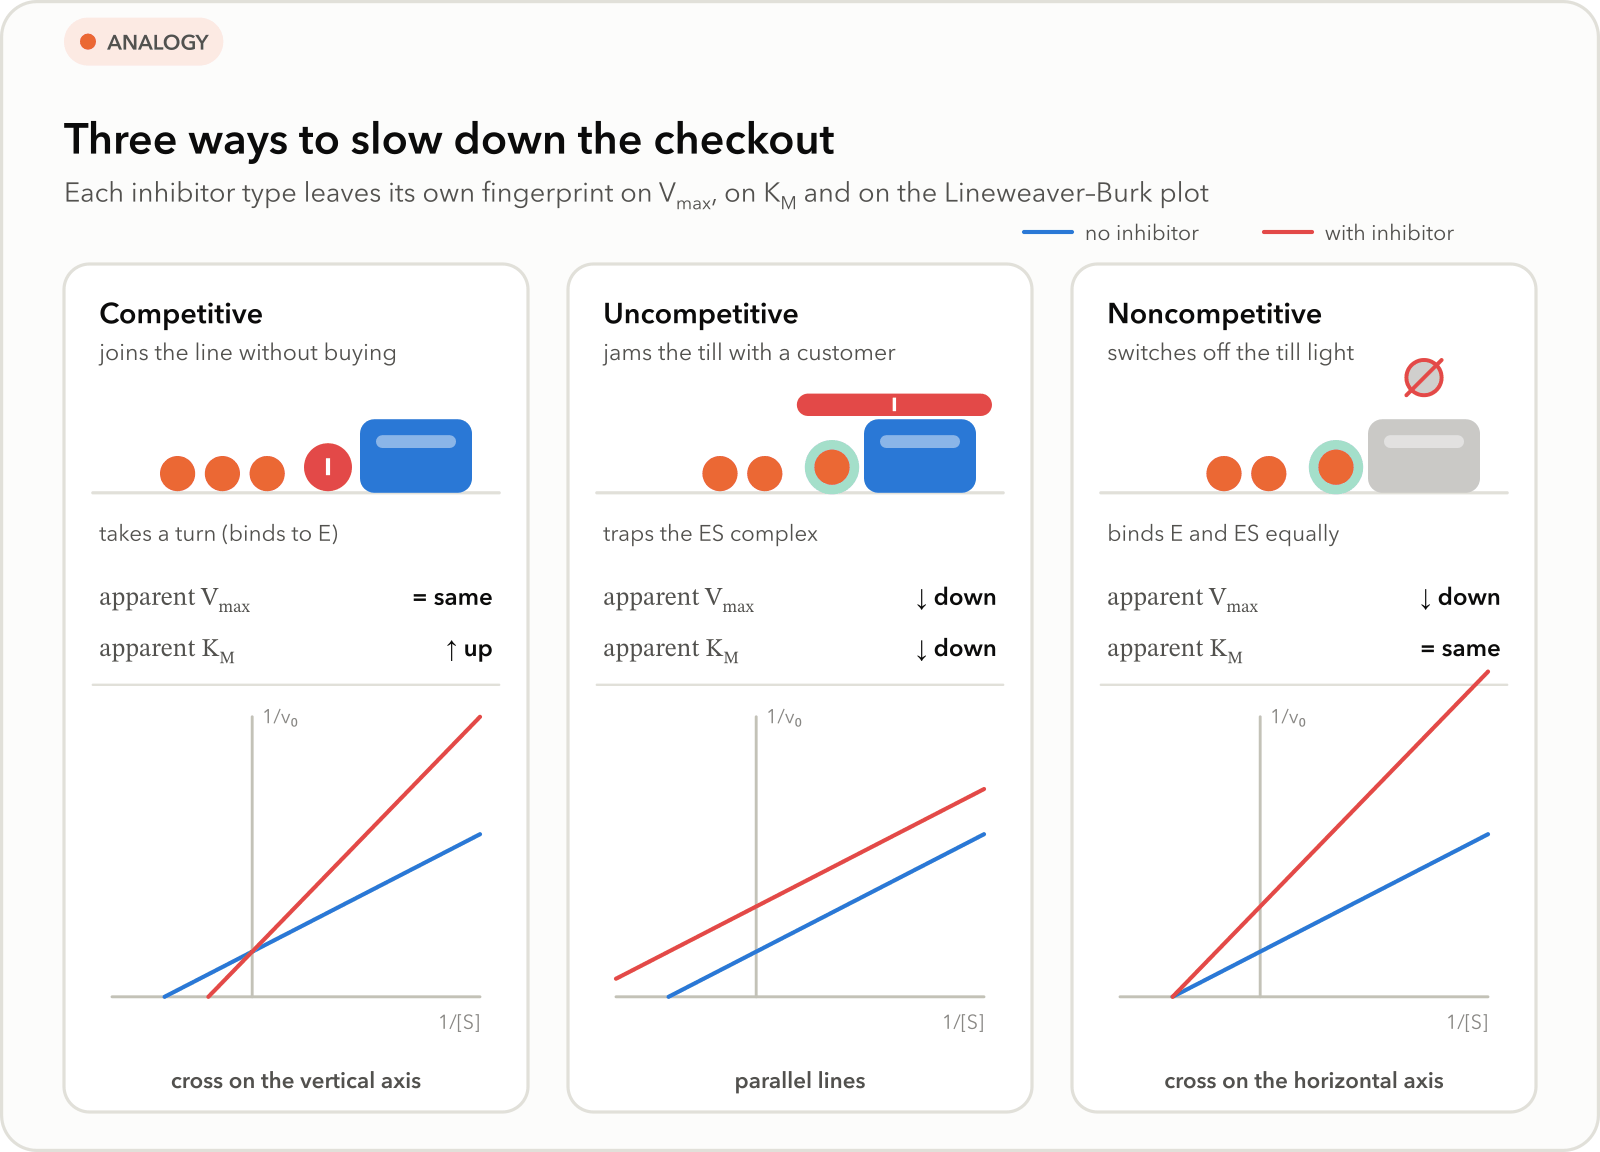

---

### 🧮 The equation in words

**Why do we want an equation?** To know *how much* an inhibitor slows the enzyme at a given
concentration, and to measure its potency with a single number, K<sub>i</sub>, that does not depend
on the experiment.

For the competitive case the idea is: the intruder "steals" part of the lanes, so **more
substrate** is needed to reach the same occupancy. How much more? A factor that grows with the
amount of intruder:

$$K_M^{\text{apparent}} \;=\; K_M \times \underbrace{\left(1 + \frac{\text{inhibitor}}{\text{inhibitor potency}}\right)}_{\text{how many times more substrate you need}}$$

If there is as much inhibitor as its K<sub>i</sub>, you need twice the substrate; if there is 10 times
its K<sub>i</sub>, 11 times more.

---

### 📐 The full equation, term by term

**The derivation for the competitive case (the others are analogous).** The inhibitor I binds to
the free enzyme: $\mathrm{E + I \rightleftharpoons EI}$ with $K_i = [\mathrm{E}][\mathrm{I}]/[\mathrm{EI}]$.
Now the total enzyme is $[\mathrm{E}]_0 = [\mathrm{E}] + [\mathrm{ES}] + [\mathrm{EI}]$ (*each lane is
free, serving a customer, or blocked by the intruder*) and, repeating the algebra of section 13,

$$v_0 = \frac{V_{\max}[\mathrm{S}]}{K_M{\color{#e34948}{\left(1 + \dfrac{[\mathrm{I}]}{K_i}\right)}} + [\mathrm{S}]}
\qquad\Rightarrow\qquad K_M^{\mathrm{app}} = K_M{\color{#e34948}{\left(1+\frac{[\mathrm{I}]}{K_i}\right)}},\; V_{\max}^{\mathrm{app}} = V_{\max}.$$

The **red** factor (the inhibitor's color in the drawing) is the whole effect of the intruder.

| Term | What it is | In the analogy |
|---|---|---|
| [I] | inhibitor concentration | how many intruders are in the store |
| $K_i$ | dissociation constant of the EI complex | the [I] that blocks half of the free lanes: the **smaller**, the more potent |
| 1 + [I]/K<sub>i</sub> (red) | inhibition factor | how many times more customers you need for the same occupancy |

| Type | Binds to | In the analogy | Apparent V<sub>max</sub> | Apparent K<sub>M</sub> | Lineweaver–Burk fingerprint |
|---|---|---|---|---|---|
| competitive | E | takes a turn | unchanged | × (1 + [I]/K<sub>i</sub>) | lines crossing on the y axis |
| uncompetitive | ES | jams the till with a customer | ÷ (1 + [I]/K<sub>i</sub>′) | ÷ (1 + [I]/K<sub>i</sub>′) | parallel lines |
| noncompetitive | E and ES equally | turns off the light | ÷ (1 + [I]/K<sub>i</sub>) | unchanged | lines crossing on the x axis |
| mixed | E and ES, differently | a bit of each | ÷ (1 + [I]/K<sub>i</sub>′) | × (1+[I]/K<sub>i</sub>)/(1+[I]/K<sub>i</sub>′) | cross to the left of the y axis |

---

### 🎛️ What if…

| If… | then… | because… |
|---|---|---|
| **[I] = K<sub>i</sub>** (competitive) | the apparent K<sub>M</sub> **doubles** | 1 + 1 = 2 |
| **[I] = 10 K<sub>i</sub>** (competitive) | the apparent K<sub>M</sub> is multiplied by **11** | 1 + 10 = 11 |
| **you add a lot of substrate** | a competitive inhibitor **is overcome**; a noncompetitive one, **never** | with a long queue the intruder never gets a turn; a light that is off slows the lane all the same |

Choose the type of inhibitor and move [I] and K<sub>i</sub>:

In [ ]:
# @title 🎛️ Inhibitor types and their fingerprint
# 🎛️ Choose the inhibitor type and move [I] and Ki: look at the curve and its Lineweaver–Burk fingerprint
interactivo.explorar_inhibicion()

### 🔬 From data to K<sub>i</sub>: three routes that must agree

1. **Global fit**: all the points (several [S] and several [I]) against the full equation
   → V<sub>max</sub>, K<sub>M</sub> and K<sub>i</sub> with their errors. This is the recommended method today.
2. **Secondary plot**: each [I] is fitted separately and K<sub>M</sub><sup>app</sup> is plotted
   versus [I]: it is a straight line with slope K<sub>M</sub>/K<sub>i</sub>.
3. **Dixon plot**: 1/v₀ versus [I] for several [S]; for a competitive inhibitor the lines cross at
   [I] = −K<sub>i</sub>.

**From IC₅₀ to K<sub>i</sub>.** Pharmacology often measures the **IC₅₀**: the concentration that
cuts the activity in half. In words: *the more substrate competes, the more inhibitor it takes to
cut the rate in half*, so the IC₅₀ depends on [S]. The **Cheng–Prusoff** equation discounts that
effect and returns K<sub>i</sub> (for a competitive inhibitor):

$$K_i = \frac{\mathrm{IC}_{50}}{1 + {\color{#eb6834}{[\mathrm{S}]/K_M}}}$$

The **orange** term (the substrate's color) is the "head start" the substrate has over the
inhibitor.

In [ ]:
# @title 🔬 Three routes to measure K_i
Ki_real = 3.0                                   # mM (hypothetical competitive inhibitor)
S_exp = np.array([1, 2, 4, 8, 16, 32, 64]); I_exp = (0, 2, 5, 10)
filas = []
for I in I_exp:
    v = cin.competitive_inhibition(S_exp, Vmax_real, Km_real, I, Ki_real) * (1 + 0.03 * rng.standard_normal(S_exp.size))
    filas += [(s, vv, I) for s, vv in zip(S_exp, v)]
df_i = pd.DataFrame(filas, columns=["S", "v", "I"])
# 1) global fit
aji = cin.fit_inhibition(df_i.S.values, df_i.v.values, df_i.I.values, kind="competitive")
# 2) secondary plot: apparent Km versus [I]
km_ap = np.array([cin.fit_michaelis_menten(df_i[df_i.I == I].S.values, df_i[df_i.I == I].v.values)["km"] for I in I_exp])
sec = cin.secondary_plot_competitive(np.array(I_exp), km_ap, aji["km"])
# 3) Dixon
dx = cin.dixon_plot(df_i.S.values, df_i.v.values, df_i.I.values)
kd = cin.ki_from_dixon(sorted(dx["lines"]), dx, aji["km"], aji["vmax"])
# 4) IC50 -> Ki (Cheng–Prusoff)
S_ensayo = 8.0
ic50 = Ki_real * (1 + S_ensayo / Km_real)

fig, axes = viz.figure(14, 5.6, ncols=2)
colores = viz.sequential_blue(len(dx["lines"]))
for (s_val, (ii, inv_v)), color in zip(sorted(dx["lines"].items()), colores):
    fit = dx["fits"][s_val]
    xx = np.linspace(-1.3 * Ki_real, max(I_exp), 50)
    axes[0].plot(xx, fit["intercept"] + fit["slope"] * xx, color=color, lw=1.4, ls=(0, (4, 3)), zorder=2)
    xs = np.linspace(0, max(I_exp), 20)
    axes[0].plot(xs, fit["intercept"] + fit["slope"] * xs, color=color, lw=2.6, zorder=3)
    viz._markers(axes[0], ii, inv_v, color, label=f"[S] = {s_val:g} mM", size=8)
f_lo = dx["fits"][sorted(dx["lines"])[0]]
axes[0].axvline(0, color=viz.AXIS, lw=0.9, zorder=1); axes[0].axhline(0, color=viz.AXIS, lw=0.9, zorder=1)
viz._keypoint(axes[0], -kd["ki"], f_lo["intercept"] - f_lo["slope"] * kd["ki"], viz.COLORS["ts"], size=10)
axes[0].annotate(f"they cross at [I] = −Kᵢ\nKᵢ ≈ {kd['ki']:.2f} mM", (-kd["ki"], f_lo["intercept"] - f_lo["slope"] * kd["ki"]),
                 xytext=(4, -24), textcoords="offset points", ha="left", va="top", fontsize=11, color=viz.INK, fontweight="semibold")
viz._finish(axes[0], "[I] (mM)", "1/v₀ (s/µM)")
axes[0].set_ylim(bottom=-0.18 * axes[0].get_ylim()[1])
viz._legend(axes[0], loc="upper left", fontsize=10)
axes[0].set_title("Dixon plot", loc="left", fontsize=13, fontweight="semibold", pad=10)
xx = np.linspace(0, max(I_exp), 20)
axes[1].fill_between(xx, aji["km"], aji["km"] * (1 + xx / aji["ki"]), color=viz._tint(viz.PALETTE[7], 0.9), lw=0, zorder=1)
axes[1].plot(xx, aji["km"] * (1 + xx / aji["ki"]), color=viz.INK_SECONDARY, lw=2.4, zorder=2)
viz._markers(axes[1], I_exp, km_ap, viz.COLORS["datos"], size=9)
viz._guide(axes[1], "h", aji["km"])
axes[1].annotate("K_M without inhibitor", (max(I_exp), aji["km"]), xytext=(-4, -6), textcoords="offset points", ha="right", va="top",
                 fontsize=10.5, color=viz.INK_SECONDARY)
axes[1].annotate(f"slope = K_M/Kᵢ\n→ Kᵢ = {sec['ki']:.2f} mM", (0.55 * max(I_exp), aji["km"] * (1 + 0.55 * max(I_exp) / aji["ki"])),
                 xytext=(-14, 10), textcoords="offset points", ha="right", va="bottom", fontsize=11, color=viz.INK, fontweight="semibold")
axes[1].set_ylim(0, None)
viz._finish(axes[1], "[I] (mM)", "apparent K_M (mM)")
axes[1].set_title("Secondary plot", loc="left", fontsize=13, fontweight="semibold", pad=10)
viz._fig_title(fig, f"Three routes, the same Kᵢ ≈ {aji['ki']:.1f} mM (value used in the simulation: {Ki_real:g} mM)",
               "Left: 1/v₀ versus [I] for several [S]. Right: apparent K_M versus [I]. Both from the same data.")
tabla_dixon = df_i.rename(columns={"S": "[S]", "I": "[I]", "v": "v₀"})[["[I]", "[S]", "v₀"]].copy()
tabla_dixon["1/v₀"] = 1 / tabla_dixon["v₀"]
tabla_dixon["v₀ without inhibitor (same [S])"] = [df_i[(df_i.I == 0) & (df_i.S == sv)].v.iloc[0] for sv in tabla_dixon["[S]"]]
tabla_dixon["remaining activity"] = tabla_dixon["v₀"] / tabla_dixon["v₀ without inhibitor (same [S])"]
datos_dixon = viz.datos(
    tabla_dixon, "the Dixon plot",
    "The 28 tubes of the experiment: 4 inhibitor concentrations × 7 glucose concentrations (3 % noise). In the "
    "Dixon plot each [S] is a line: its points are the rows with that [S], with [I] on the x axis and 1/v₀ on the y axis. "
    "With plenty of glucose the competitive inhibitor is barely noticeable (remaining activity close to 100 %).",
    x="[I]", y="1/v₀",
    calculadas={"1/v₀": "1 ÷ v₀", "remaining activity": "v₀ ÷ v₀ without inhibitor, at the same [S]"},
    unidades={"[I]": "mM", "[S]": "mM", "v₀": "µM/s", "1/v₀": "s/µM", "v₀ without inhibitor (same [S])": "µM/s"},
    formatos={"[I]": "{:g}", "[S]": "{:g}", "v₀": "{:.2f}", "1/v₀": "{:.3f}", "v₀ without inhibitor (same [S])": "{:.2f}",
              "remaining activity": "{:.0%}"},
    resaltar={i: ("[I] = 10 mM", "rojo") for i in tabla_dixon.index[(tabla_dixon["[I]"] == max(I_exp)) & (tabla_dixon["[S]"] <= 2)]},
    barra="1/v₀", max_filas=40, abierta=False)
tabla_sec = pd.DataFrame({"[I]": np.array(I_exp, dtype=float), "apparent K_M": km_ap, "K_M app / K_M": km_ap / aji["km"],
                          "1 + [I]/Kᵢ (theory)": 1 + np.array(I_exp) / aji["ki"]})
datos_sec = viz.datos(
    tabla_sec, "the secondary plot",
    "One row per inhibitor concentration: each group of 7 tubes gets its own hyperbola fit, and its apparent K_M "
    "is one point of the secondary plot. If the inhibitor is competitive, K_M app/K_M grows as 1 + [I]/Kᵢ.",
    x="[I]", y="apparent K_M",
    calculadas={"apparent K_M": "Michaelis–Menten fit to the tubes with that [I] only",
                "K_M app / K_M": "apparent K_M ÷ K_M without inhibitor (from the global fit)",
                "1 + [I]/Kᵢ (theory)": "what the competitive equation predicts with Kᵢ from the global fit"},
    unidades={"[I]": "mM", "apparent K_M": "mM"},
    formatos={"[I]": "{:g}", "apparent K_M": "{:.2f}", "K_M app / K_M": "{:.2f}", "1 + [I]/Kᵢ (theory)": "{:.2f}"},
    barra="apparent K_M")
viz.mostrar(fig, datos_dixon, datos_sec, viz.tarjetas([
    ("1 · global fit", f"{aji['ki']:.2f}", f"± {aji['ki_err']:.2f} mM", f"K_M = {aji['km']:.2f} mM, V_max = {aji['vmax']:.2f} µM/s", "azul"),
    ("2 · secondary plot", f"{sec['ki']:.2f}", "mM", f"R² = {sec['r2']:.3f}", "agua"),
    ("3 · Dixon", f"{kd['ki']:.2f}", "mM", "from where the lines cross", "naranja"),
    ("4 · Cheng–Prusoff", f"{cin.cheng_prusoff(ic50, S_ensayo, Km_real):.2f}", "mM", f"from IC₅₀ = {ic50:.1f} mM at [S] = {S_ensayo:g} mM", "violeta"),
], titulo="Kᵢ of the same inhibitor, measured four ways",
   nota="If the methods agree, the (competitive) model describes the data well."))

### 🔬 The real inhibitors and regulators of glucokinase

Table with sources. Three surprising things:

* Glucose‑6‑phosphate, which slows down hexokinases I–III, does **not** inhibit glucokinase: that
  is why the liver keeps phosphorylating glucose even as the product accumulates (Viñuela, Salas
  and Sols, 1963).
* **Mannoheptulose**, which many textbooks call "competitive", turns out to be **mixed** when
  measured carefully (Scruel 1998), and its K<sub>i</sub> varies 100-fold between secondary
  sources: that is why we do not give a number.
* In the liver, the **regulatory protein GKRP** acts as a competitive inhibitor with respect to
  glucose (it raises S<sub>0.5</sub> without changing V; IC₅₀ ≈ 13 mM glucose) and sequesters the
  enzyme in the nucleus when glucose falls; fructose‑6‑phosphate reinforces that sequestration and
  fructose‑1‑phosphate undoes it.

In [ ]:
# @title 📋 Real inhibitors and activators of glucokinase
inh = ref.get("inhibitors", [])
tipos = {"competitive": "competitive", "mixed": "mixed", "none": "none", "slow-binding": "slow binding",
         "uncompetitive": "uncompetitive", "noncompetitive": "noncompetitive"}
act = ref.get("activators", [])
viz.mostrar(
    viz.tabla(pd.DataFrame([(d.get("name"), tipos.get(d.get("kind"), d.get("kind")), d.get("versus", ""), d.get("ki", ""), d.get("note", ""), d.get("source", "")) for d in inh],
                           columns=["inhibitor / regulator", "type", "versus", "Kᵢ / effect", "note", "source"]),
              titulo="Inhibitors and regulators of glucokinase"),
    viz.tabla(pd.DataFrame([(d.get("name"), d.get("fold", ""), d.get("ec50", ""), d.get("note", ""), d.get("source", "")) for d in act],
                           columns=["activator", "activation (fold)", "EC₅₀", "note", "source"]),
              titulo="Allosteric activators (GKA)"),
)

### 🔬 Allosteric activators (GKA)

In the analogy: someone **oils the till** and opens the lane sooner. They bind to a site ~20 Å from
the glucose site (Kamata 2004), lower S<sub>0.5</sub> and raise V<sub>max</sub>: the opposite of an
inhibitor. The reference compound RO‑28‑1675 activates the wild-type enzyme ~16-fold with
EC₅₀ ≈ 7 µM (Sayed 2009) and was tested as a drug for type 2 diabetes (Grimsby 2003). What happens
to the activity at 5 mM glucose when you lower S<sub>0.5</sub>? Try it:

In [ ]:
# @title 🎛️ An allosteric activator
# 🎛️ An allosteric activator: lowers S0.5 and raises Vmax. What happens to the activity at 5 mM glucose?
interactivo.explorar_activador()

> ✅ **Takeaway.** Each type of inhibitor leaves a different fingerprint: the competitive one raises
> K<sub>M</sub> (and is overcome by substrate), the uncompetitive one lowers V<sub>max</sub> and
> K<sub>M</sub>, the noncompetitive one lowers only V<sub>max</sub>. K<sub>i</sub> is measured by a
> global fit, a secondary plot or a Dixon plot, and Cheng–Prusoff turns an IC₅₀ into a
> K<sub>i</sub>. Activators do the opposite: they lower S<sub>0.5</sub>.

## 16. Temperature and pH

> 🎯 **In this section** you will see why heating speeds up reactions (and by how much), how to
> split the barrier into **enthalpy** and **entropy** with the Arrhenius and Eyring equations, and
> why an enzyme's activity versus pH is **bell-shaped**.

---

### 💡 The analogy: heating = stronger thermal kicks

Go back to the ball of section 6. Temperature is the strength of the thermal kicks: when you heat,
all the molecules move more and the **fraction** that has enough energy to cross the hill **grows**.
Because that fraction is the "tail" of a distribution, a small change in temperature enlarges it
far more than you might expect.

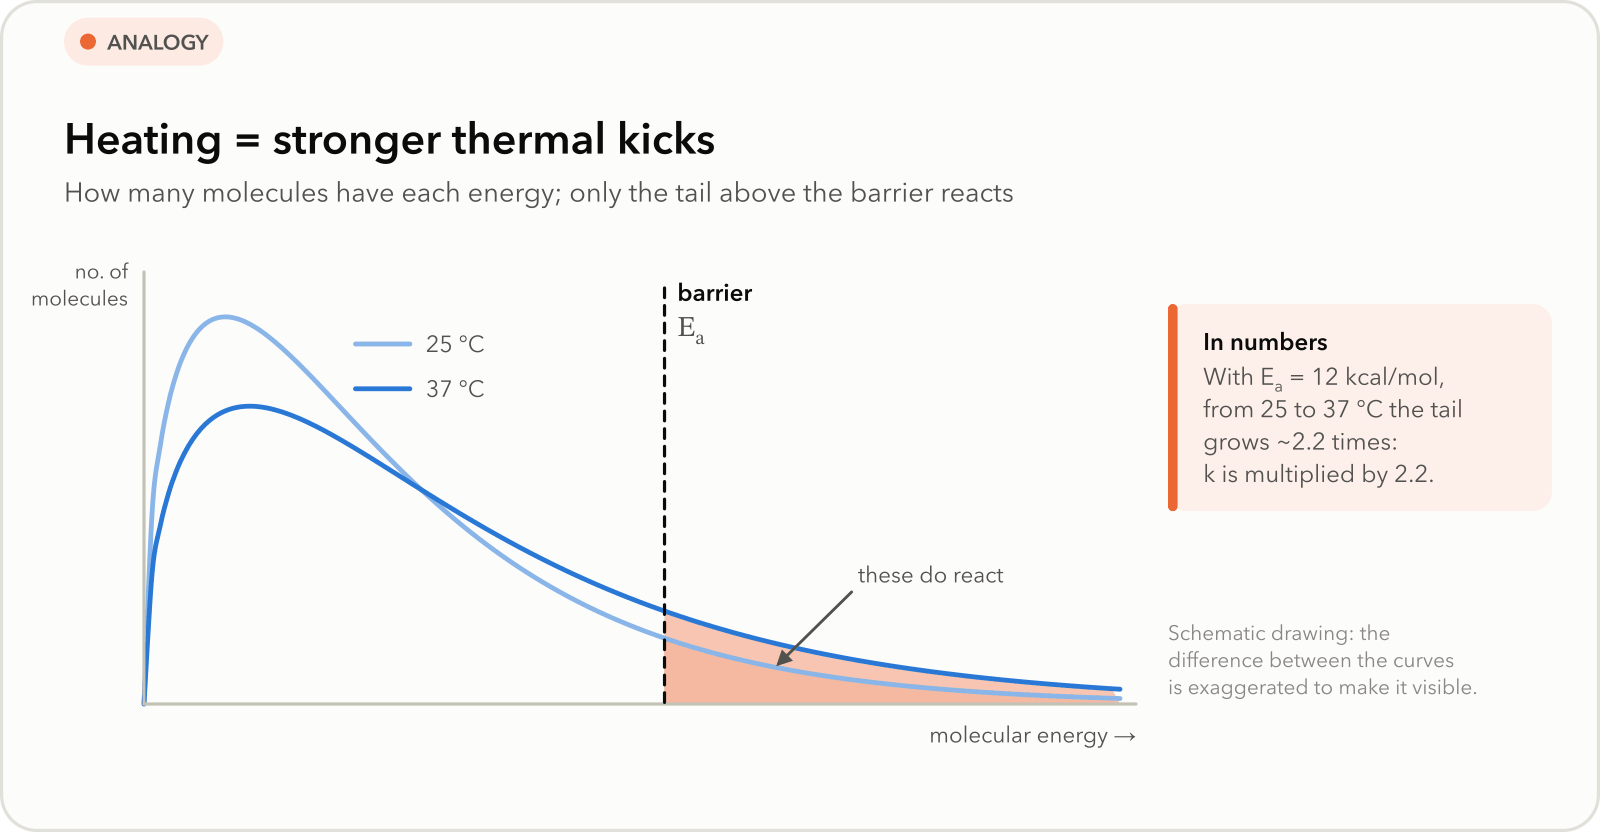

(Until the enzyme denatures: too much heat unravels the protein.)

---

### 🧮 The equation in words

**Why do we want an equation?** To read the **height of the barrier** from a simple experiment:
measure k at several temperatures. How much the rate rises on heating tells you how tall the hill
is.

$$\text{ln(rate)} \;=\; \text{constant} \;-\; \frac{\text{height of the barrier}}{\text{energy of the thermal kicks}}$$

If you plot ln k versus 1/T you get a **straight line**, and its slope is the barrier: the steeper
it is, the taller the hill and the more sensitive the reaction is to temperature.

---

### 📐 The full equations, term by term

**Arrhenius**: $\ln k = \ln A - {\color{#eb6834}{E_a}}/RT$. In a plot of ln k versus 1/T the slope
is $-{\color{#eb6834}{E_a}}/R$: the **activation energy** is "how much the rate rises on heating".

**Eyring**: $\ln(k/T) = \ln(k_B/h) + {\color{#4a3aa7}{\Delta S^{\ddagger}}}/R - {\color{#eb6834}{\Delta H^{\ddagger}}}/RT$.
It splits the barrier into **enthalpy** (energy that has to be supplied) and **entropy** (order that
has to be imposed: a negative ΔS‡ means the transition state is more ordered than the reactants).

| Term | What it is | In the analogy |
|---|---|---|
| ${\color{#eb6834}{E_a,\ \Delta H^{\ddagger}}}$ | activation energy / activation enthalpy | the height of the hill |
| ${\color{#4a3aa7}{\Delta S^{\ddagger}}}$ | activation entropy | how narrow the pass is: if the summit must be "threaded" precisely, ΔS‡ < 0 |
| $A$ | pre-exponential factor | the attempts per second |
| $RT$ | thermal energy | the typical strength of the thermal kicks |

---

### 🎛️ What if…

| If… | going from 25 to 37 °C multiplies k by… | because… |
|---|---|---|
| E<sub>a</sub> = 12 kcal/mol | **~2.2** | the tail above a tall hill grows a lot with the kicks |
| E<sub>a</sub> = 6 kcal/mol | **~1.5** | over a low hill many already get across: heating adds less |

The higher the barrier, the more sensitive to temperature.

In [ ]:
# @title 🎛️ Enthalpy, entropy and temperature
# 🎛️ Activation enthalpy and entropy: look at the Eyring plot and k(T)
interactivo.explorar_temperatura()

In [ ]:
# @title 🌡️ Arrhenius and Eyring with data
T_K = np.array([283.15, 288.15, 293.15, 298.15, 303.15, 308.15, 313.15])
dH, dS = 12.0, -8.0                       # kcal/mol, cal/mol/K (illustrative)
k_T = np.array([cin.eyring_rate(dH - T * dS / 1000, T) for T in T_K]) * (1 + 0.03 * rng.standard_normal(T_K.size))
aj_arr, aj_eyr = cin.fit_arrhenius(T_K, k_T), cin.fit_eyring(T_K, k_T)
fig, axes = viz.figure(14, 5.8, ncols=2)
viz.plot_arrhenius(T_K, k_T, fit=aj_arr, ax=axes[0], title="Arrhenius: ln k versus 1000/T")
viz.plot_eyring(T_K, k_T, fit=aj_eyr, ax=axes[1], title="Eyring: ln(k/T) versus 1000/T")
viz._fig_title(fig, "More heat, more speed: the slope measures how much",
               "Seven temperatures from 10 to 40 °C (top axis). A steep line = a reaction very sensitive to temperature.")
tabla_T = pd.DataFrame({"T": T_K, "T (°C)": T_K - 273.15, "measured k": k_T, "1000/T": 1000 / T_K,
                        "ln k": np.log(k_T), "ln(k/T)": np.log(k_T / T_K)})
datos_T = viz.datos(
    tabla_T, "Arrhenius and Eyring",
    "Seven measurements of the rate constant, one per temperature (3 % noise). Both lines use the same "
    "x axis, 1000/T; Arrhenius puts ln k on the y axis and Eyring, ln(k/T). Their slopes give E_a and ΔH‡.",
    x="1000/T", y=["ln k", "ln(k/T)"],
    calculadas={"T (°C)": "T − 273.15", "1000/T": "1000 ÷ T (in K⁻¹ × 1000, so the numbers are convenient)",
                "ln k": "natural logarithm of k  (y axis of Arrhenius; slope = −E_a/R)",
                "ln(k/T)": "natural logarithm of k ÷ T  (y axis of Eyring; slope = −ΔH‡/R)"},
    unidades={"T": "K", "T (°C)": "°C", "measured k": "s⁻¹", "1000/T": "K⁻¹"},
    formatos={"T": "{:.2f}", "T (°C)": "{:.0f}", "measured k": "{:.1f}", "1000/T": "{:.4f}", "ln k": "{:.3f}", "ln(k/T)": "{:.3f}"},
    resaltar={int(np.argmin(np.abs(T_K - 298.15))): ("25 °C", "azul")},
    barra="measured k")
viz.mostrar(fig, datos_T, viz.tarjetas([
    ("E_a (Arrhenius)", f"{aj_arr['ea_kcal']:.1f}", "kcal/mol", "how much k rises on heating", "naranja"),
    ("ΔH‡ (Eyring)", f"{aj_eyr['delta_h_kcal']:.1f}", "kcal/mol", "energy that has to be supplied", "naranja"),
    ("ΔS‡ (Eyring)", f"{aj_eyr['delta_s_cal']:.1f}", "cal/mol/K", "negative: the TS is more ordered", "violeta"),
    ("ΔG‡ (25 °C)", f"{aj_eyr['delta_g_kcal']:.1f}", "kcal/mol", "ΔH‡ − TΔS‡", "azul"),
], titulo="What the two lines say", nota="How they are related: E_a ≈ ΔH‡ + RT (0.6 kcal/mol at 25 °C)."))

---

### 💡 The pH analogy: two groups, two conditions

Every enzyme has an optimal pH: above or below it, the groups that do the chemistry lose the
charge they need. In glucokinase, **Asp205** (the catalytic base) must be **deprotonated** to accept
the proton from glucose, and **Lys169** must be **protonated** to stabilize the phosphate. It is like
a door with two locks: it only opens when both are in the right position.

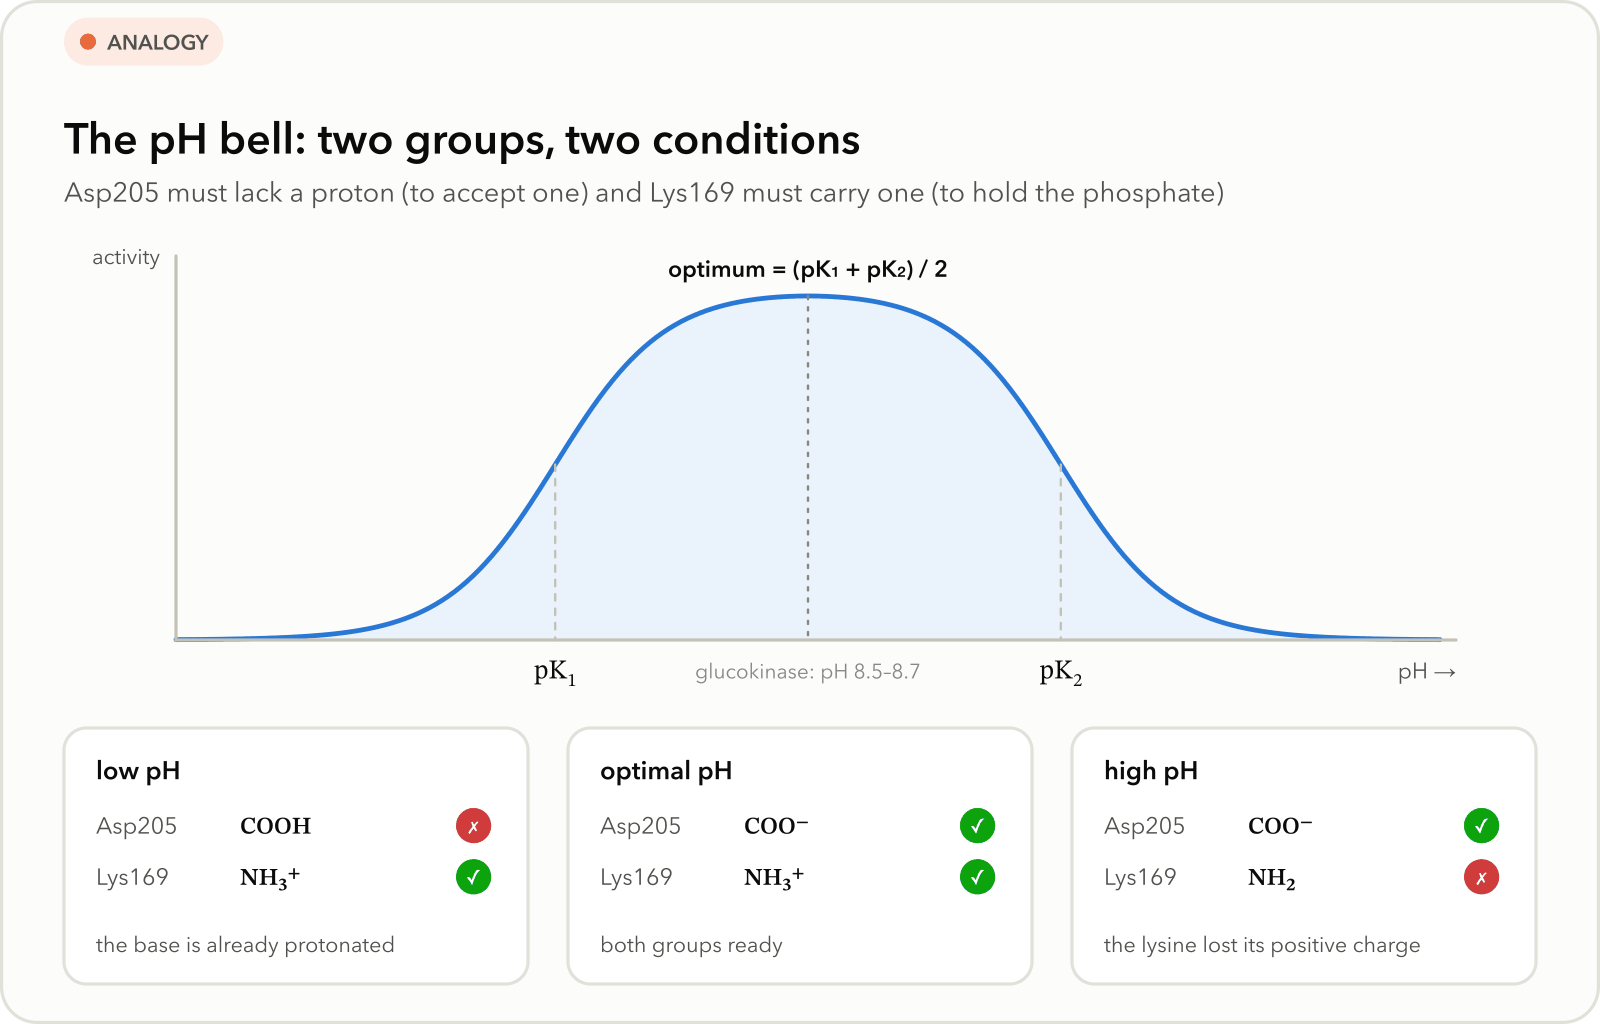

### 🧮 The equation in words

$$\text{activity} \;=\; \frac{\text{maximum activity}}{1 + (\text{penalty if the base is missing}) + (\text{penalty if the acid is missing})}$$

Each penalty is almost zero at the right pH and grows tenfold for each pH unit you move away: hence
the bell.

### 📐 The full equation, term by term

$$v = \frac{v_{\max}}{1 + {\color{#eb6834}{10^{\,pK_1 - \mathrm{pH}}}} + {\color{#4a3aa7}{10^{\,\mathrm{pH} - pK_2}}}}$$

| Term | What it is | When it matters |
|---|---|---|
| ${\color{#eb6834}{10^{\,pK_1 - \mathrm{pH}}}}$ | ratio of **protonated** Asp205 (useless as a base) / deprotonated | at low pH: it "switches off" the enzyme |
| ${\color{#4a3aa7}{10^{\,\mathrm{pH} - pK_2}}}$ | ratio of **deprotonated** Lys169 (no positive charge) / protonated | at high pH: it "switches off" the enzyme |
| (pK<sub>1</sub> + pK<sub>2</sub>)/2 | position of the maximum | the optimal pH |

> 🔬 **The real data.** For human glucokinase the measured optimum is pH 8.5–8.7 (Šimčíková and
> Heneberg 2019); for decades it was thought to be lower because ATP acidifies the assay buffers:
> an example of how a technical detail can change a textbook "fact".

In [ ]:
# @title 🎛️ The pH bell curve
# 🎛️ pKa of the base and the acid: the pH bell curve
interactivo.explorar_ph()

> ✅ **Takeaway.** Heating enlarges the tail of molecules that clear the barrier: the taller the
> hill, the more the reaction gains with temperature (Arrhenius measures E<sub>a</sub>; Eyring splits
> it into ΔH‡ and ΔS‡). The pH decides whether the catalytic groups carry the right charge: two
> pK<sub>a</sub> values draw a bell with the maximum between them.

## 17. Summary, glossary and exercises

> 🎯 **In this section** we put all the pieces together: the course map, the equations on a single
> page, a glossary and exercises to check what you have learned.

---

### 🗺️ The course map

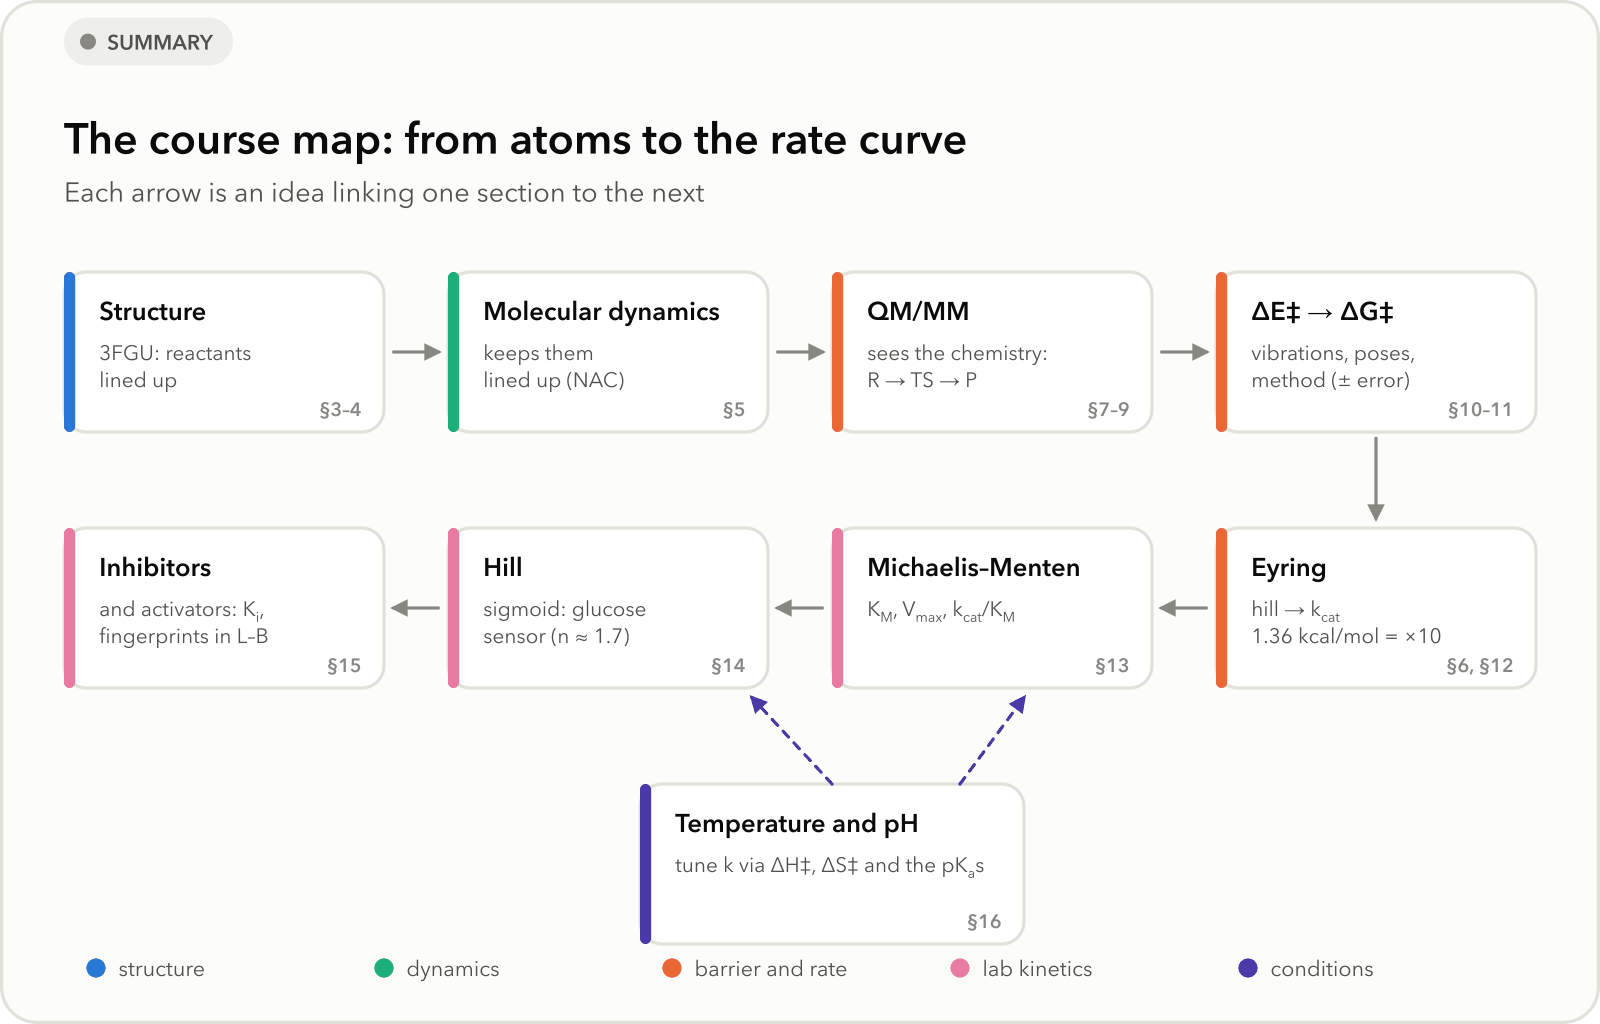

**What we have seen, one sentence each:**

1. An enzyme speeds up a reaction by **lowering the barrier** of the transition state, like a
   guide who knows the lowest mountain pass.
2. The crystal structure (3FGU) shows the reactants already aligned; MD shows that the enzyme
   **keeps them aligned**.
3. QM/MM lets us **see the chemistry** inside the enzyme; care is needed with the partition, the
   link atoms, the electrostatics and the QM–MM repulsion.
4. The transition state is a **saddle point**: it is located (scan → NEB → dimer) and **validated**
   with a single imaginary frequency and with the path that goes down to R and P.
5. From ΔE‡ to ΔG‡: vibrations, averaging over conformations and sensitivity to the method. A
   computational result carries **uncertainty**, and our barrier agrees with another published
   calculation and overestimates experiment by ~3–4 kcal/mol.
6. Eyring turns the barrier into *k*<sub>cat</sub>; 1.4 kcal/mol is a factor of 10.
7. Michaelis–Menten **emerges** from the mechanism E + S ⇌ ES → E + P; K<sub>M</sub>, V<sub>max</sub>,
   k<sub>cat</sub> and k<sub>cat</sub>/K<sub>M</sub> are obtained from data by a nonlinear fit.
8. Glucokinase is **sigmoidal** (n ≈ 1.7) without having several subunits: kinetic
   cooperativity; its mutants shift the insulin switch.
9. Each type of inhibitor leaves a different fingerprint; K<sub>i</sub> is obtained by a global fit,
   a secondary plot or a Dixon plot; activators do the opposite.
10. Temperature and pH modulate k through ΔH‡, ΔS‡ and the pK<sub>a</sub> values of the active site.

---

### 🧮 The course equations, on one page

**Initial rate** (section 2): the rate is the initial slope of the product curve.

$$v_0 = \left(\frac{\Delta[\mathrm{P}]}{\Delta t}\right)_{t\to 0}$$

**Eyring** (sections 6 and 12): rate = attempts per second × probability of reaching the summit.

$$k = \kappa\,\frac{k_B T}{h}\,\exp\!\left(-\frac{\Delta G^{\ddagger}}{RT}\right)$$

**Michaelis–Menten** (section 13): the checkout lane saturates; with plenty of substrate the enzyme works flat out.

$$v_0 = \frac{V_{\max}[\mathrm{S}]}{K_M + [\mathrm{S}]}$$

**Hill** (section 14): a switch; little activity up to a threshold, then a lot.

$$v_0 = \frac{V_{\max}[\mathrm{S}]^{n}}{S_{0.5}^{\,n} + [\mathrm{S}]^{n}}$$

**Competitive inhibition** (section 15): the intruder demands more substrate for the same rate.

$$K_M^{\mathrm{app}} = K_M\left(1 + \frac{[\mathrm{I}]}{K_i}\right)$$

**Arrhenius** (section 16): heating speeds things up more the higher the barrier.

$$\ln k = \ln A - \frac{E_a}{RT}$$

**pH** (section 16): the enzyme only works if each group of the active site carries the right charge.

$$v = \frac{v_{\max}}{1 + 10^{pK_1 - \mathrm{pH}} + 10^{\mathrm{pH} - pK_2}}$$

---

### 📖 Quick glossary

| Term | Meaning |
|---|---|
| *Substrate* | the molecule that is transformed |
| *Active site* | where the chemistry happens |
| *ES* | enzyme–substrate complex |
| *Transition state* | the summit of the barrier |
| *ΔG‡* | height of the barrier |
| *k*<sub>cat</sub> | reactions per second per enzyme |
| *K*<sub>M</sub> | [S] at half rate |
| *k*<sub>cat</sub>/*K*<sub>M</sub> | efficiency at low [S] |
| *S*<sub>0.5</sub>, *n* | Hill parameters |
| *K*<sub>i</sub> | dissociation constant of the inhibitor |
| *QM/MM* | quantum mechanics for the reactive region and a force field for the rest |
| *NEB, dimer* | methods to find the TS |
| *Imaginary frequency* | the signature of a saddle point |

---

### ✍️ Exercises

**Getting started**

1. Move the `umbral` (threshold) slider in section 5 to 3.0 and to 4.0 Å and run the cell again. How does the fraction of
   near-attack conformations change? What would happen to *k*<sub>cat</sub> if the enzyme did not close its domains?
2. With the Eyring explorer, find out how much the barrier would have to drop to multiply
   *k*<sub>cat</sub> by 1000. Compare it with the difference between the active site in water and in the enzyme.
3. In section 13, move the `k2` slider to 6 s⁻¹ and to 600 s⁻¹ and run the cell again. How do K<sub>M</sub> and V<sub>max</sub> change?
   When is K<sub>M</sub> ≈ K<sub>d</sub> = k<sub>−1</sub>/k<sub>1</sub>?

**Going deeper**

4. Simulate data with n = 1.0, 1.4 and 2.0 in section 14 and fit them with Michaelis–Menten.
   What error do you make if you ignore cooperativity? Which mutant in the table would stop
   releasing insulin at 5 mM?
5. Design an experiment (concentrations of S and I) that tells a competitive inhibitor apart from a
   mixed one with K<sub>i</sub>′ = 3K<sub>i</sub>. To check it, add a new cell ("+ Code" button) and use `cin.fit_inhibition` and the Dixon plot.
6. With the thermochemistry of section 10, how much does ΔG‡ change between 25 and 37 °C? What
   factor in *k* does that mean? Compare it with what the temperature explorer predicts.

**Challenge (advanced, `completo` mode)**

7. In `enzimas/glucoquinasa.py` remove Lys169 from `QM_RESIDUES` (it will become MM charges) and
   recompute the scan. Does the barrier go up or down? It is a "computational mutant"; Zhang et al.
   (2009) obtained 32 kcal/mol for K169A versus 18 for the wild type.

---

### 📚 References

In [ ]:
# @title 📚 References
from IPython.display import HTML
import html as _html
refs = ref.get("references", [])
items = "".join(f'<li style="margin:0 0 8px 0;padding-left:4px">{_html.escape(r)}</li>' for r in refs)
viz.mostrar(HTML(
    f'<div style="font-family:Figtree,\'Avenir Next\',\'Segoe UI\',Roboto,Arial,sans-serif;background:{viz.SURFACE};'
    f'border:1px solid {viz.GRID};border-radius:18px;padding:18px 22px;max-width:960px;color:{viz.INK_SECONDARY};font-size:14px;line-height:1.45">'
    f'<div style="font-size:16px;font-weight:650;color:{viz.INK};margin-bottom:10px">📚 Sources of the course data</div>'
    f'<ol style="margin:0;padding-left:22px">{items}</ol>'
    f'<div style="margin-top:12px;font-size:13px;color:{viz.INK_MUTED}">QM/MM tools adapted from the Leonardo suite (Juvenal Yosa, MIT): '
    f'<a href="https://github.com/juvenalyosa/Leonardo" style="color:{viz.PALETTE[0]}">github.com/juvenalyosa/Leonardo</a></div></div>'))